## Rule 3: Hiding Path Information

Based on the patterns in the BIRD dev set, we will identify tables that serve as bridges and exclude their information from the corresponding questions in the BIRD dev set

### Important Note

**_To generate the queries, you must include one development database ID in the first cell at a time. Run all the cells except for the last one each time._**

## 1. Retrieving the dev patterns for each database
The following cells retrieve the join patterns extracted from the development set queries of the BIRD benchmark. For this rule, we have divided these patterns into two sets: a training set and a test set. For now, we are working with the training patterns, which are stored in the `rule_original_patterns/train` folder. The folder can be accessed here: [Train Patterns](https://drive.google.com/drive/folders/1i87JHEK3j348RciQNZem9OpGk2BmPuAj).

The folder contains data for each development database, including a pickle file that contains 80% of the patterns for each database (the patterns are shuffled).

In [1]:
import os
import pickle
from pathlib import Path

def retrieve_all_dev_patterns(folder_path):
    """
    Retrieve all subgraphs from the pickle files in the folder.
    
    Args:
        folder_path (str): The path to the folder containing the .pkl files.
        
    Returns:
        list: A list of all subgraphs from the folder.
    """
    folder = Path(folder_path)

    for file_name in folder.glob('query_graphs.pkl'):
        try:
            with file_name.open('rb') as f:
                subgraphs = pickle.load(f)
        except (ValueError, KeyError, pickle.UnpicklingError) as e:
            print(f"Skipping file {file_name.name}: {e}")

    return subgraphs

# Example usage:
db_ids = [
        "california_schools",
        "card_games",
        "codebase_community",
        "debit_card_specializing",
        "european_football_2",
        "financial",
        "formula_1",
        "student_club",
        "superhero",
        "thrombosis_prediction",
        "toxicology",
]
database_subgraphs = {}
for db_id in db_ids:
    folder_path = f'../../../../data/rule_inputs/rule_3/test/{db_id}/'
    # Retrieve all subgraphs from the folder
    database_subgraphs[db_id] = retrieve_all_dev_patterns(folder_path)
    print(f"Found {len(database_subgraphs[db_id])} subgraphs for {db_id}.")

print(database_subgraphs.keys())


Found 2 subgraphs for california_schools.
Found 4 subgraphs for card_games.
Found 7 subgraphs for codebase_community.
Found 3 subgraphs for debit_card_specializing.
Found 5 subgraphs for european_football_2.
Found 7 subgraphs for financial.
Found 7 subgraphs for formula_1.
Found 6 subgraphs for student_club.
Found 8 subgraphs for superhero.
Found 2 subgraphs for thrombosis_prediction.
Found 3 subgraphs for toxicology.
dict_keys(['california_schools', 'card_games', 'codebase_community', 'debit_card_specializing', 'european_football_2', 'financial', 'formula_1', 'student_club', 'superhero', 'thrombosis_prediction', 'toxicology'])


In this cell, the schema graph for each database is retrieved from the corresponding pickle file stored in the `main_graphs_pickles` folder under `dev_dbs_unnested`. The folder can be accessed here: [Schema Graphs](https://drive.google.com/drive/folders/18a1XT3zZFJO-k28OQT7Cqcm9VlZ7qljS).


In [2]:
import os
import networkx as nx
import matplotlib.pyplot as plt
import pickle
from datetime import datetime



def display_subgraph(schema, subgraph, subgraph_number):
    """
    Display and save a subgraph within the main schema.

    Args:
        schema (nx.Graph): The main graph schema.
        subgraph (nx.Graph): The subgraph to display.
        subgraph_number (int): The number of the subgraph for labeling.
        rule (str): The rule this subgraph belongs to (either 'rule_1' or 'rule_2').
        time_period (str): Either 'pre_rule' or 'post_rule' indicating the time period.
        db_id (str): The database ID.
    """
    # Create a figure for the plot
    plt.figure(figsize=(10, 10))
    
    # Draw the entire schema in light gray
    pos = nx.spring_layout(schema)  # Node positions using spring layout
    nx.draw(schema, pos, with_labels=True, node_color='lightgray', edge_color='black', 
            node_size=1000, font_size=10)

    # Check if the subgraph is None or has nodes
    if subgraph is not None and subgraph.number_of_nodes() > 0:  # Draw the subgraph only if it contains nodes
        # Draw the subgraph nodes and edges
        nx.draw_networkx_nodes(subgraph, pos, node_color='lightblue', node_size=1000)
        nx.draw_networkx_edges(subgraph, pos, edge_color='blue', width=2)

        # Create edge labels for the subgraph, fallback to schema if needed
        edge_labels = {
            (u, v): edge_data.get('label', schema[u][v].get('label', 'No Label'))
            for u, v, edge_data in subgraph.edges(data=True)
        }

        # Draw the edge labels
        nx.draw_networkx_edge_labels(subgraph, pos, edge_labels=edge_labels, font_color='red', font_size=7)

    # Add title indicating the subgraph number
    plt.title(f'Subgraph {subgraph_number}')
    plt.show()
    plt.close()  


Displaying subgraphs for california_schools...


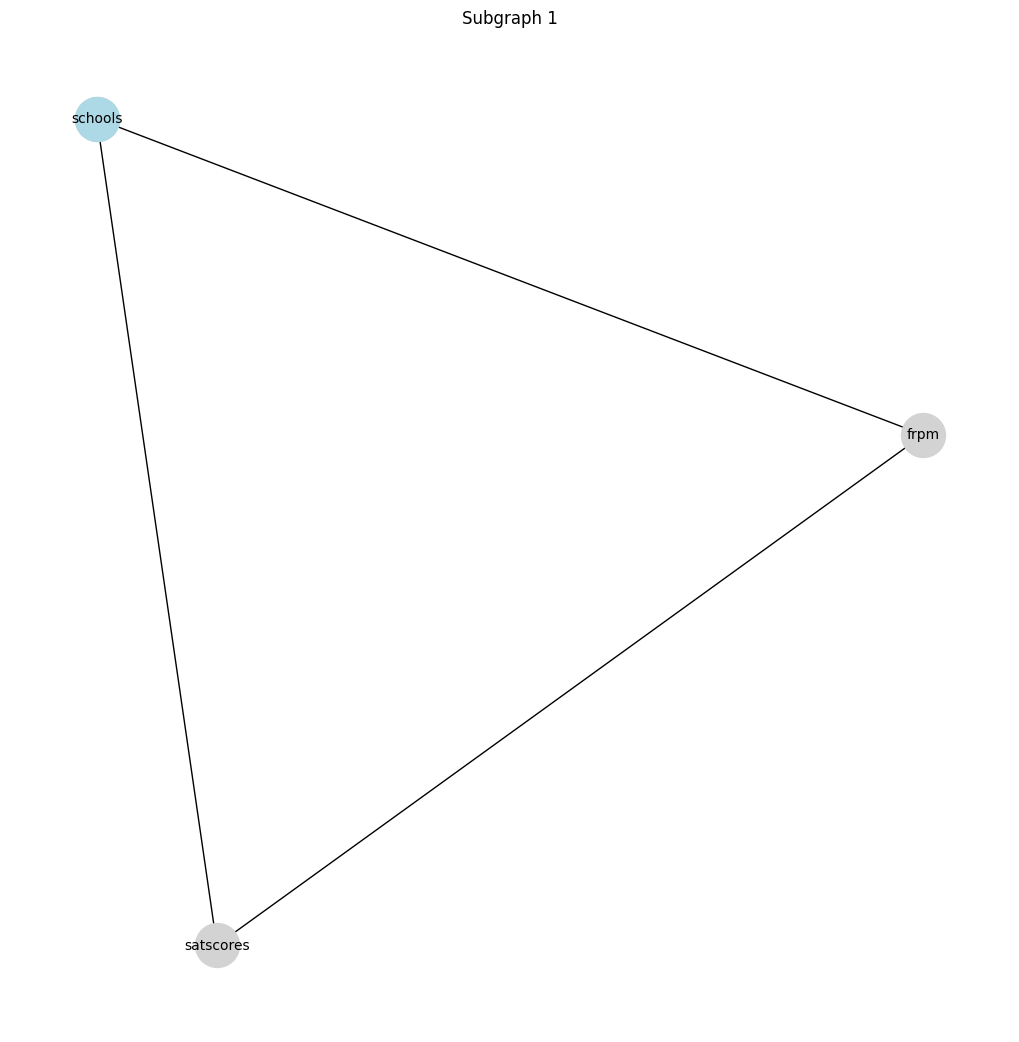

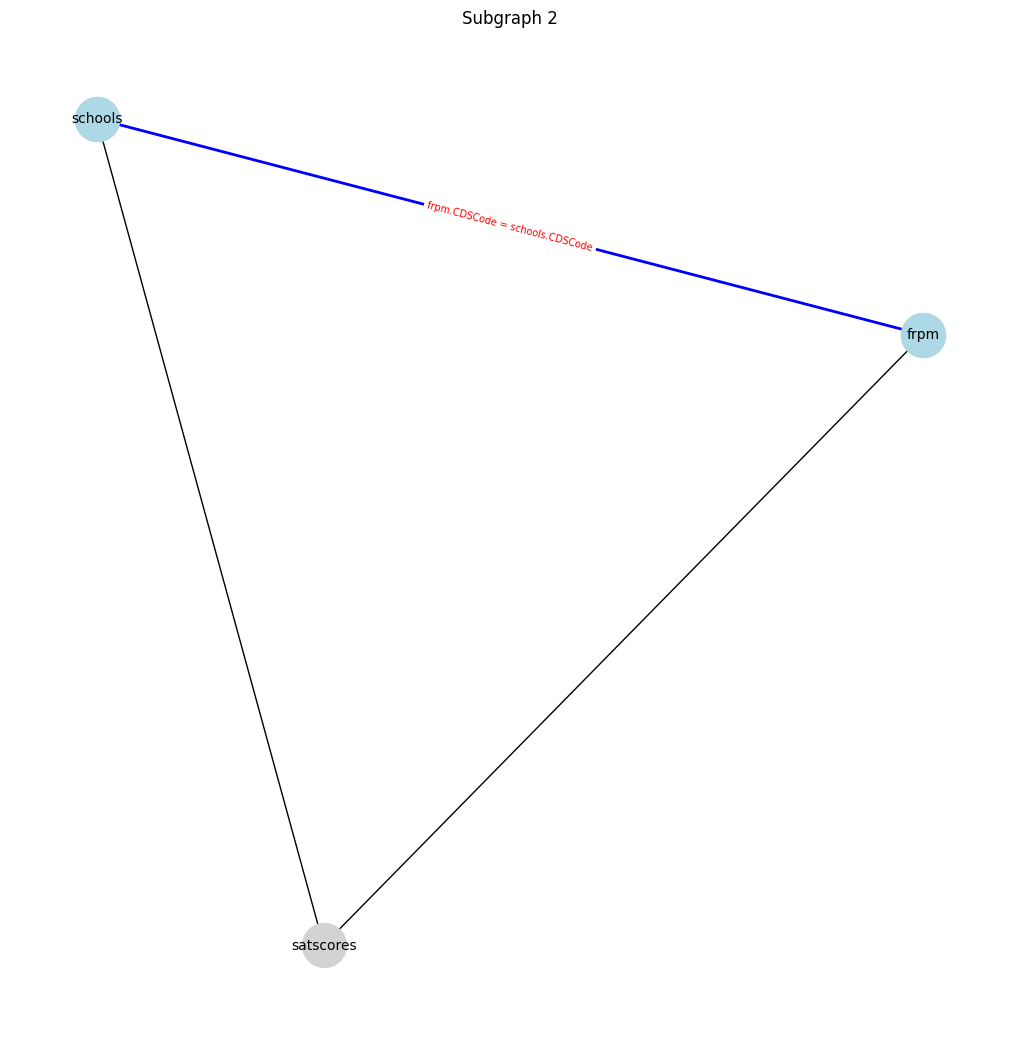

Displaying subgraphs for card_games...


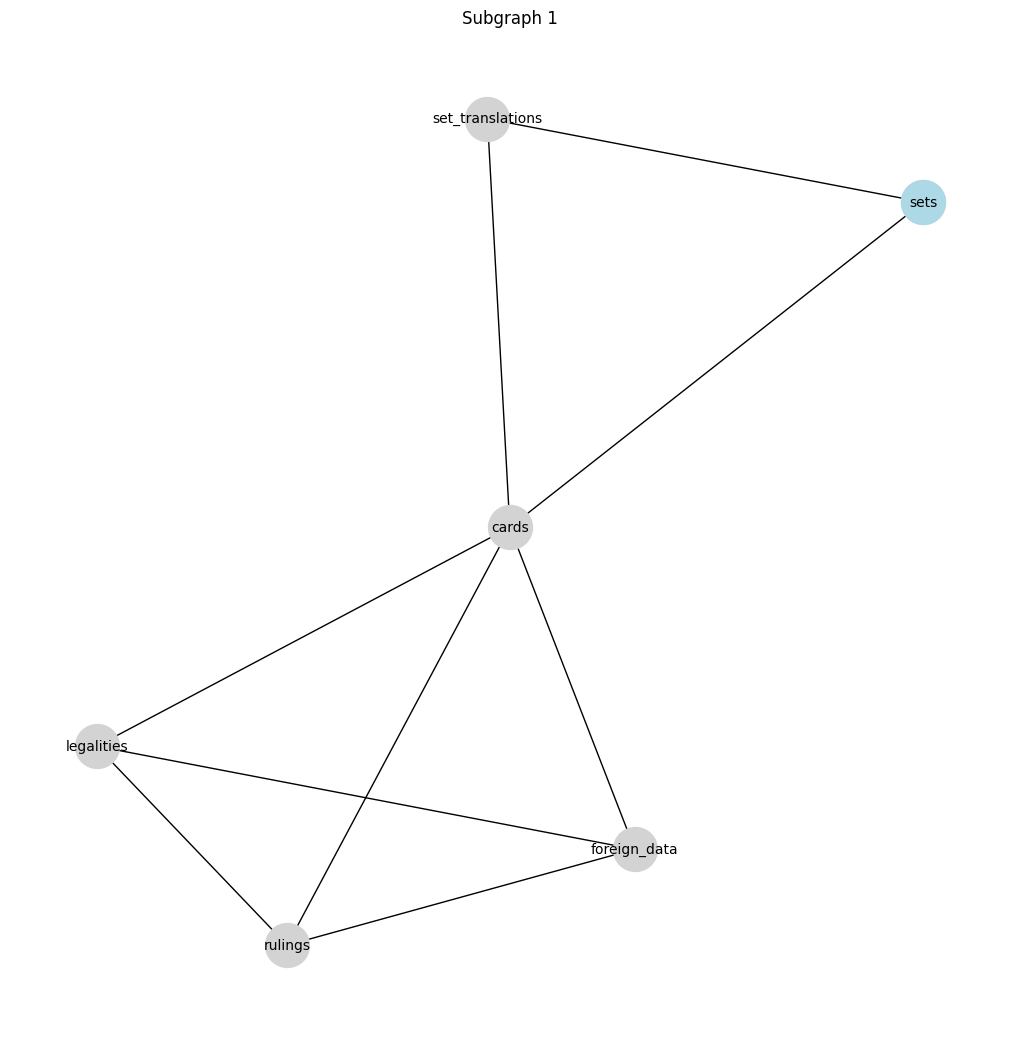

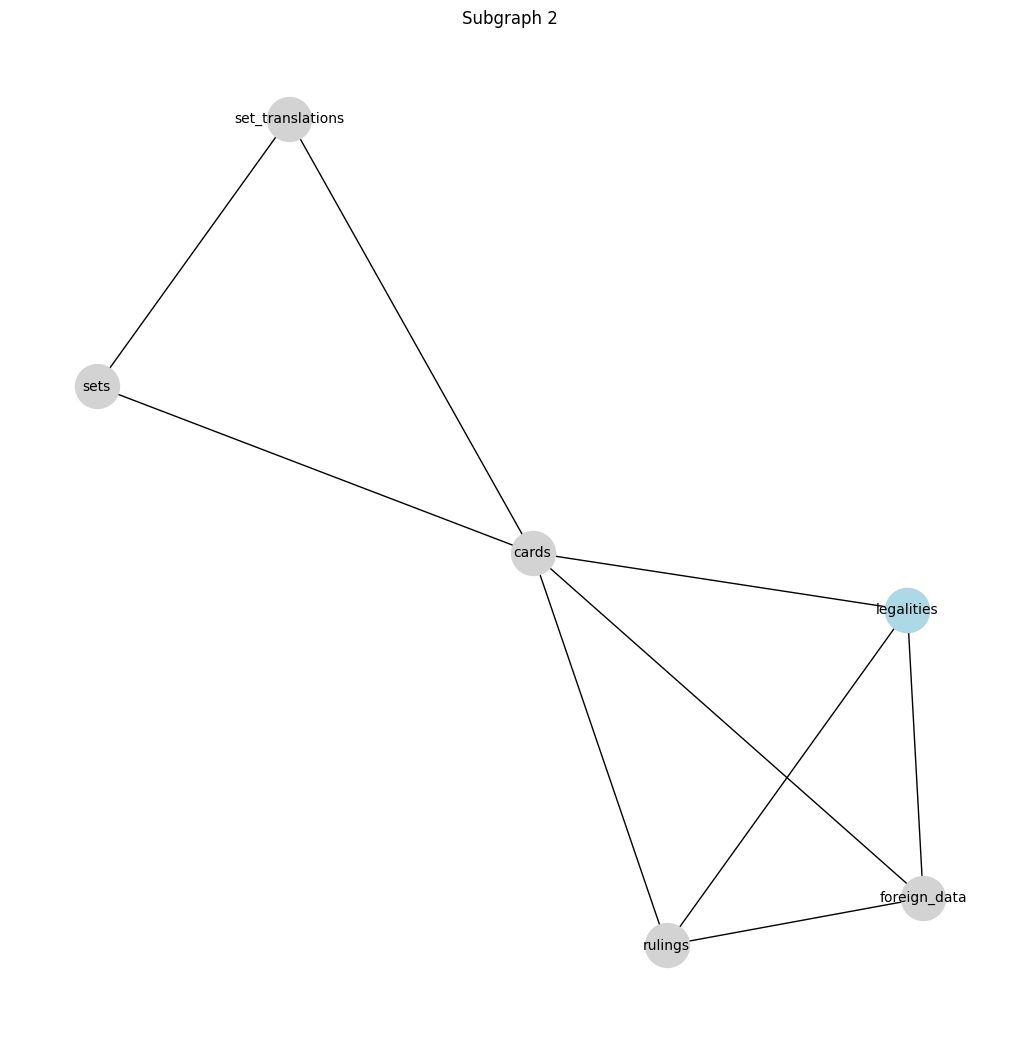

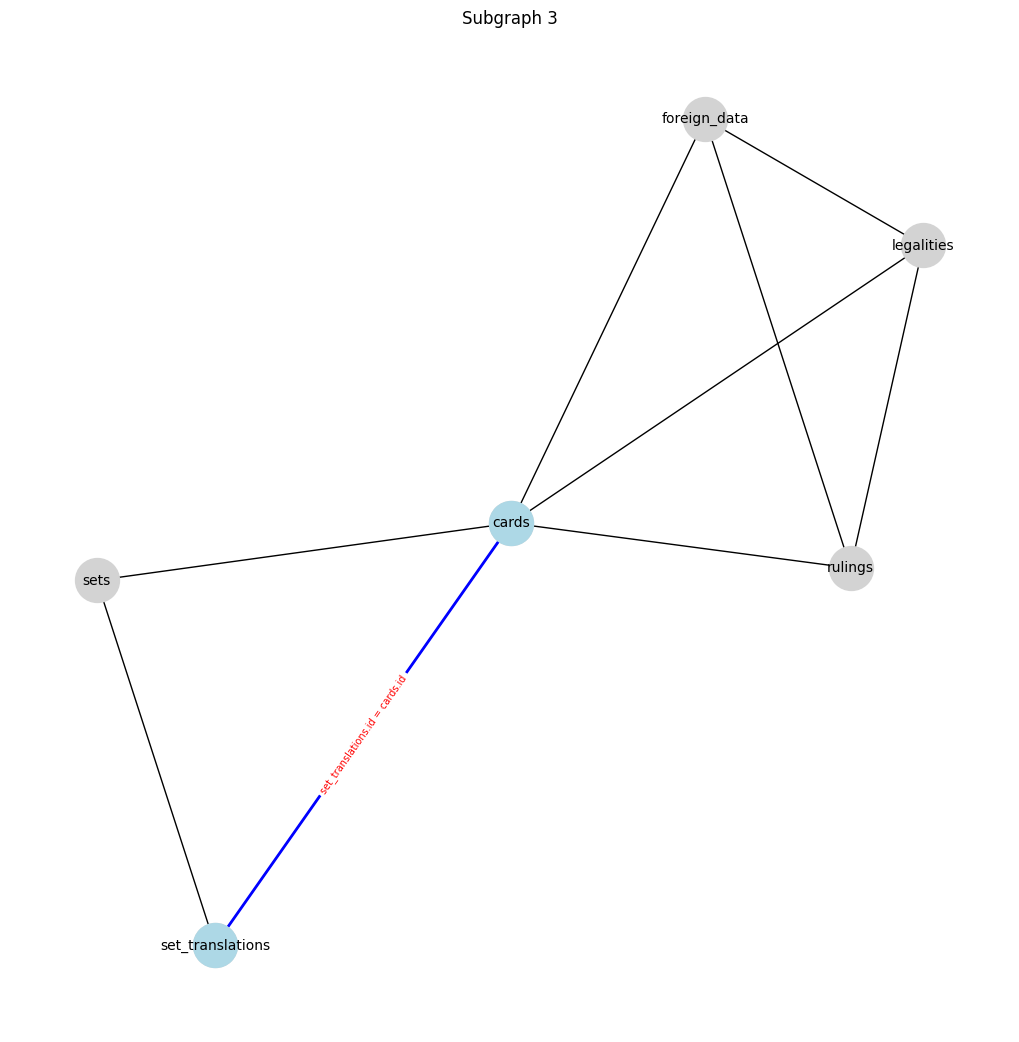

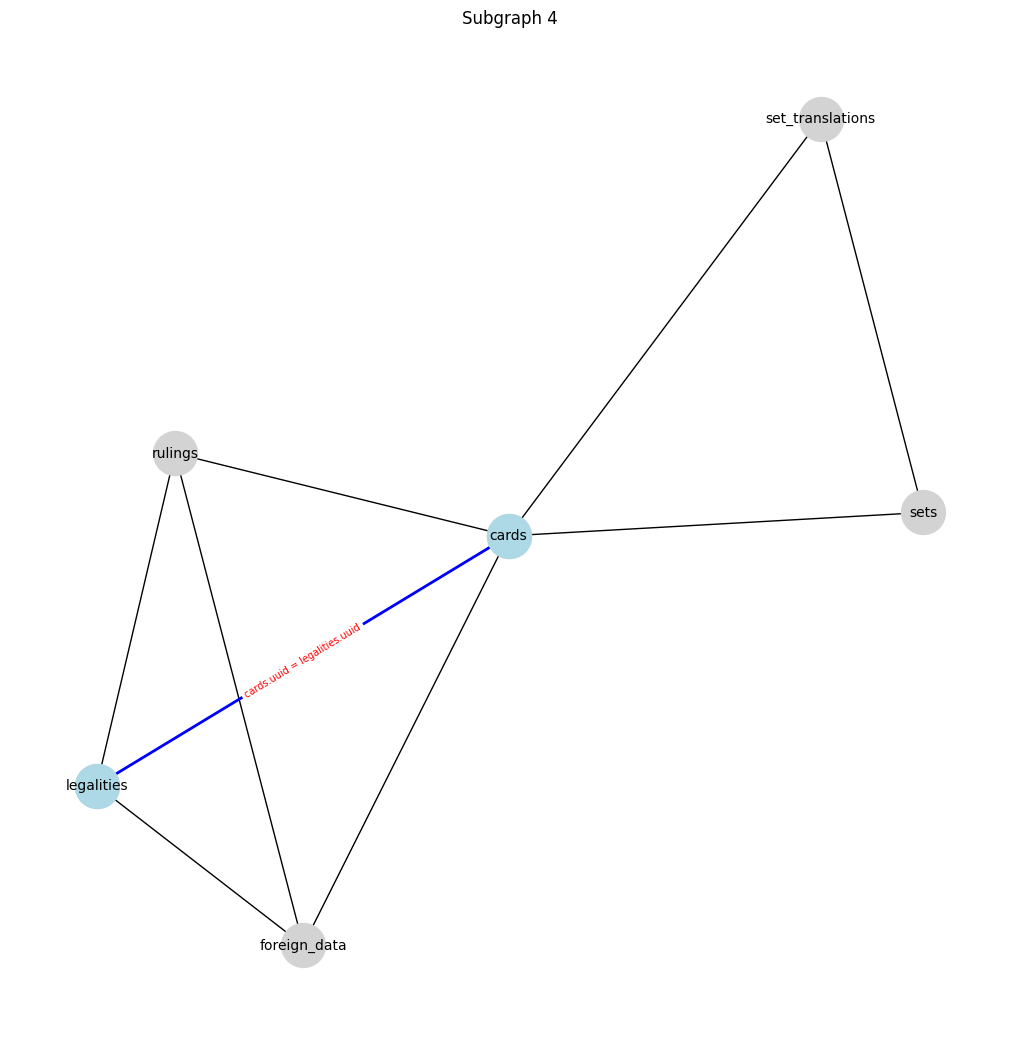

Displaying subgraphs for codebase_community...


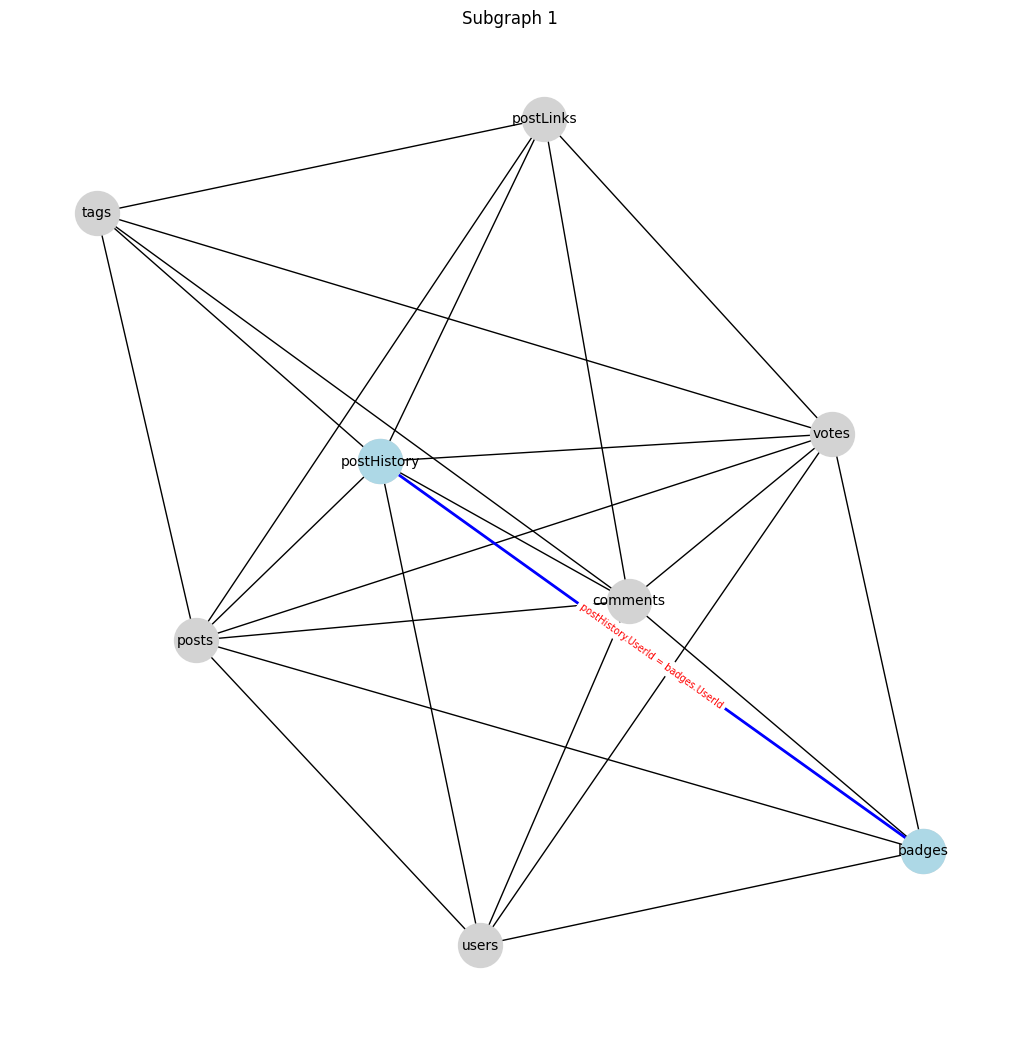

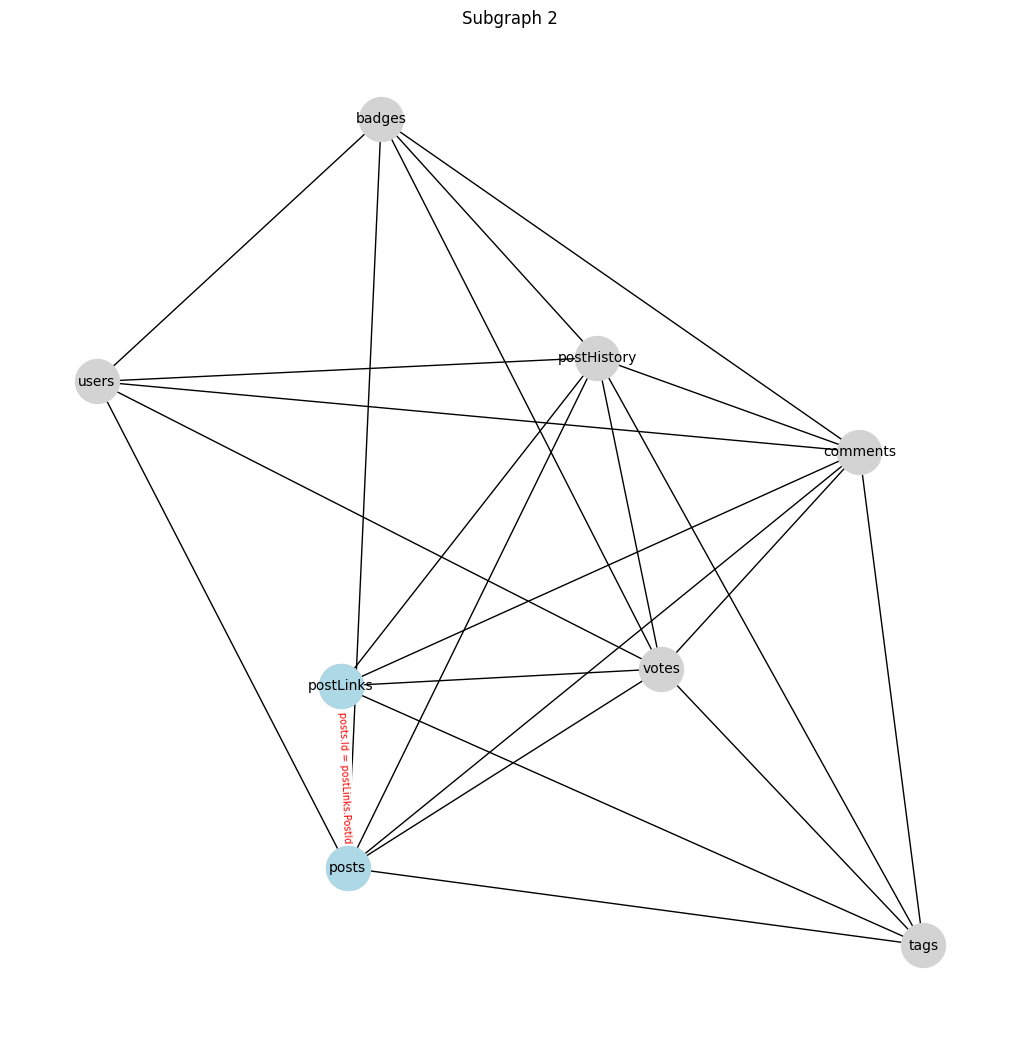

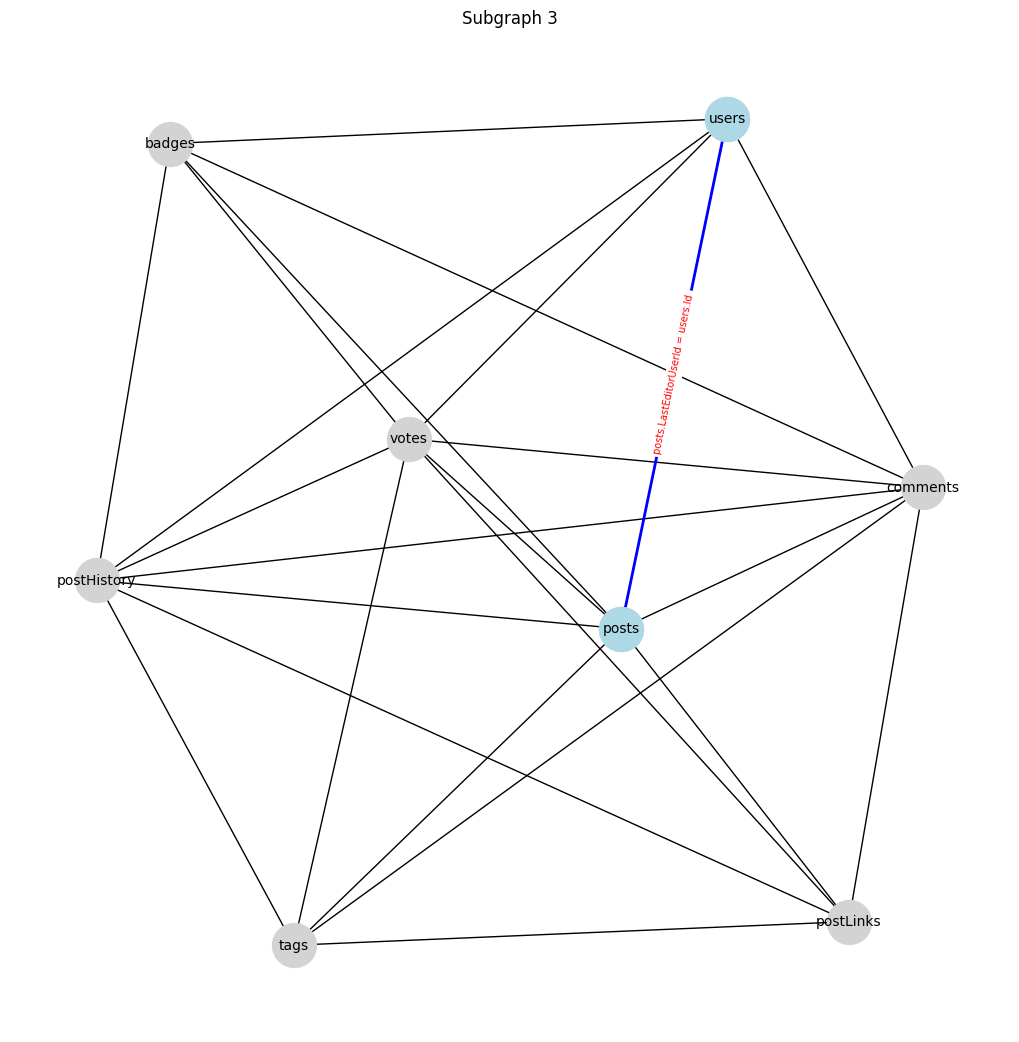

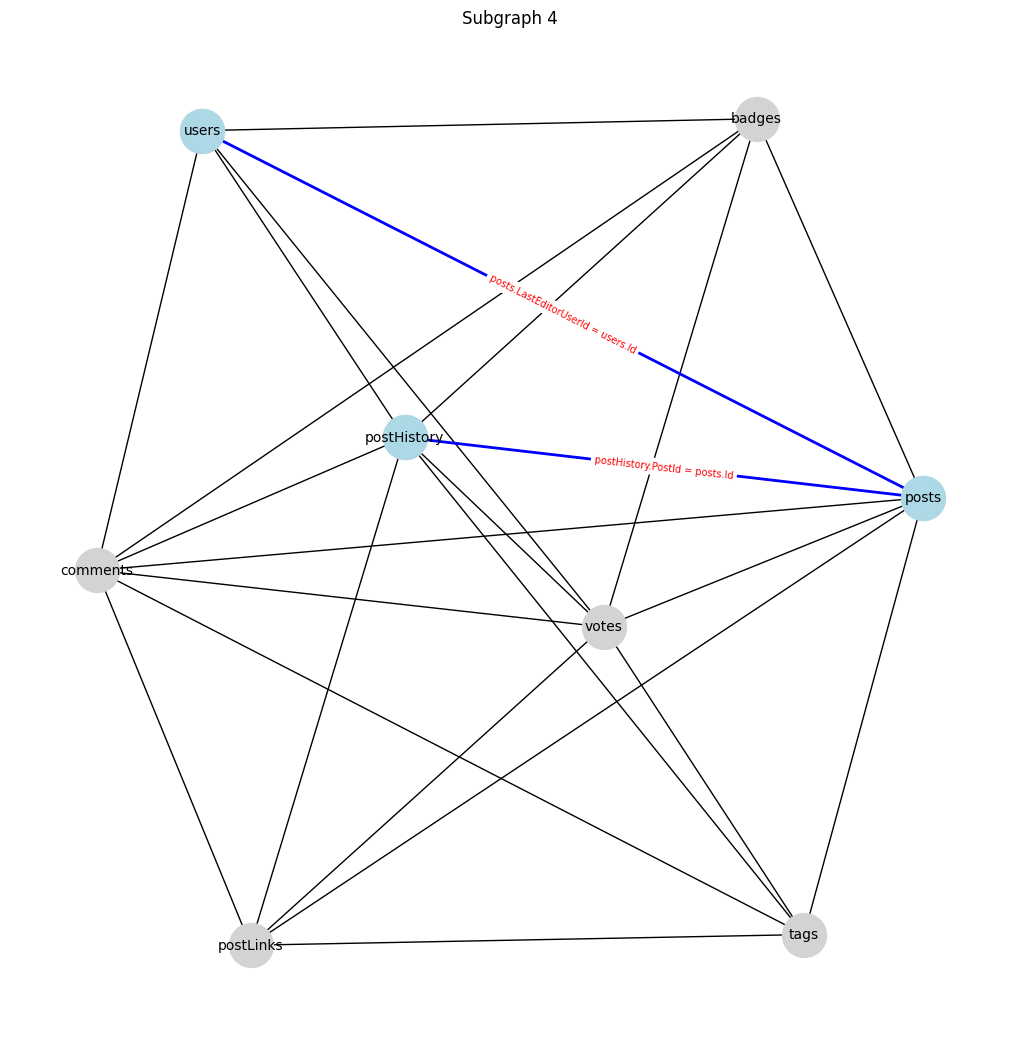

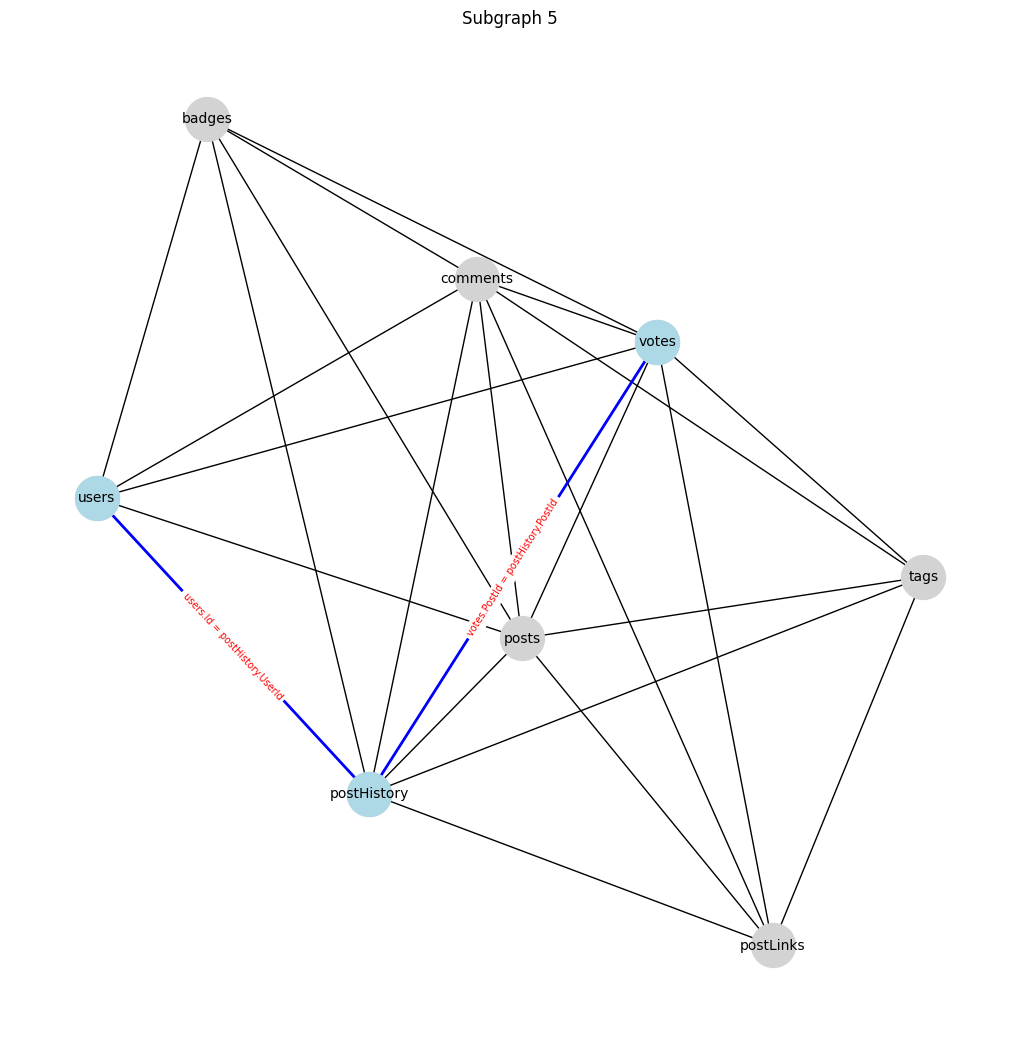

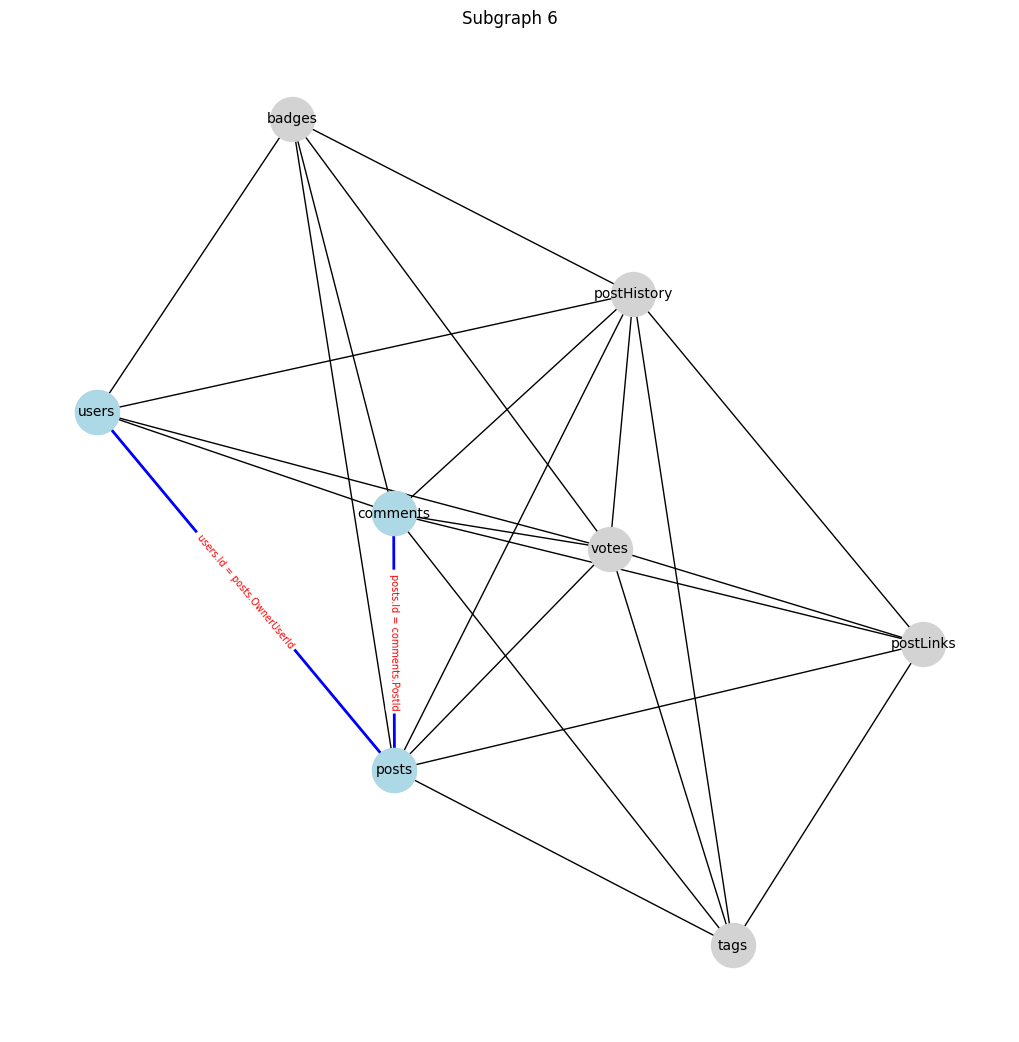

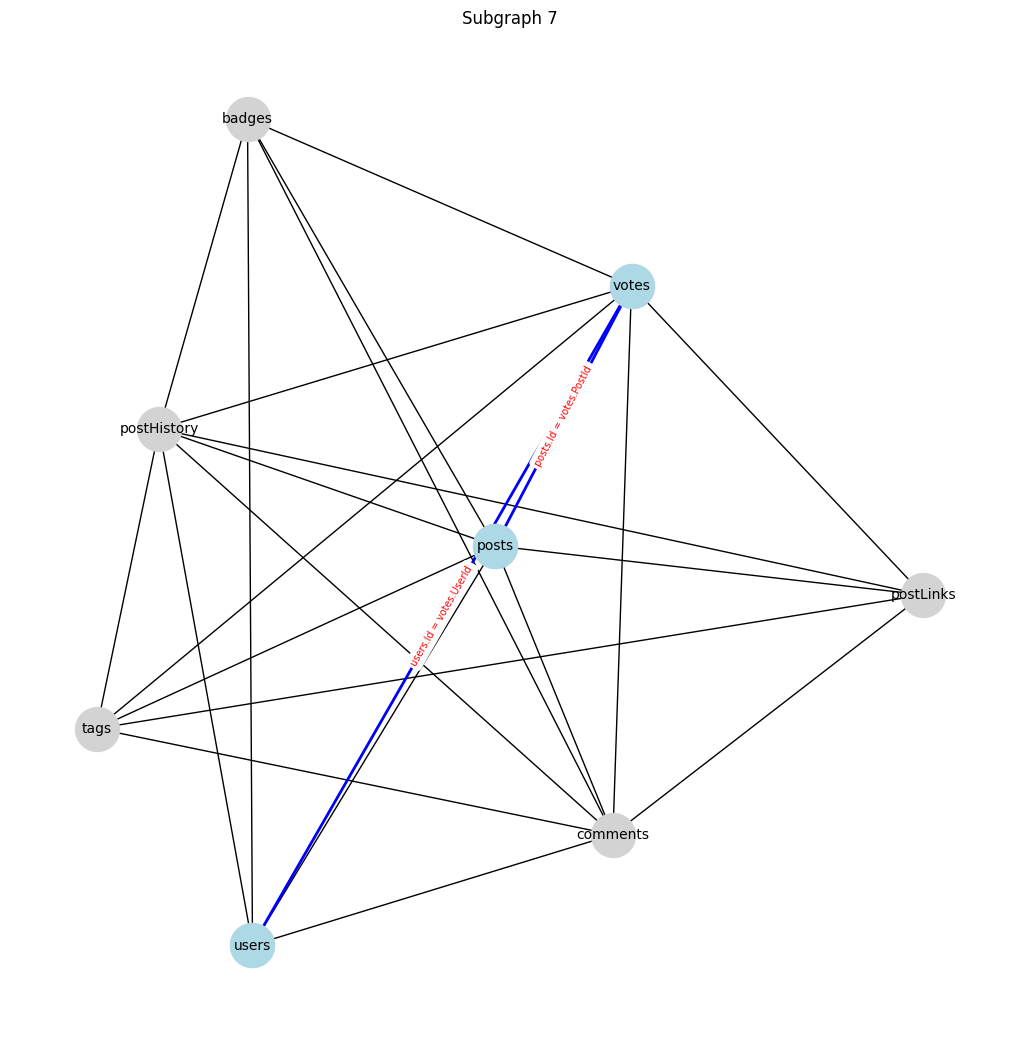

Displaying subgraphs for debit_card_specializing...


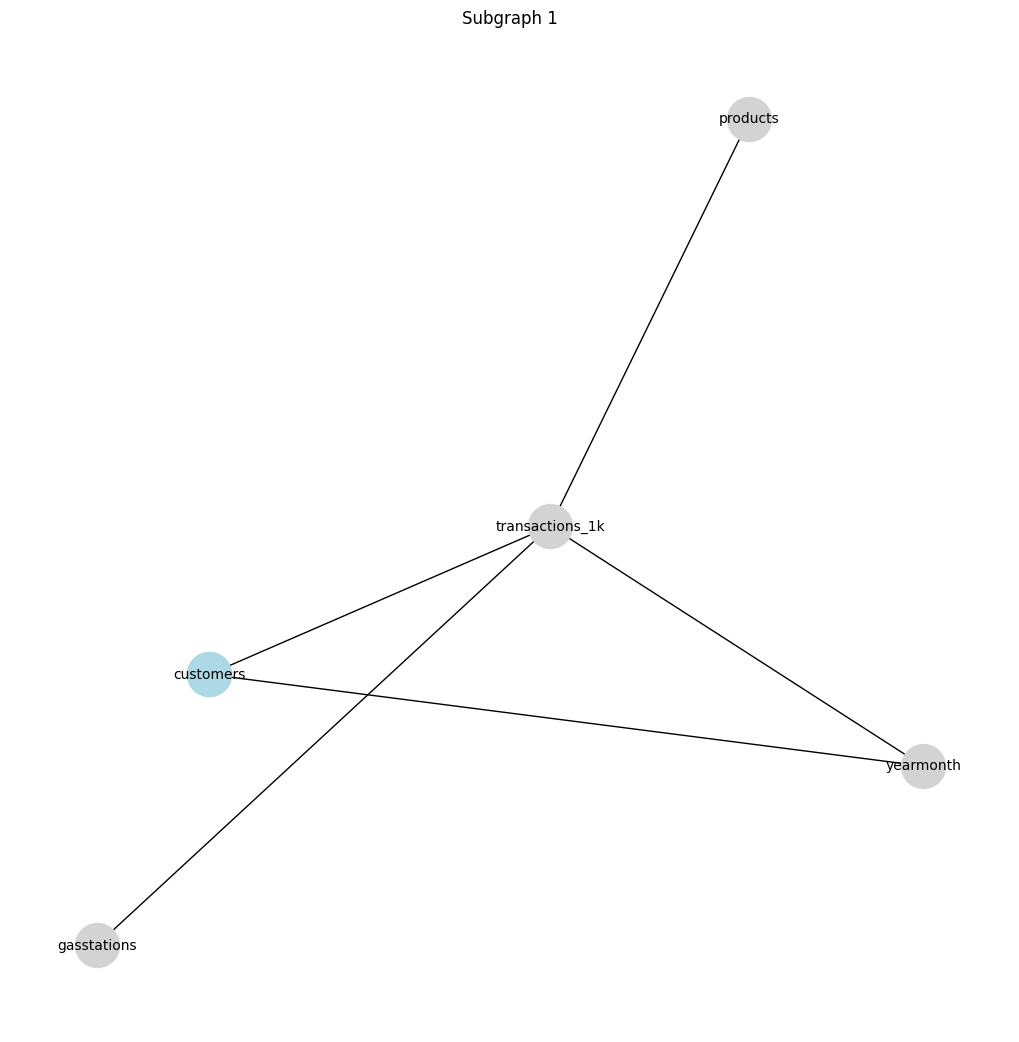

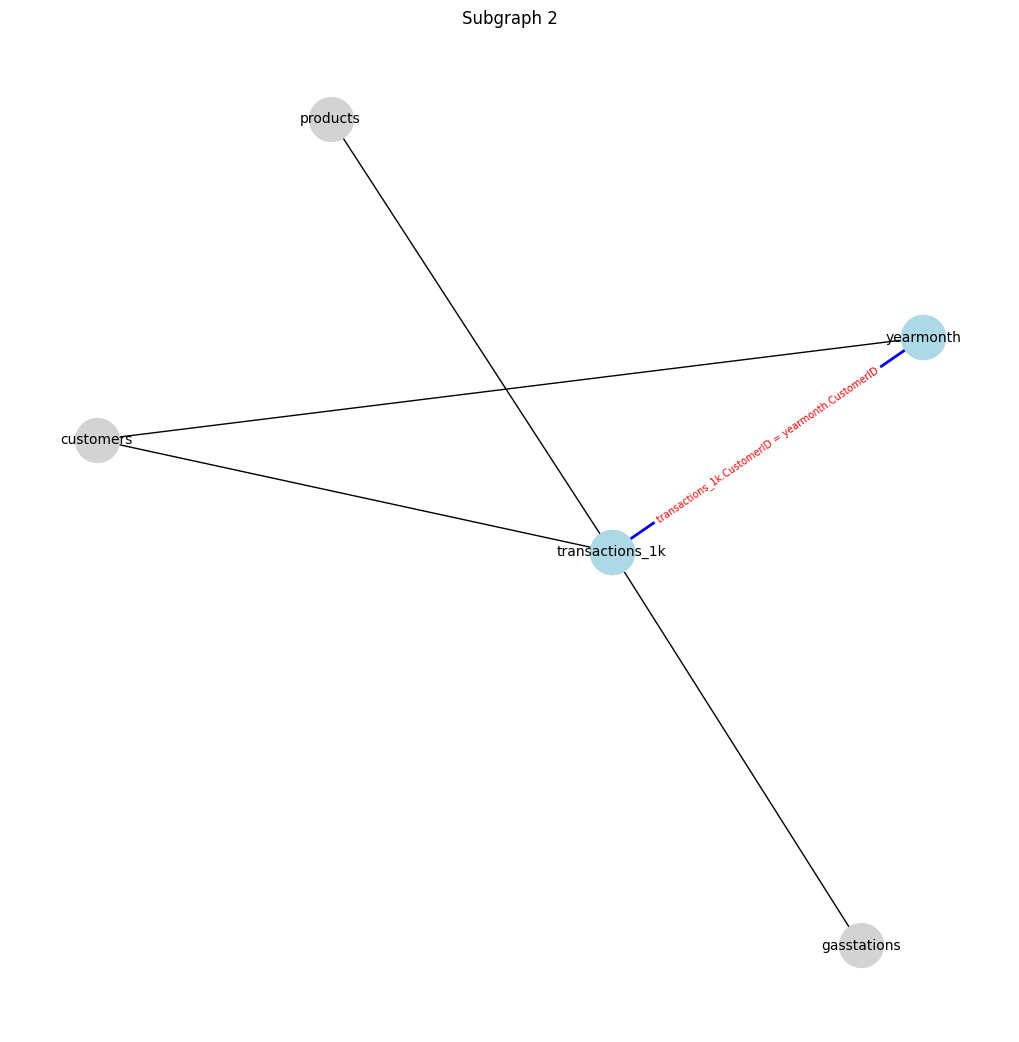

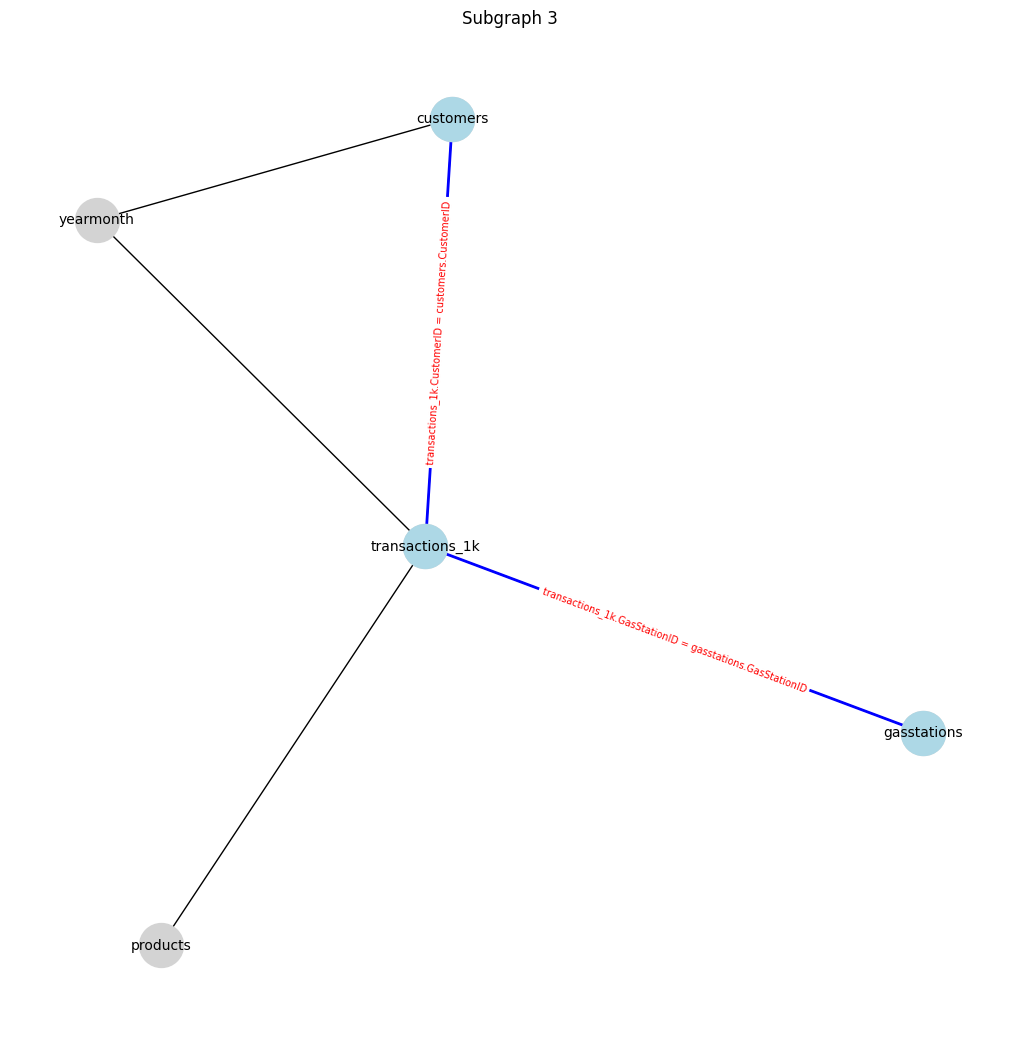

Displaying subgraphs for european_football_2...


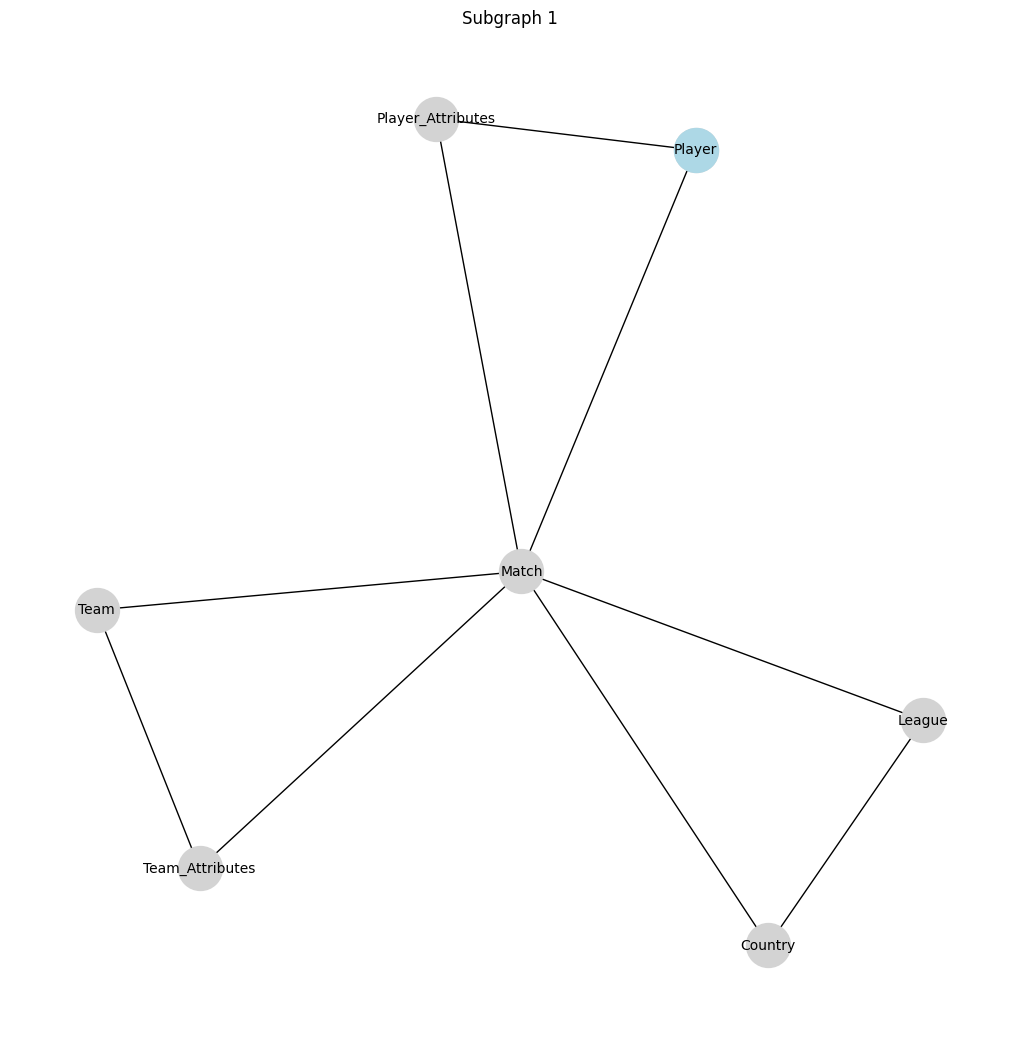

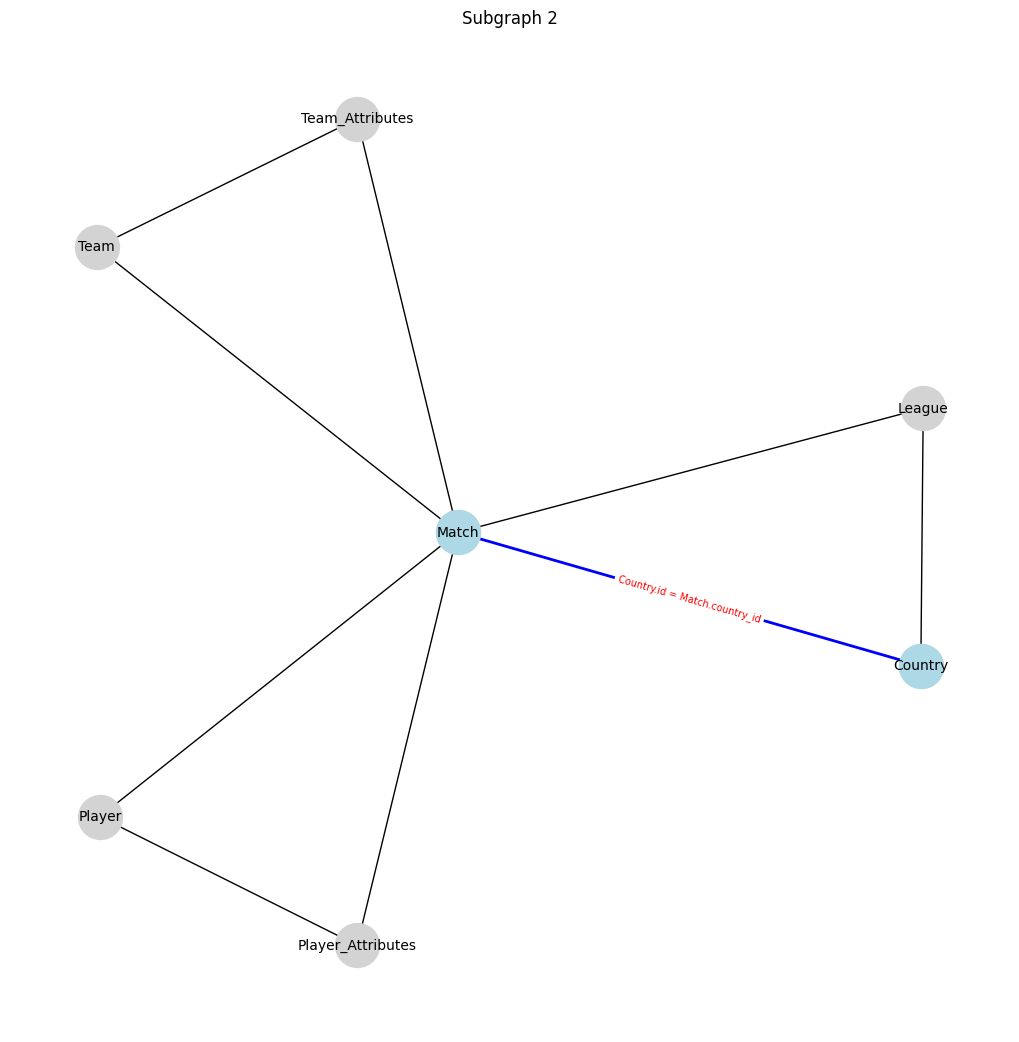

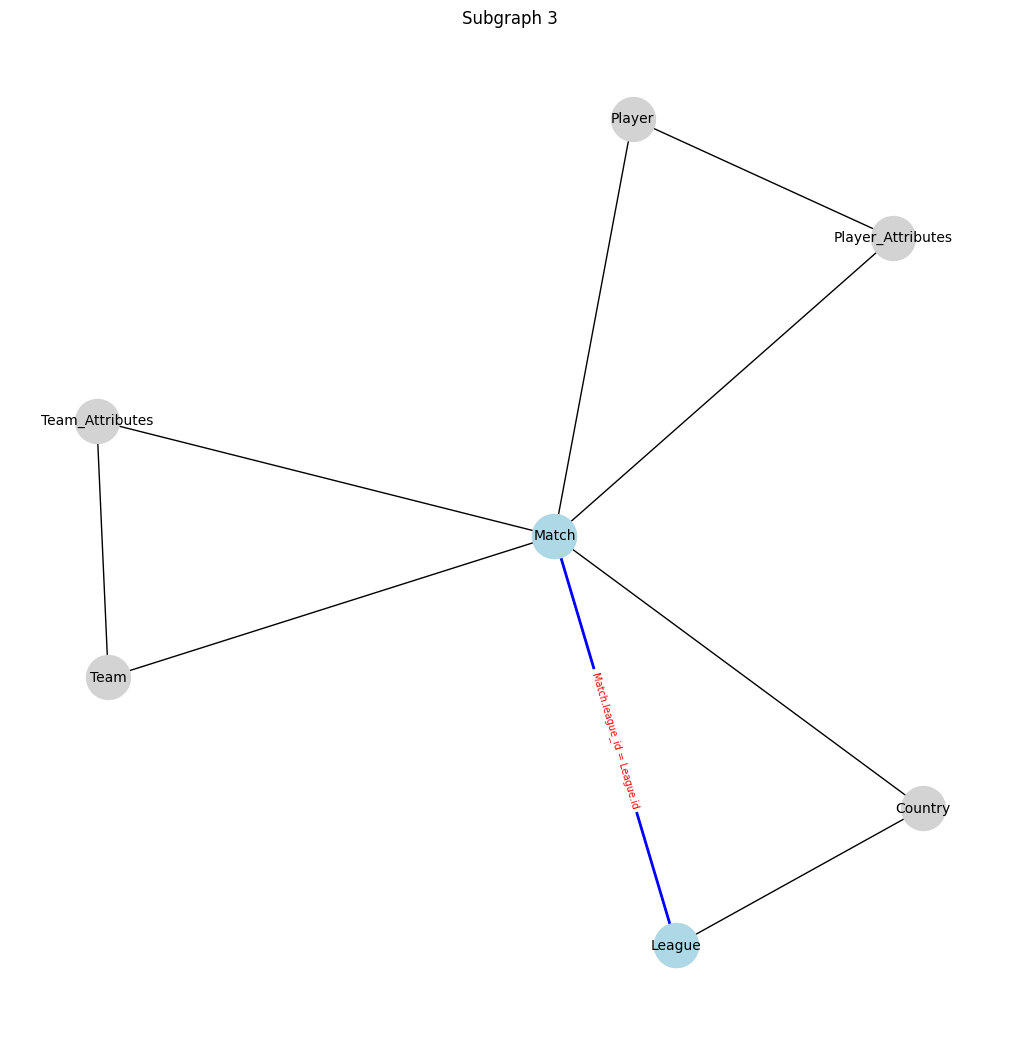

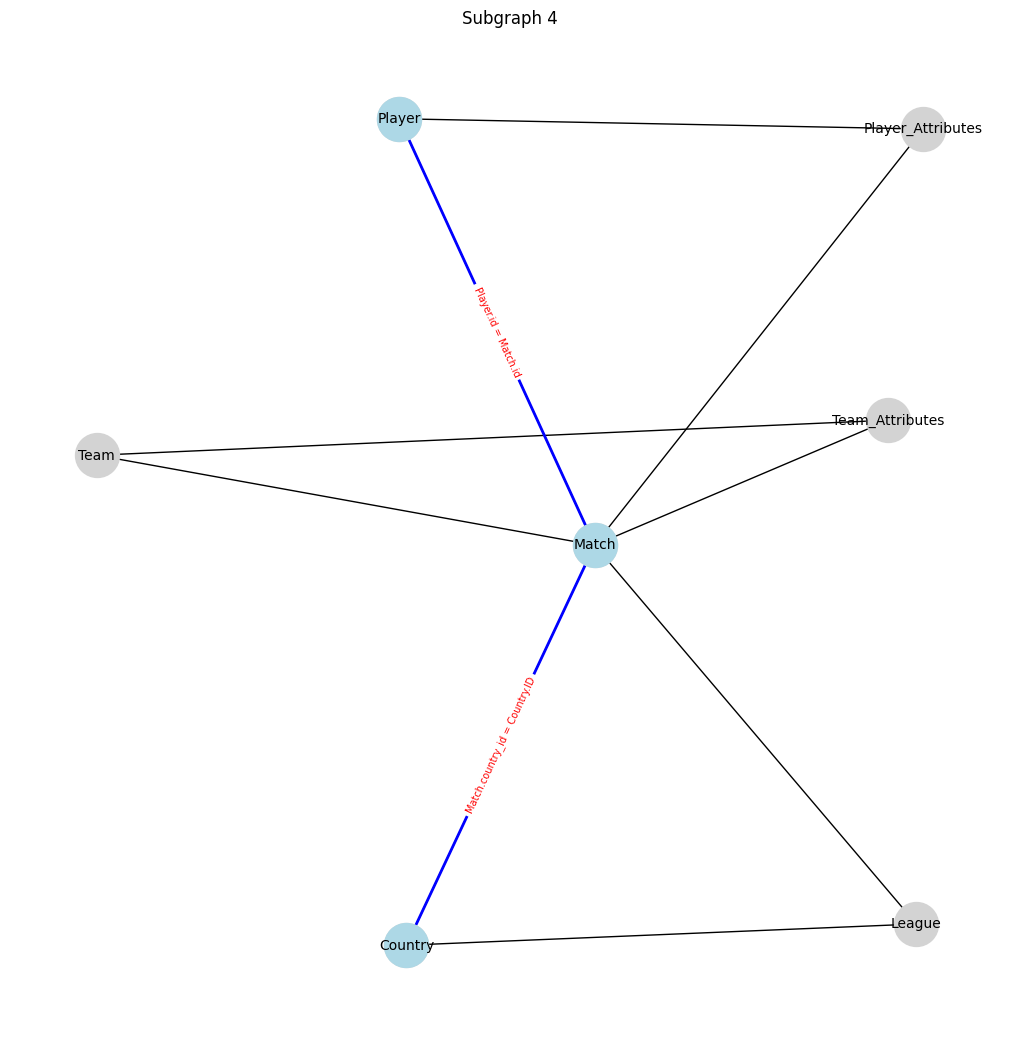

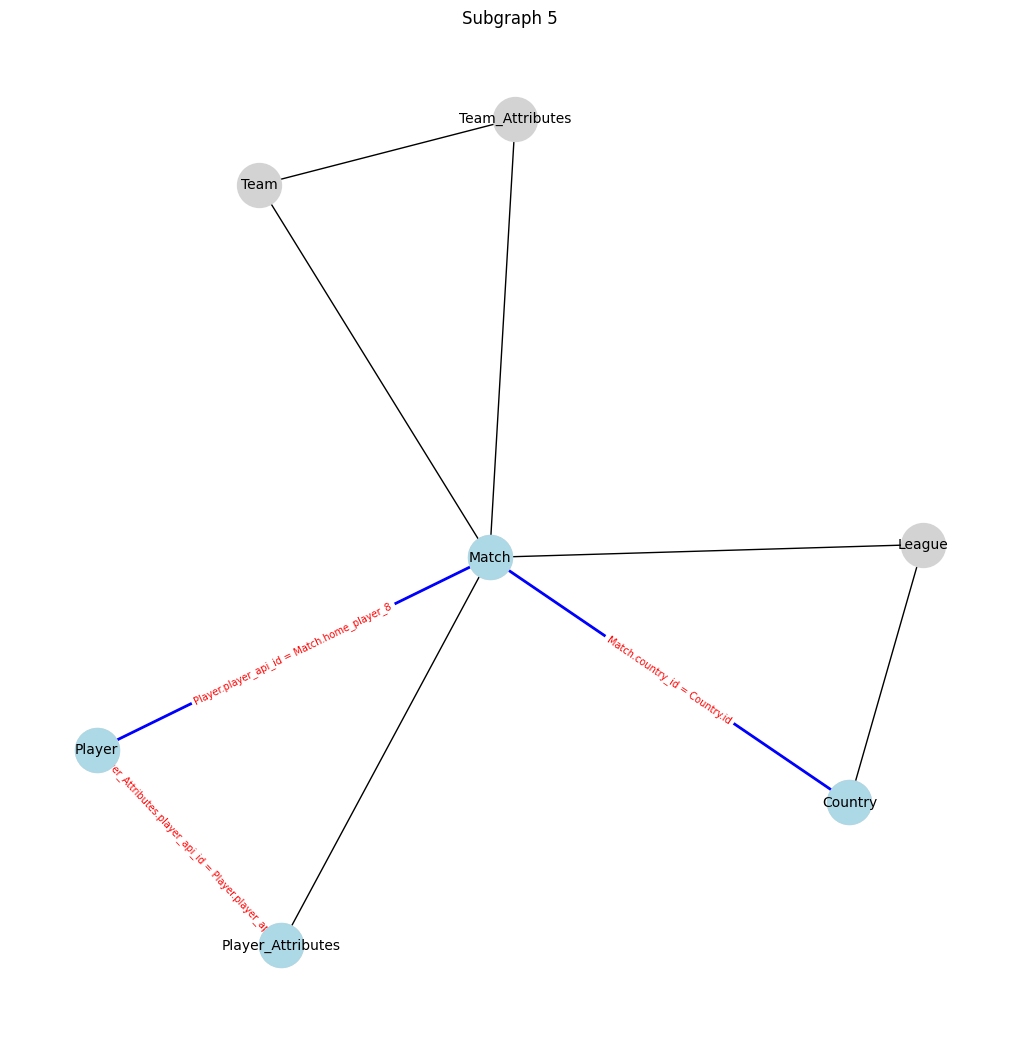

Displaying subgraphs for financial...


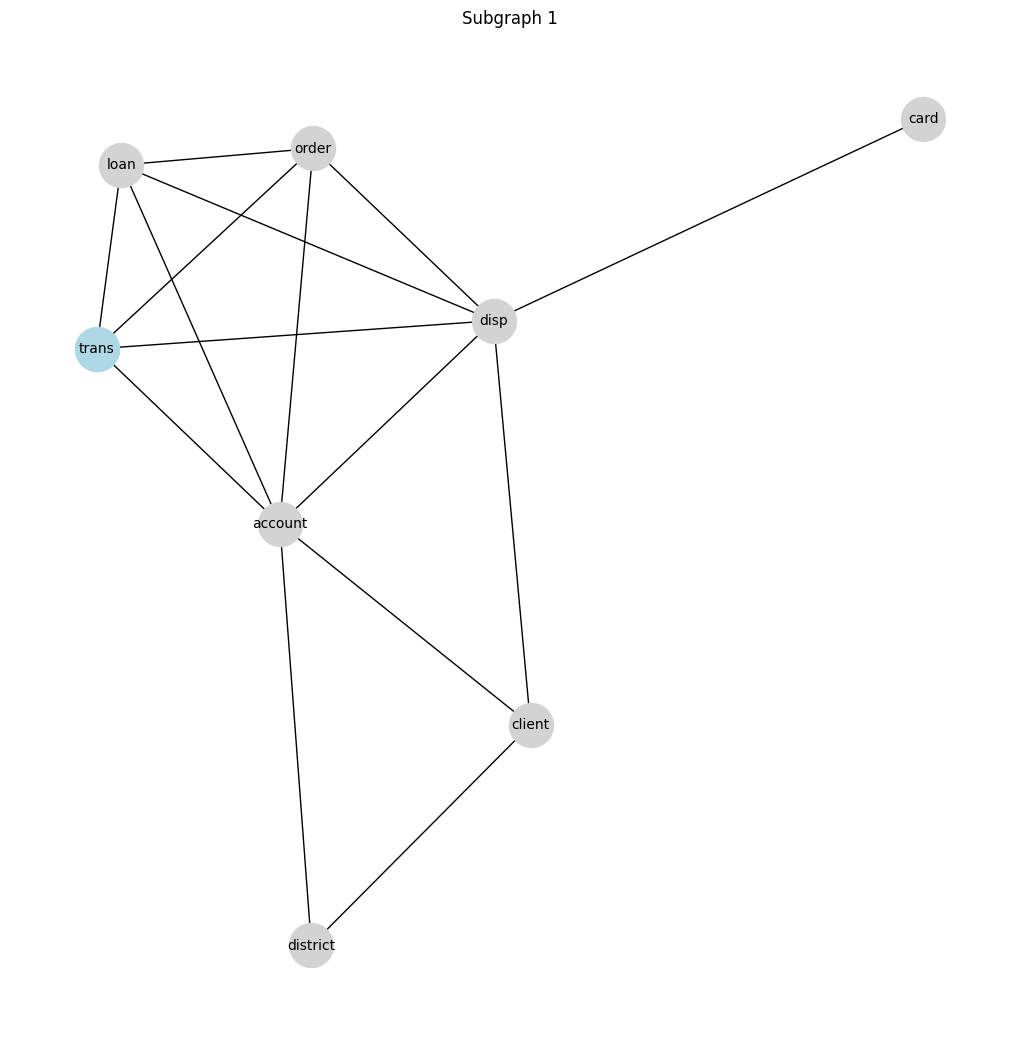

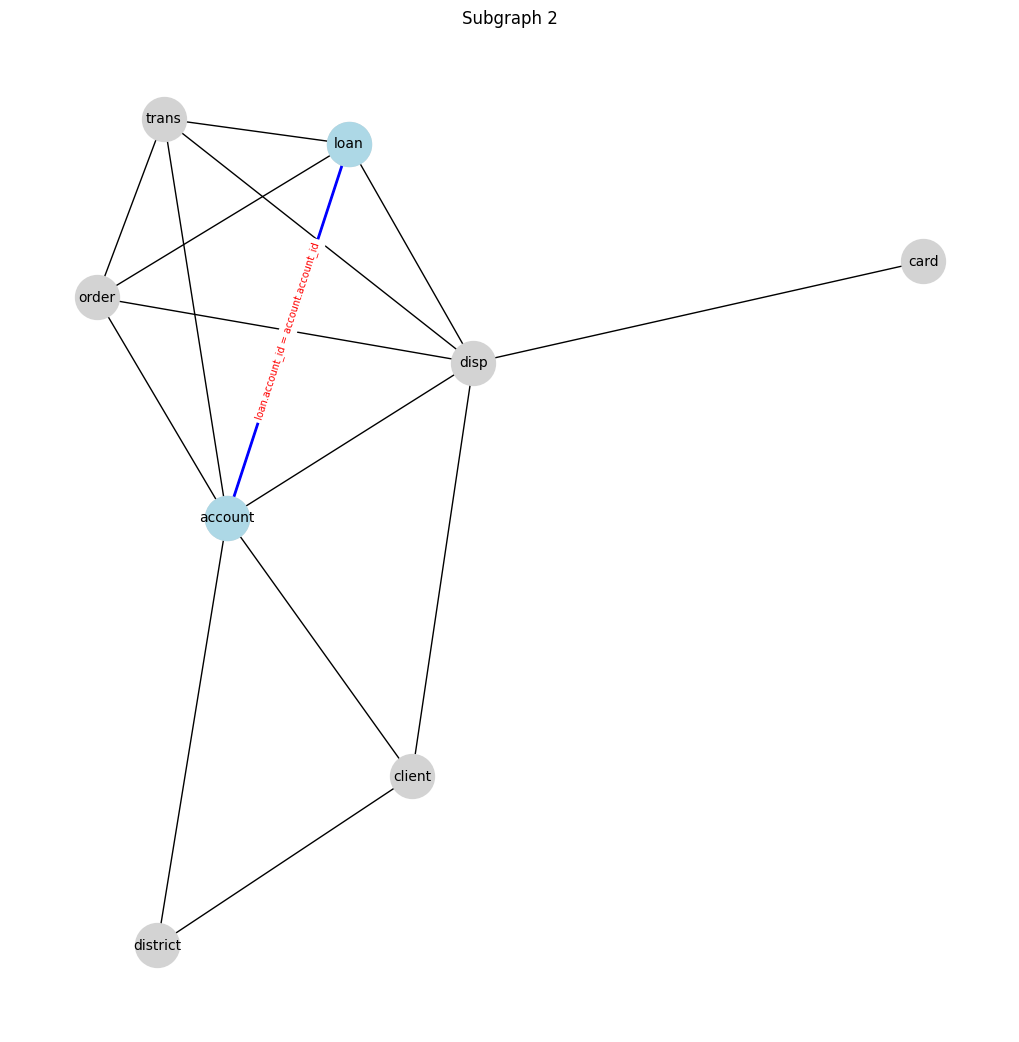

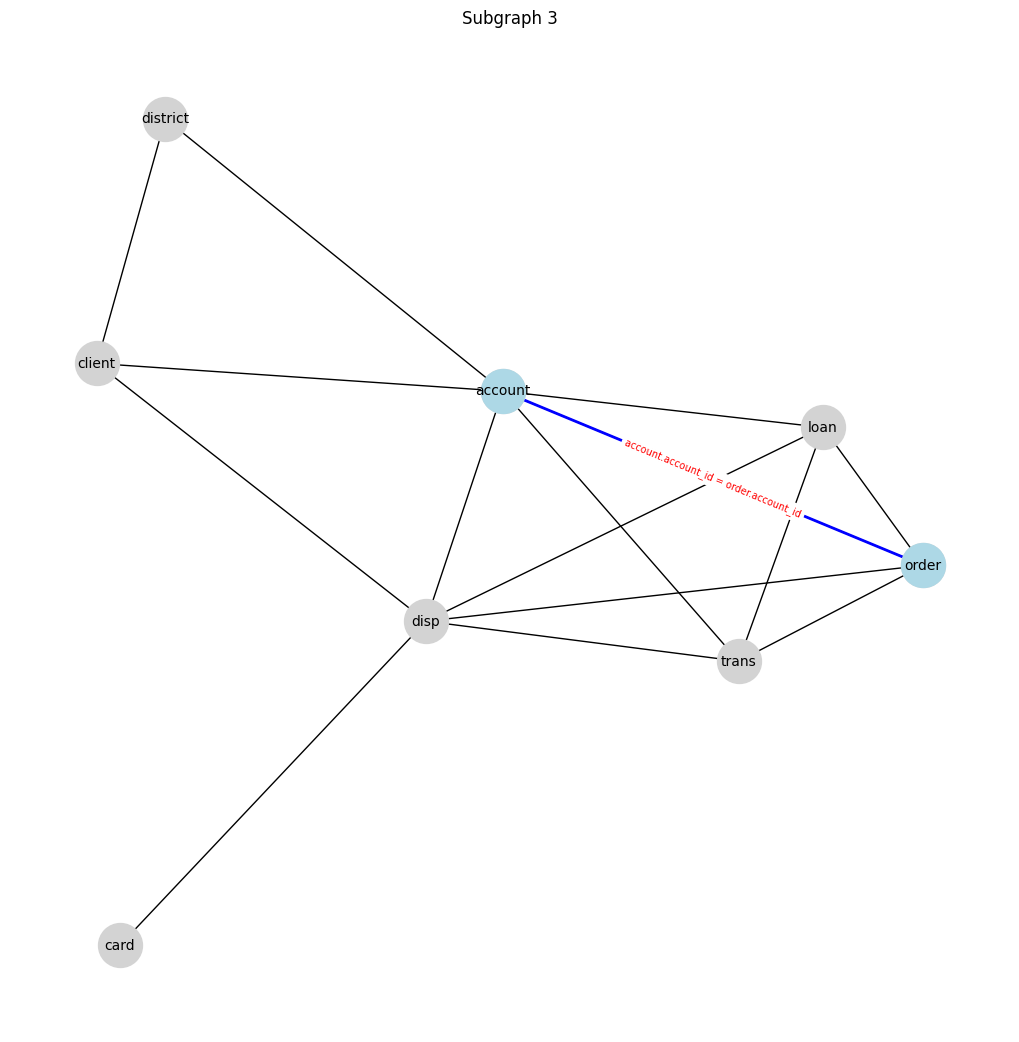

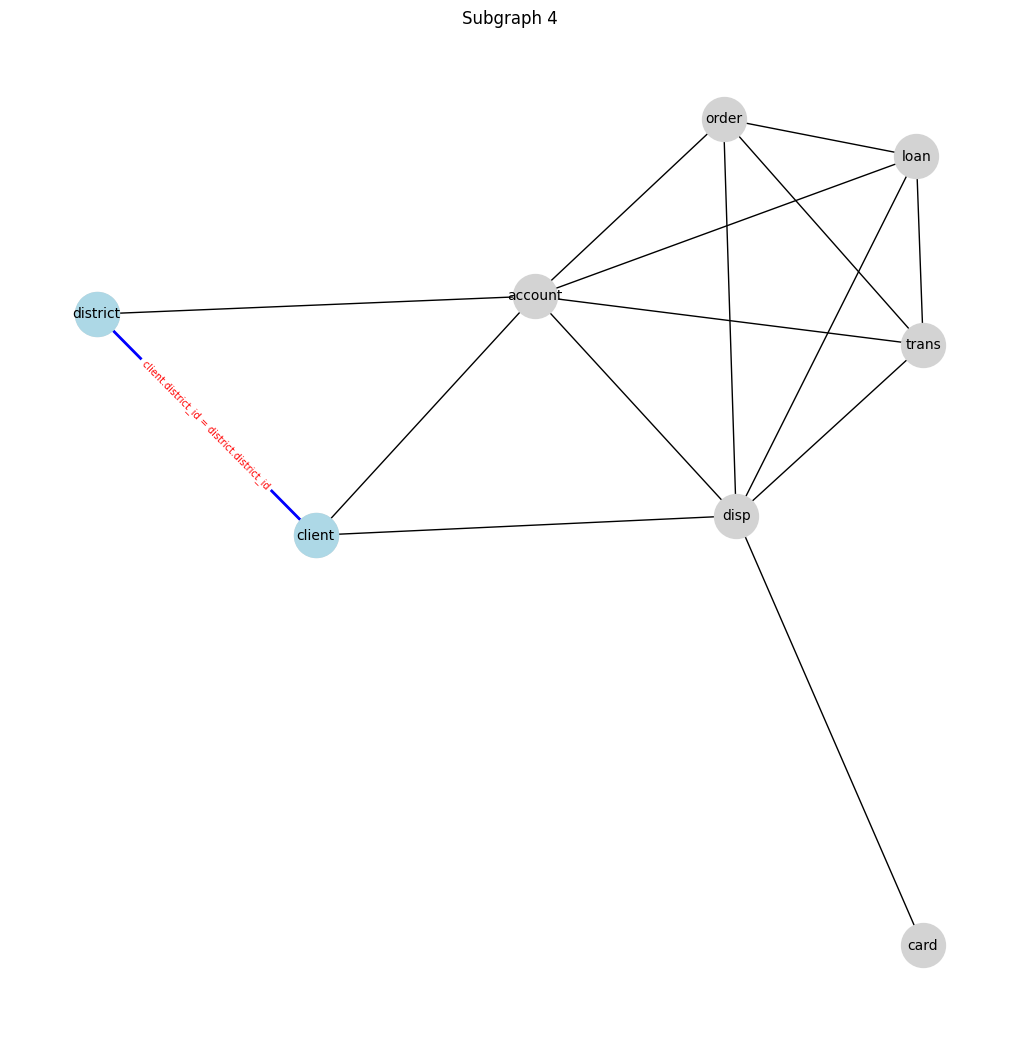

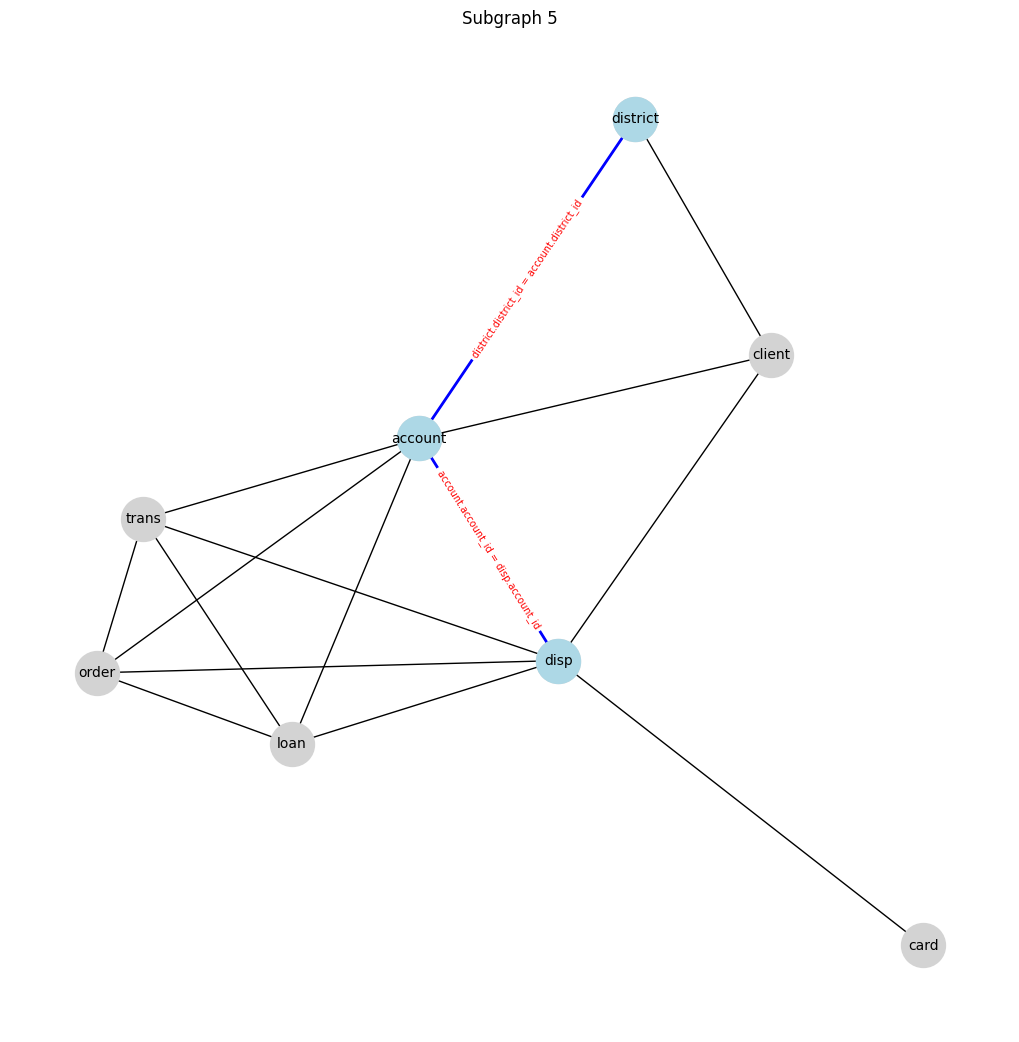

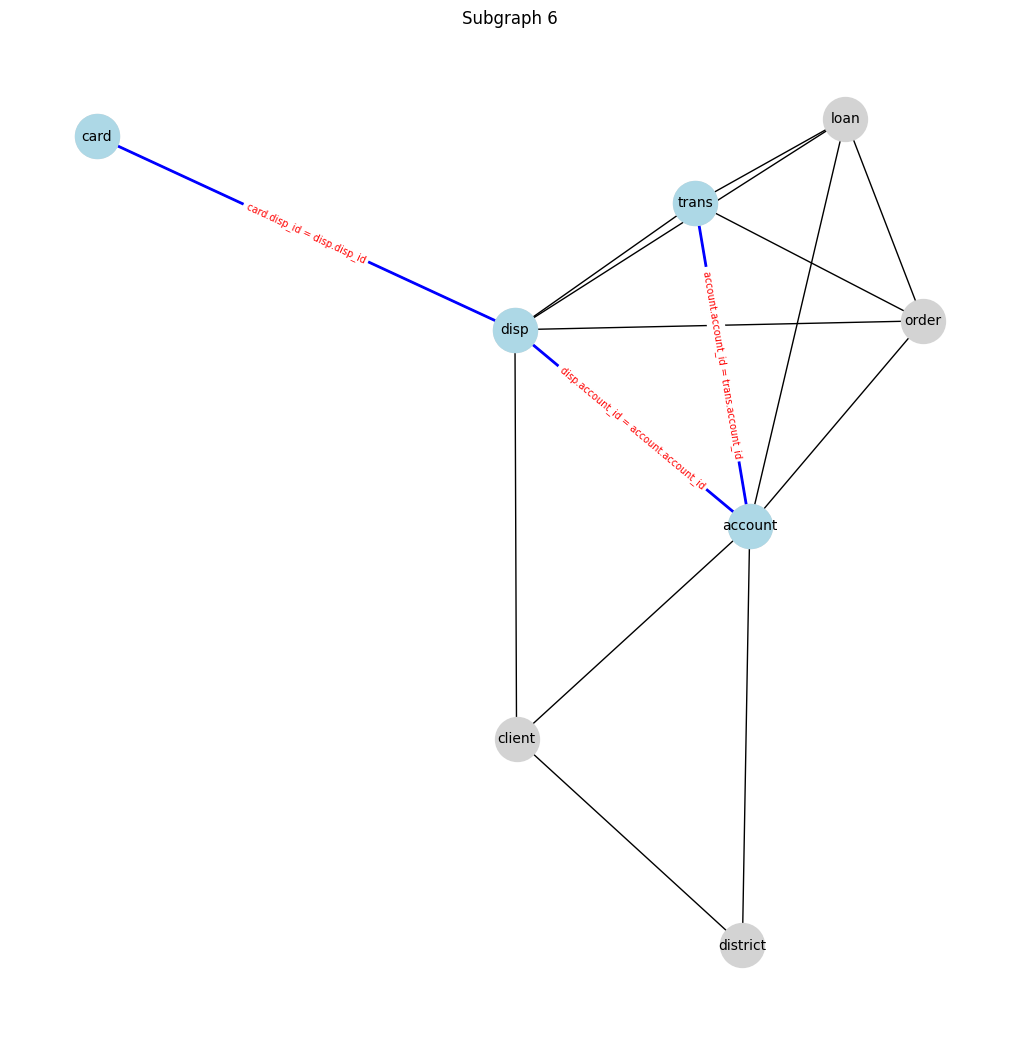

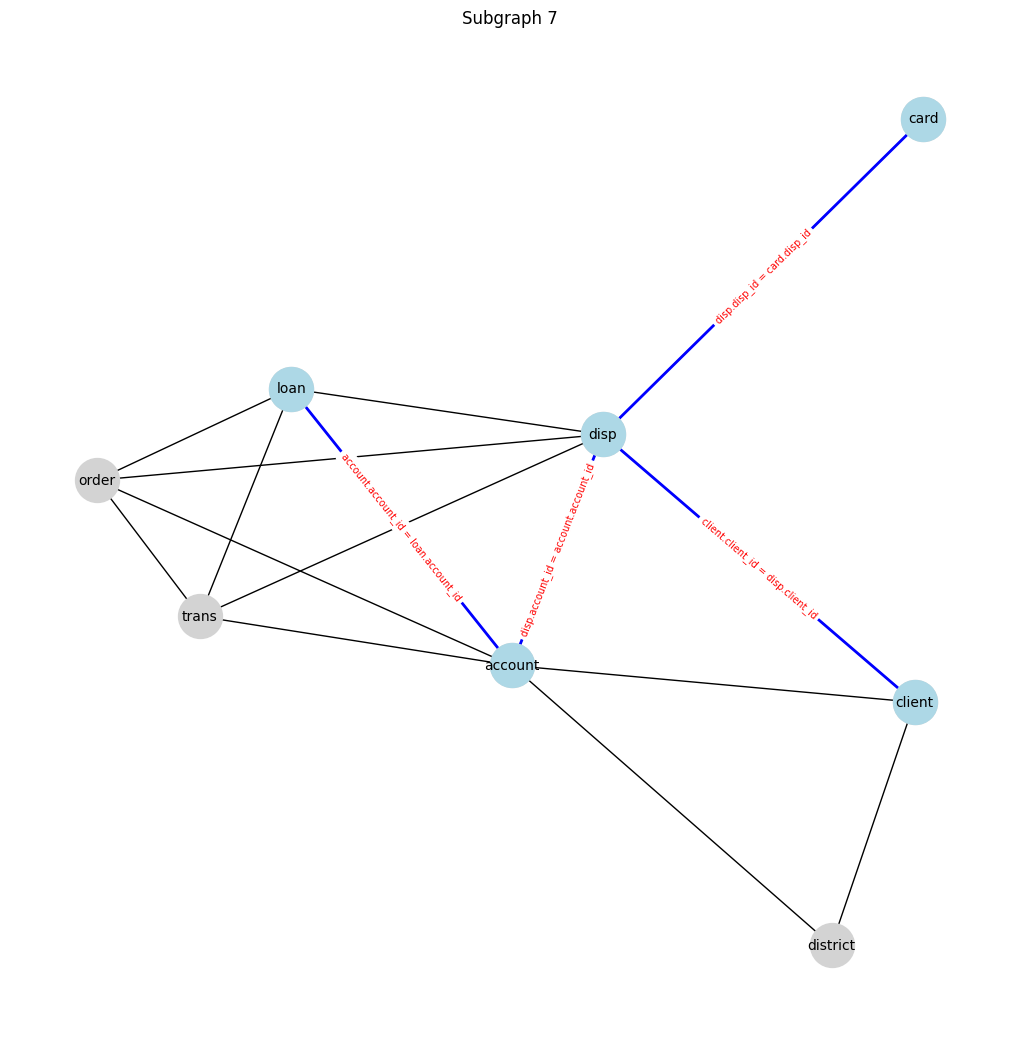

Displaying subgraphs for formula_1...


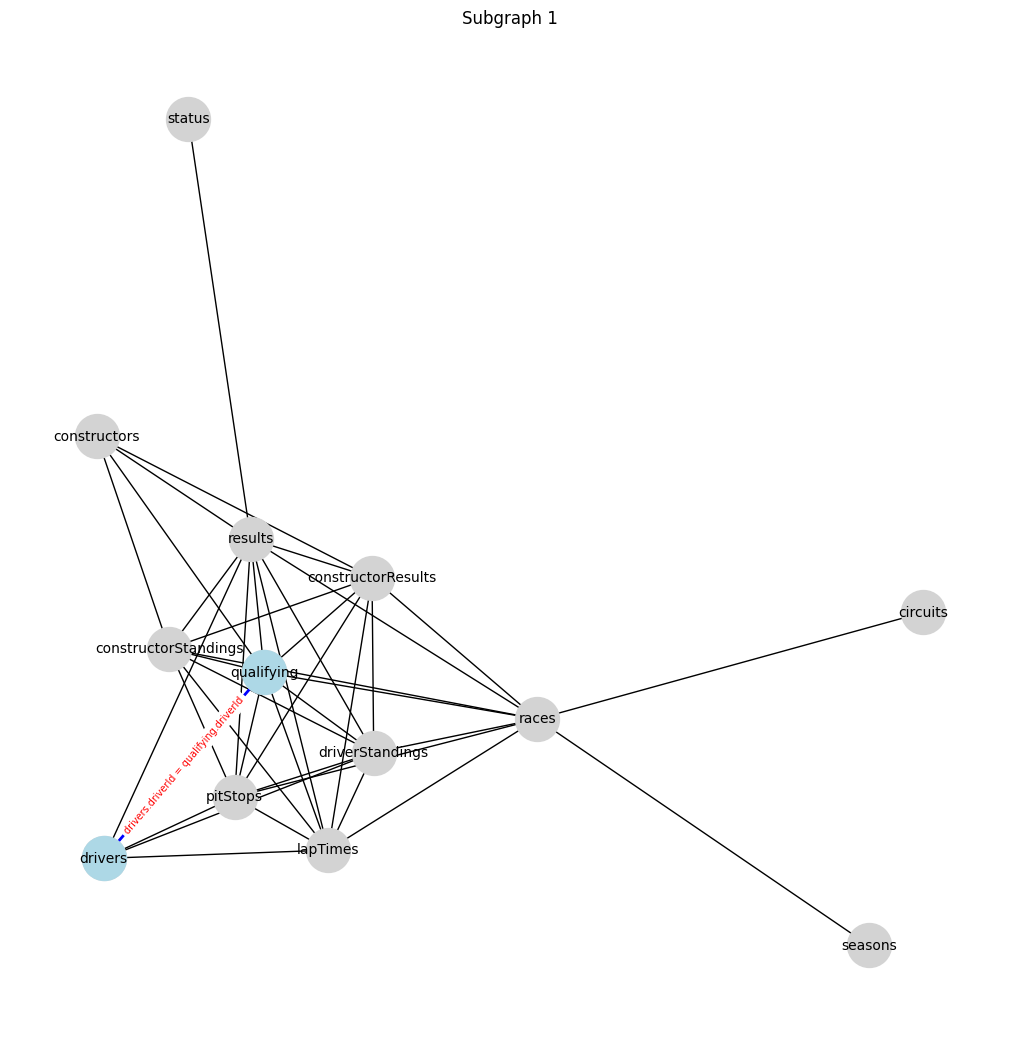

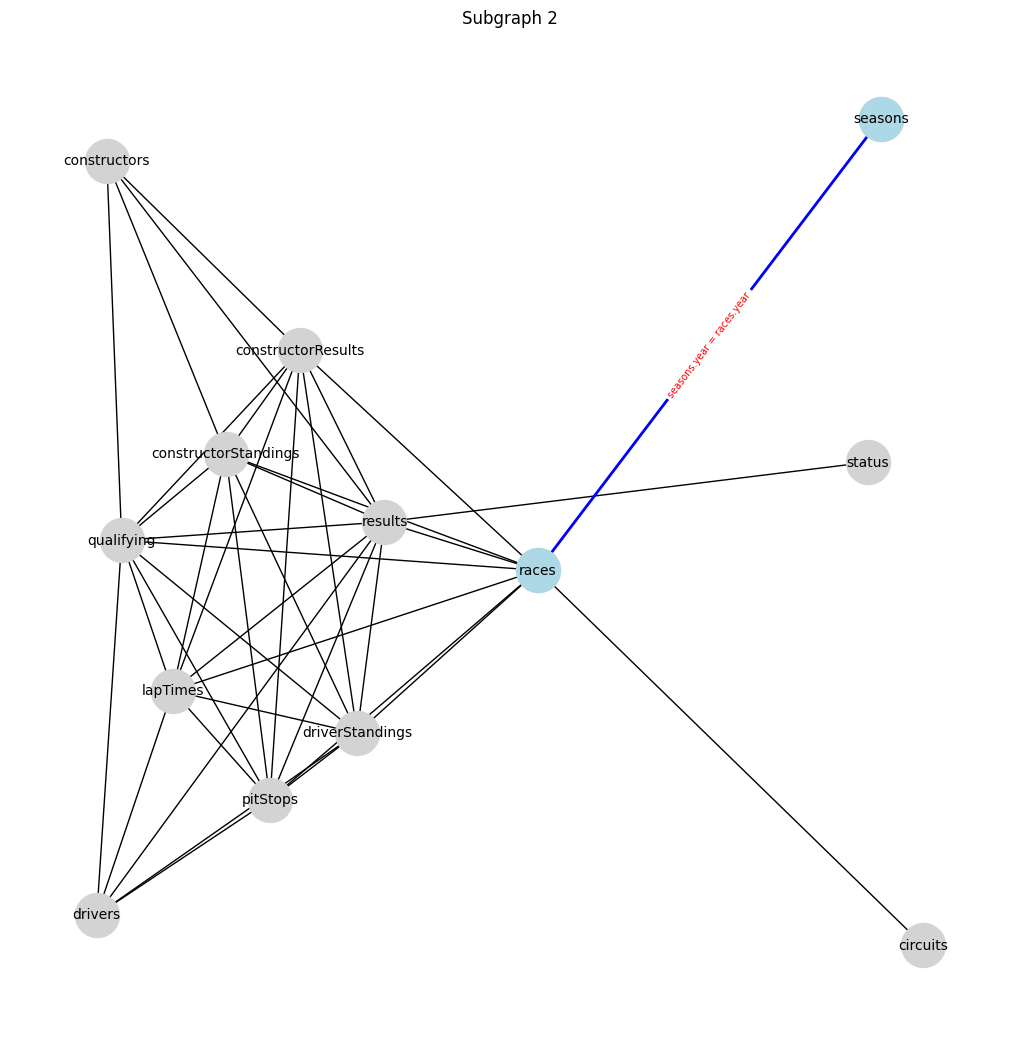

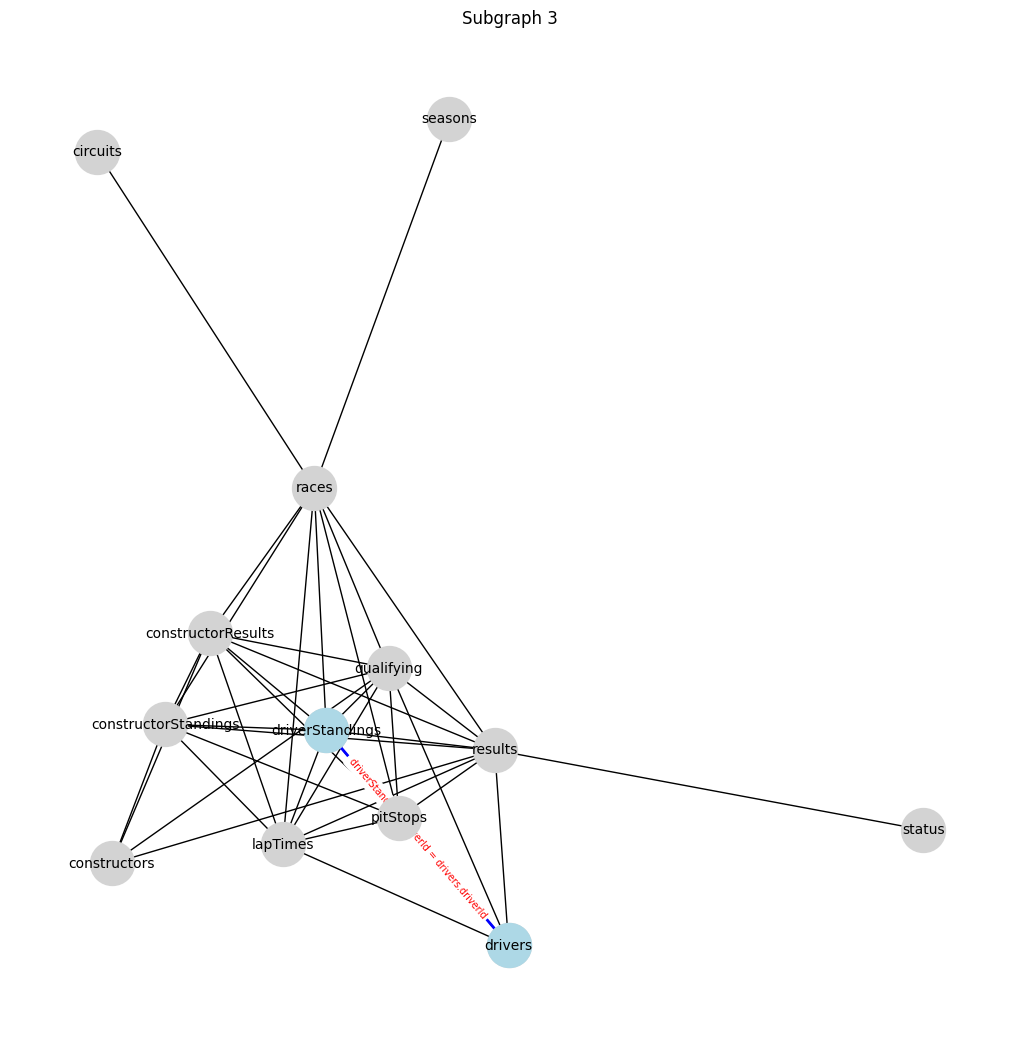

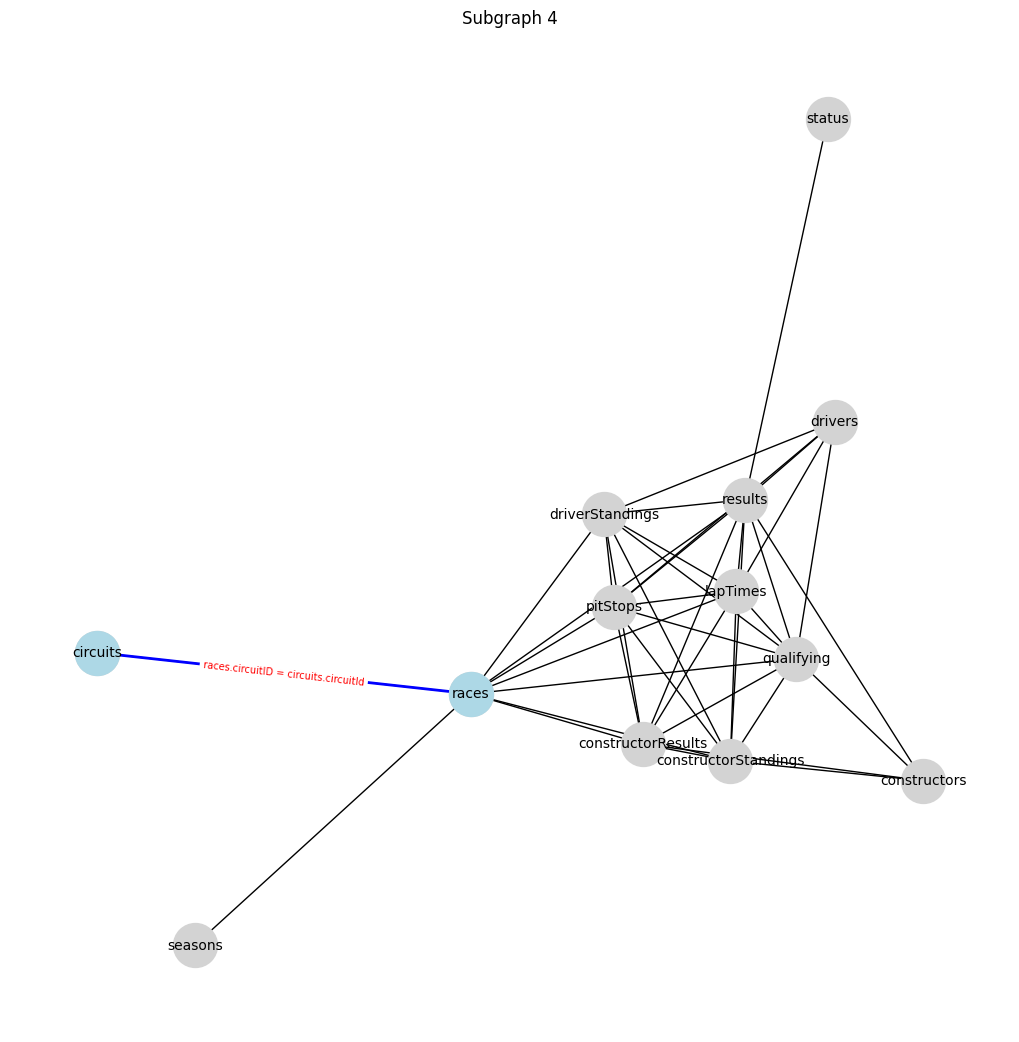

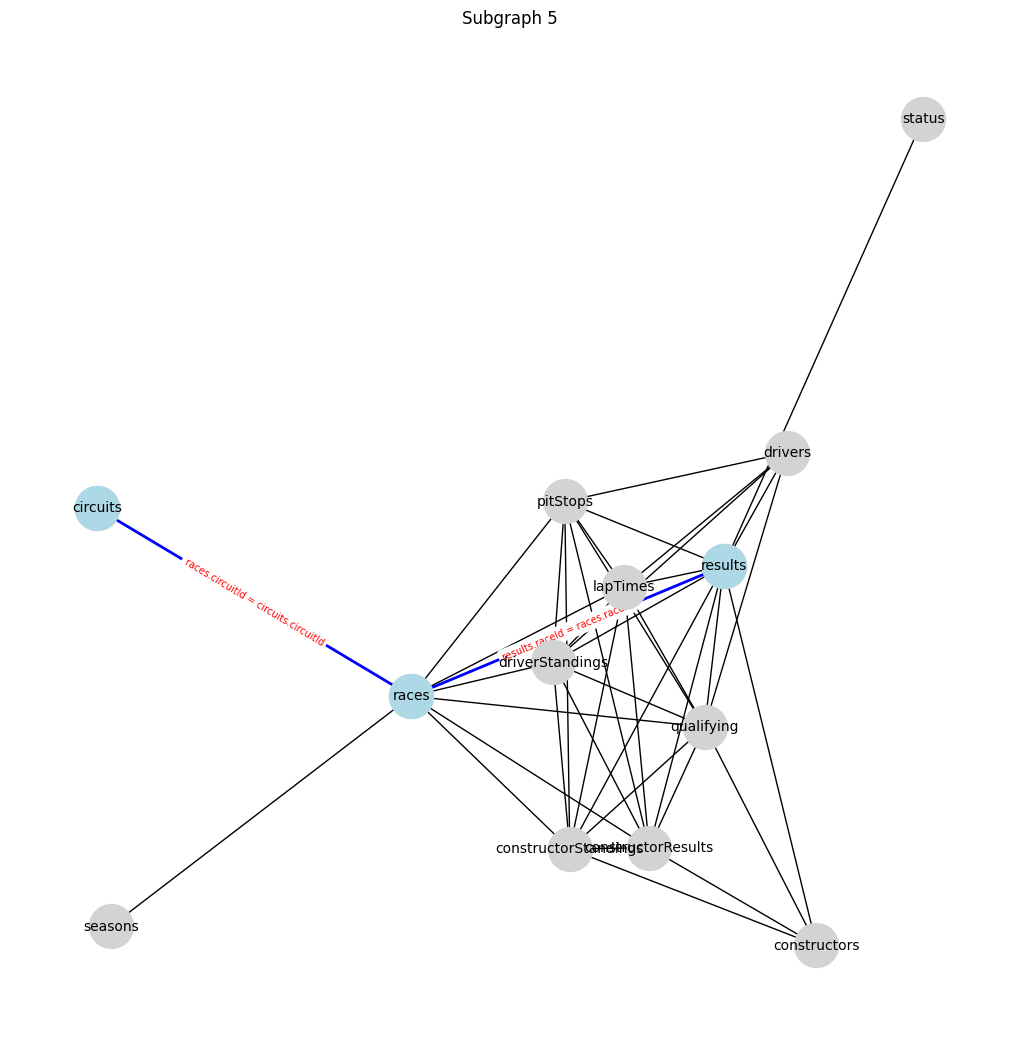

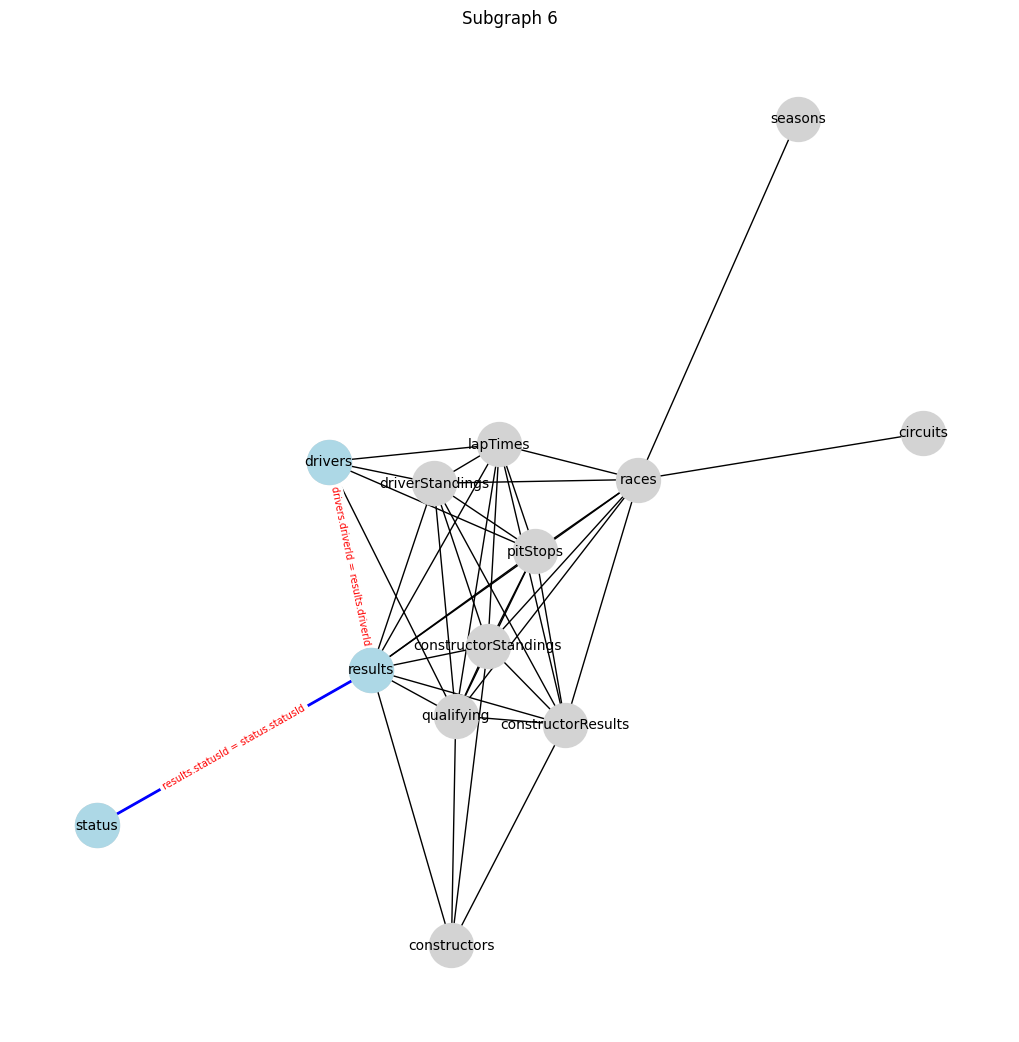

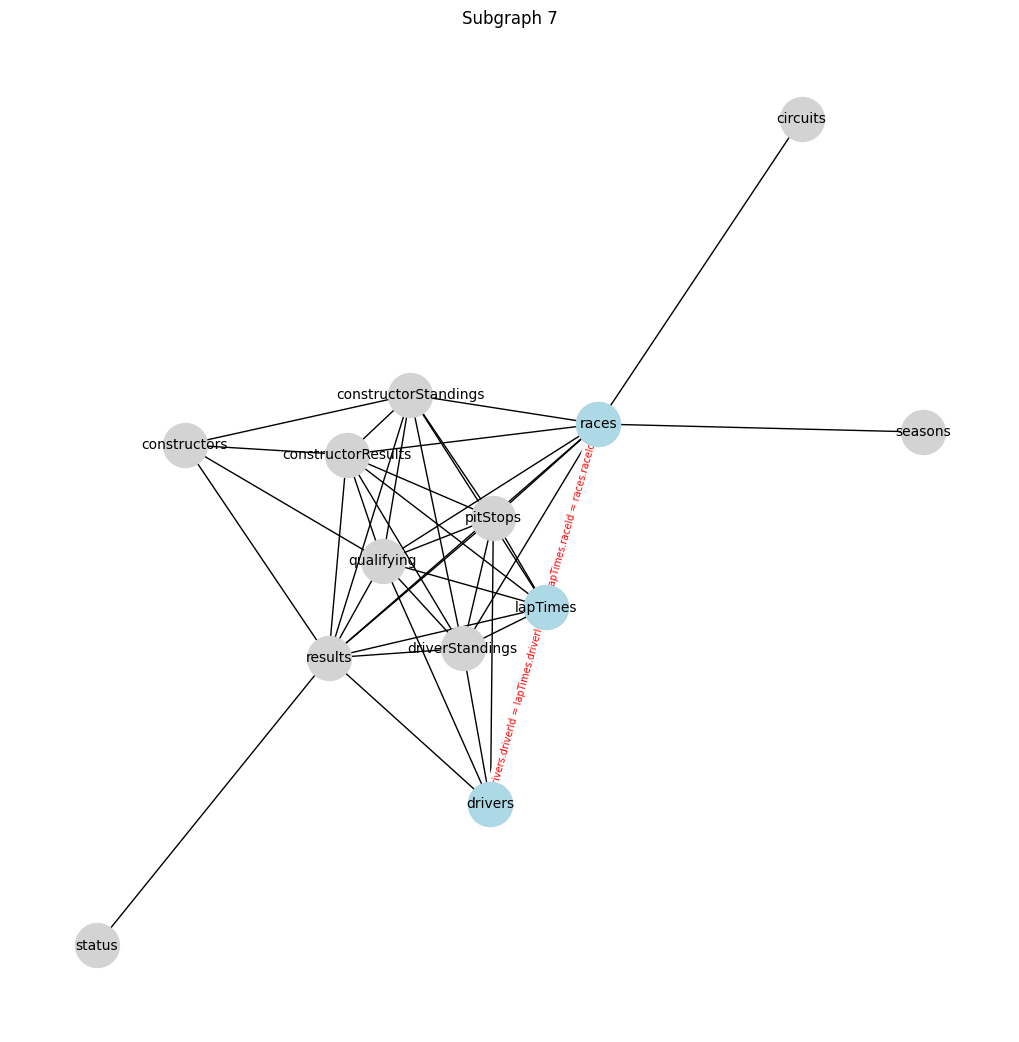

Displaying subgraphs for student_club...


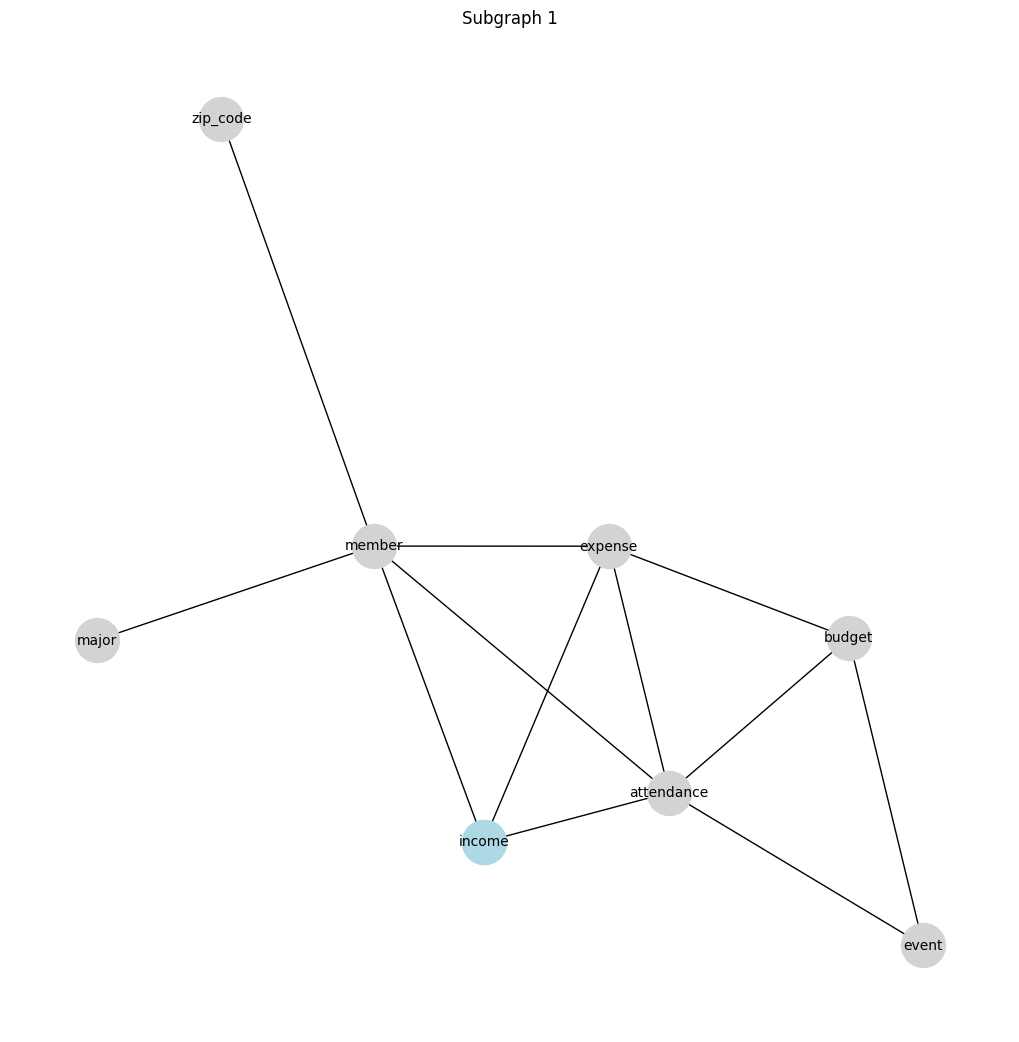

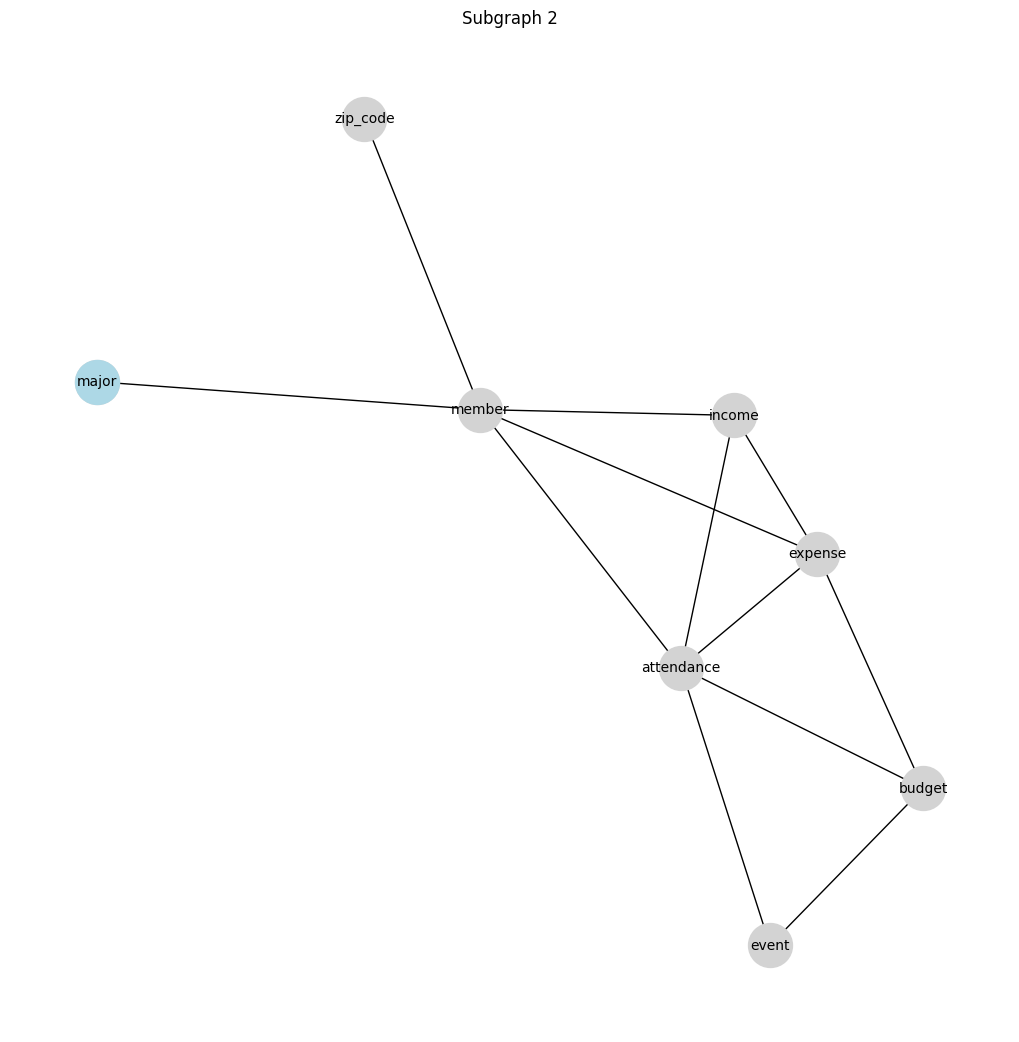

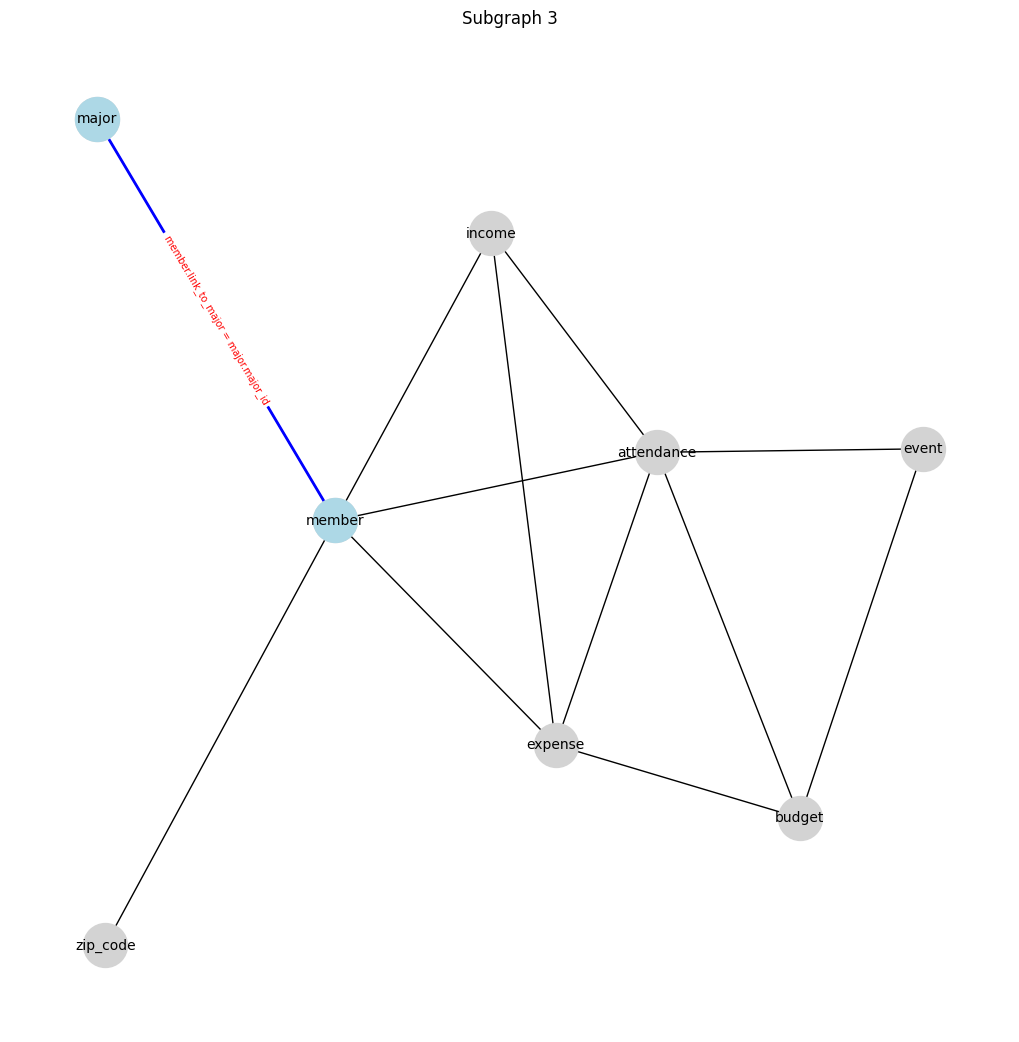

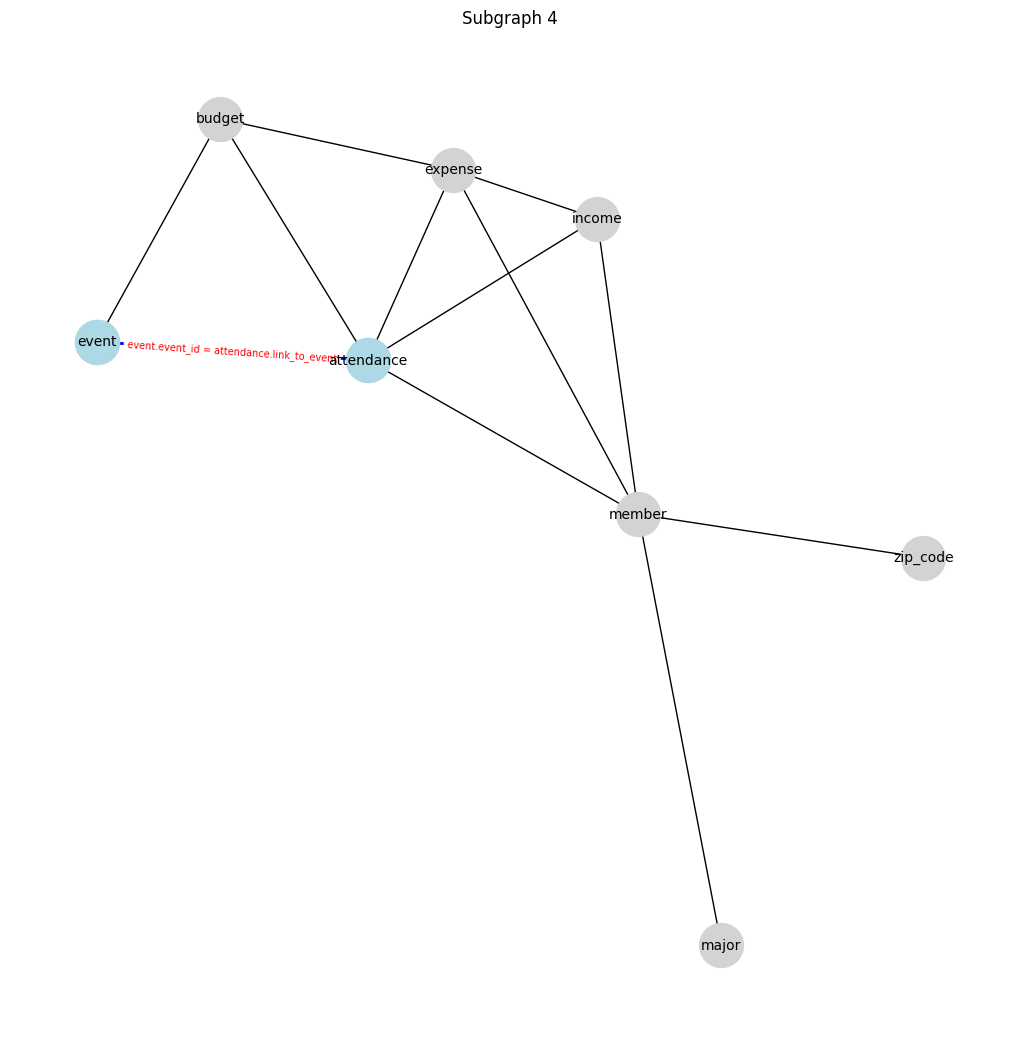

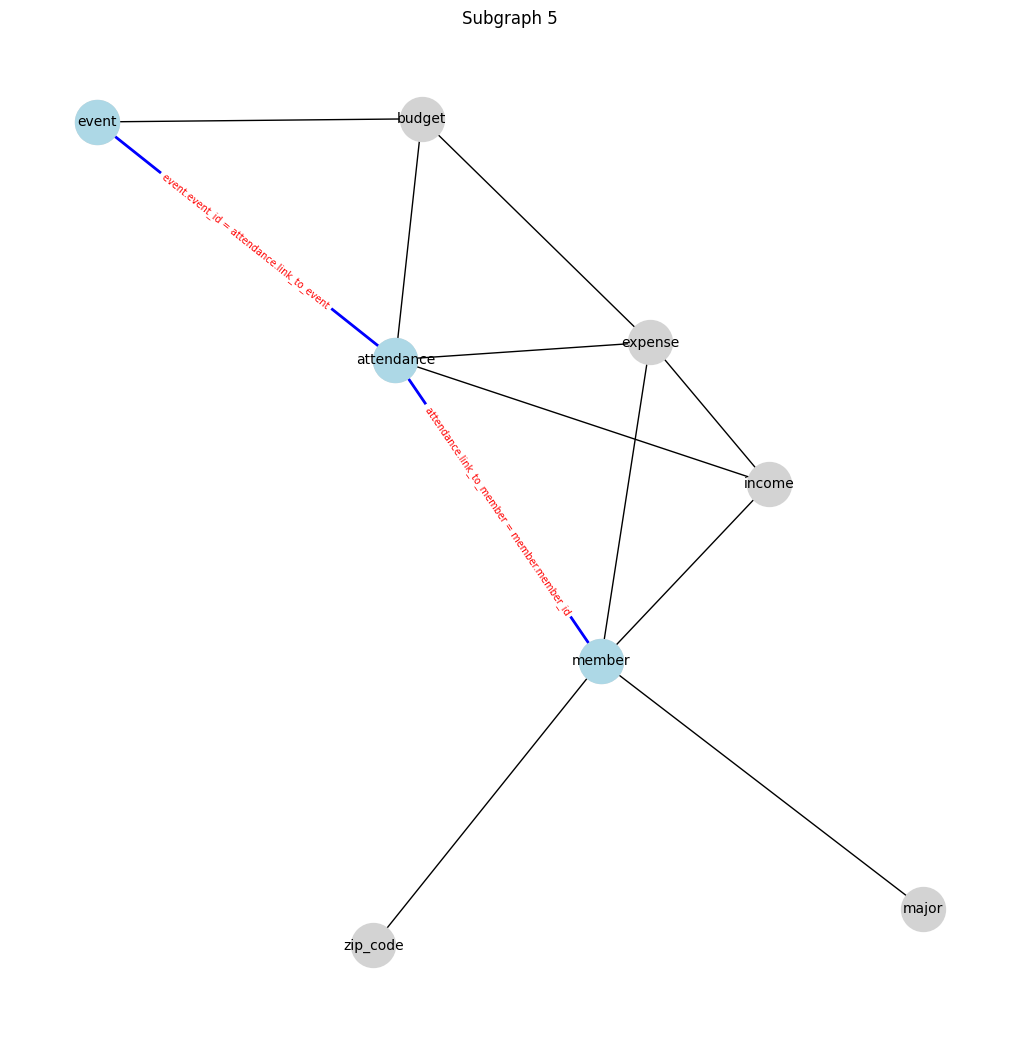

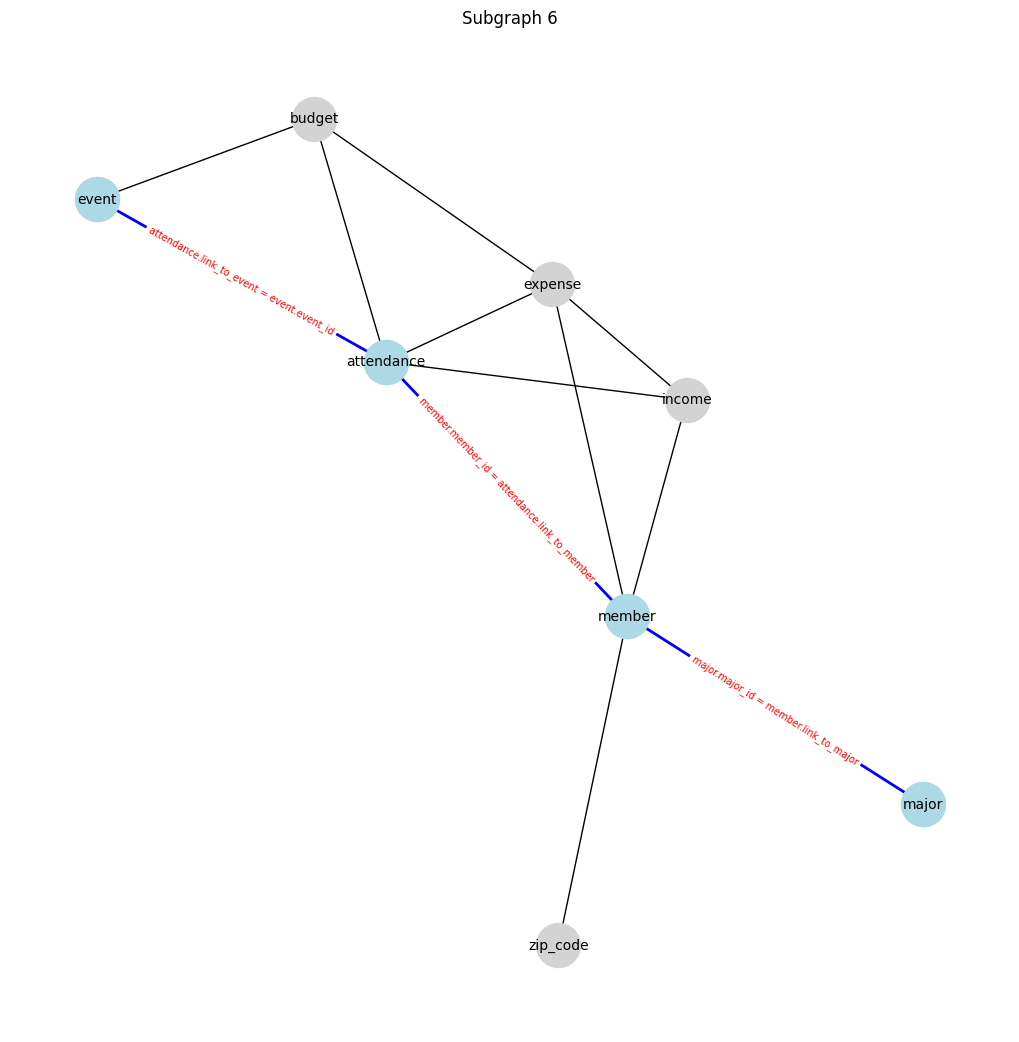

Displaying subgraphs for superhero...


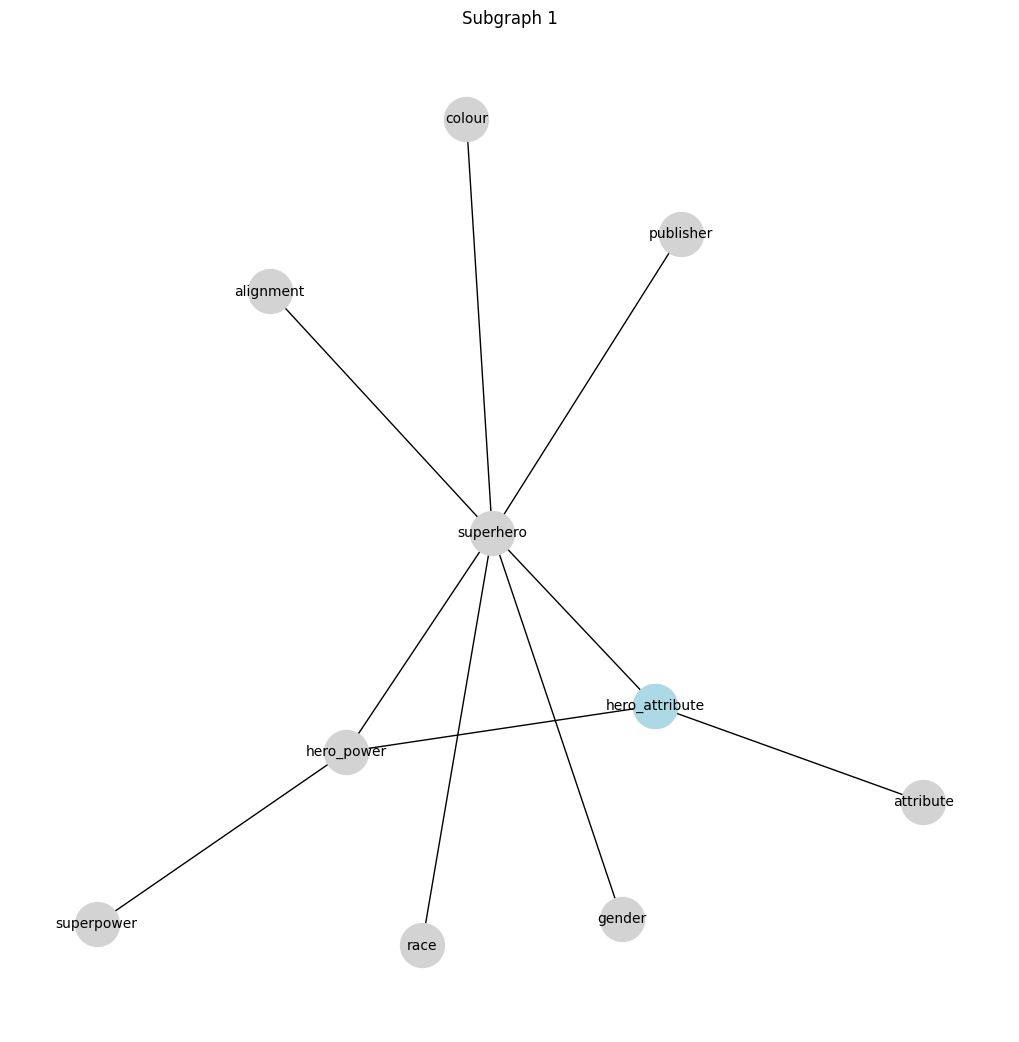

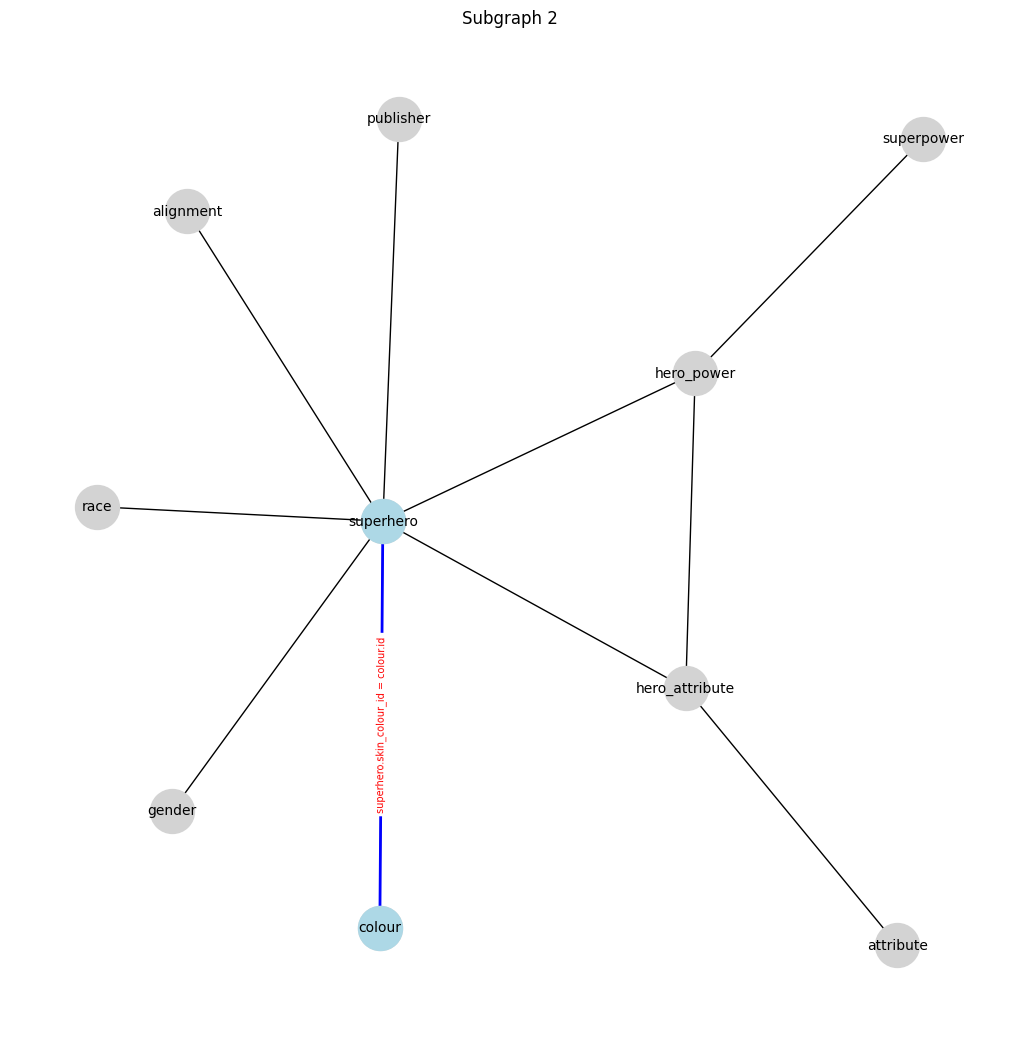

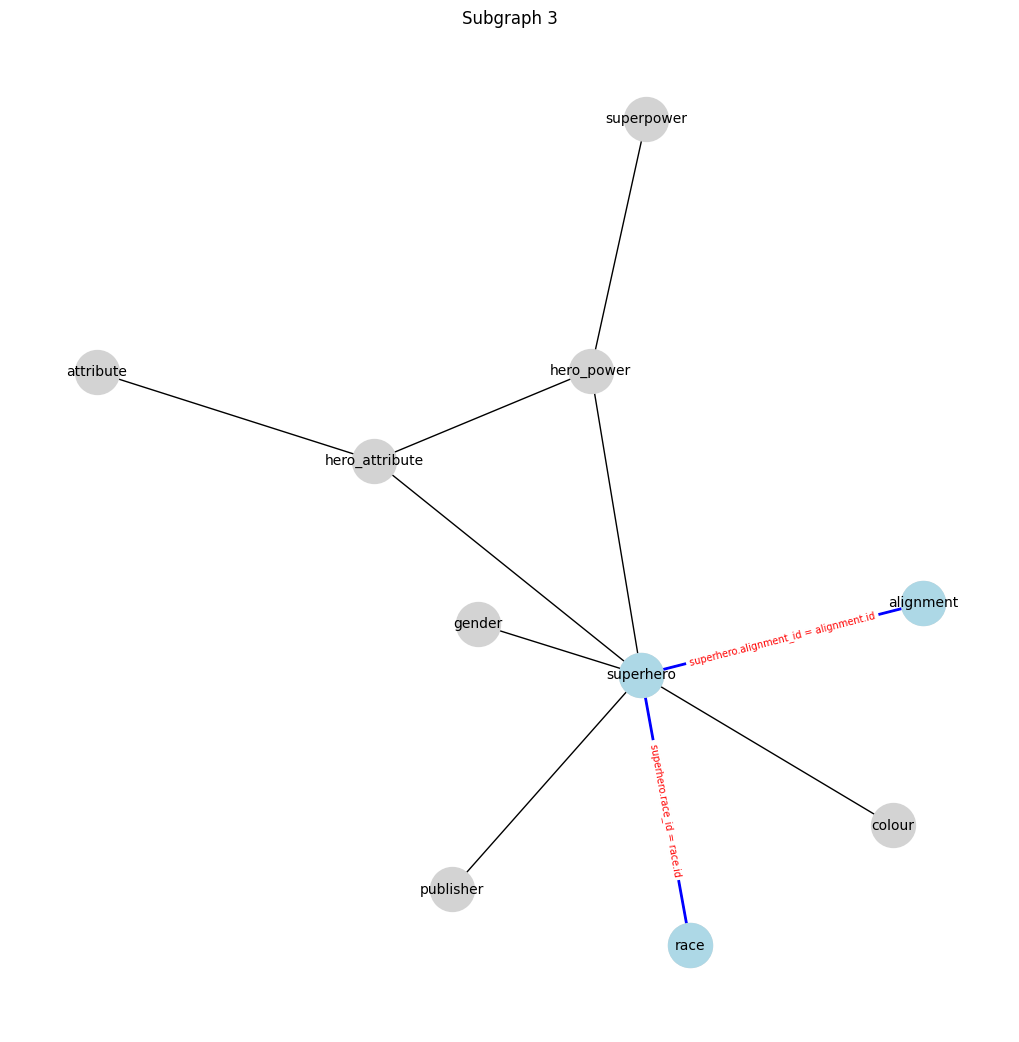

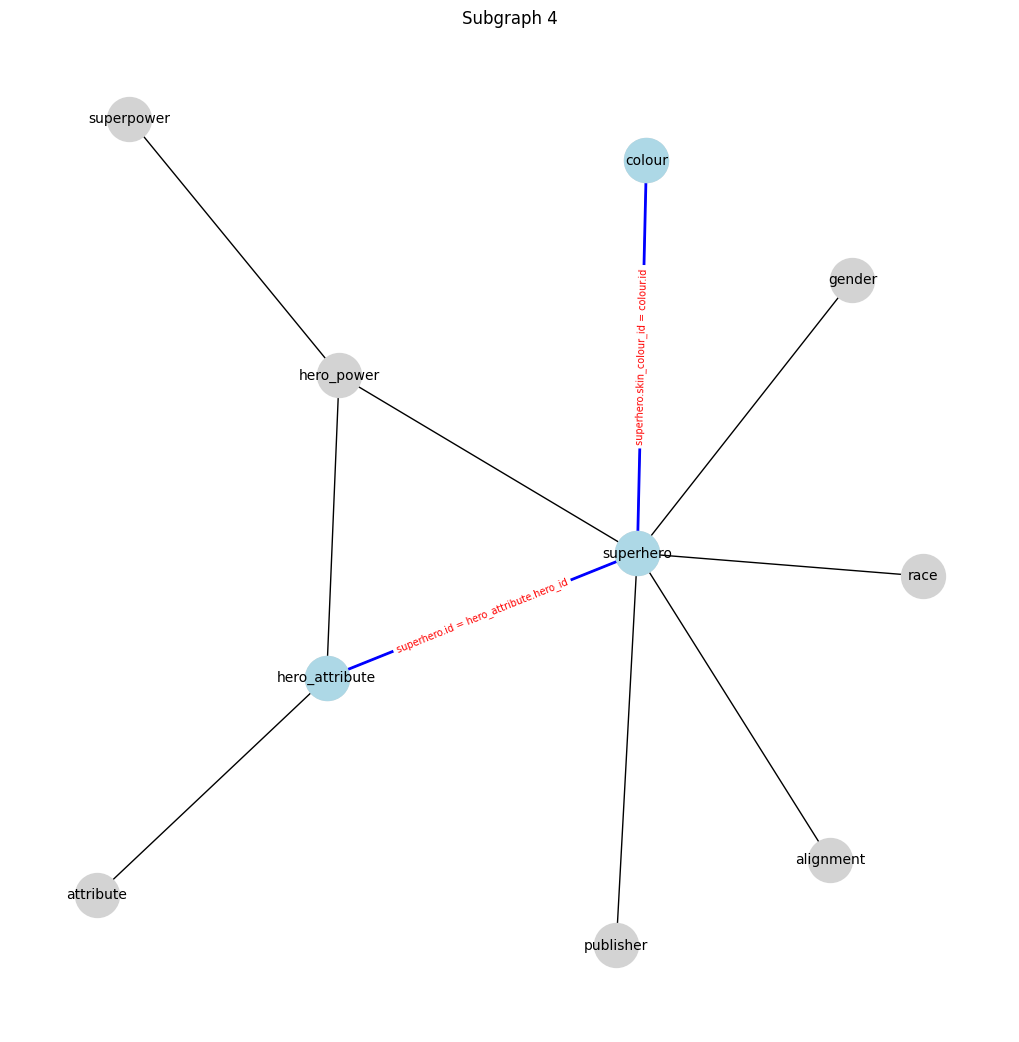

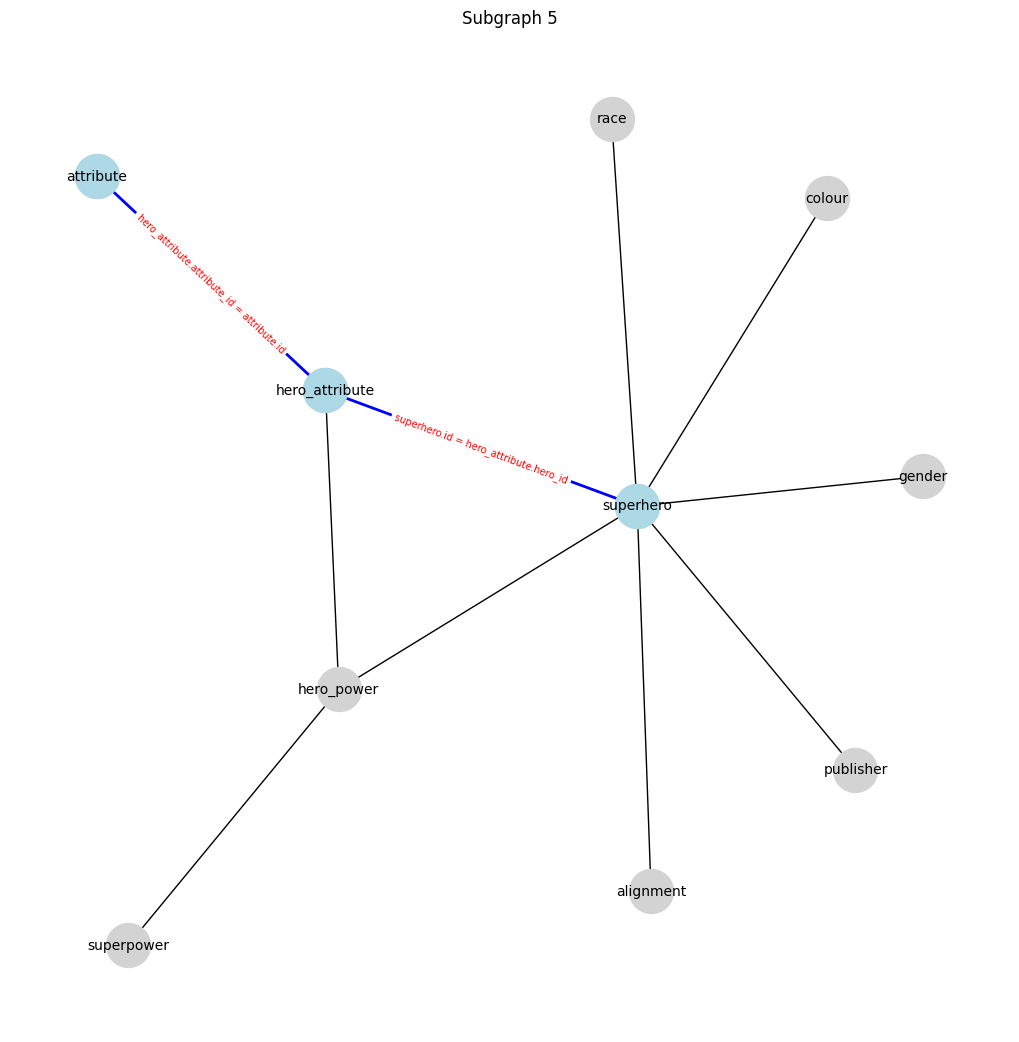

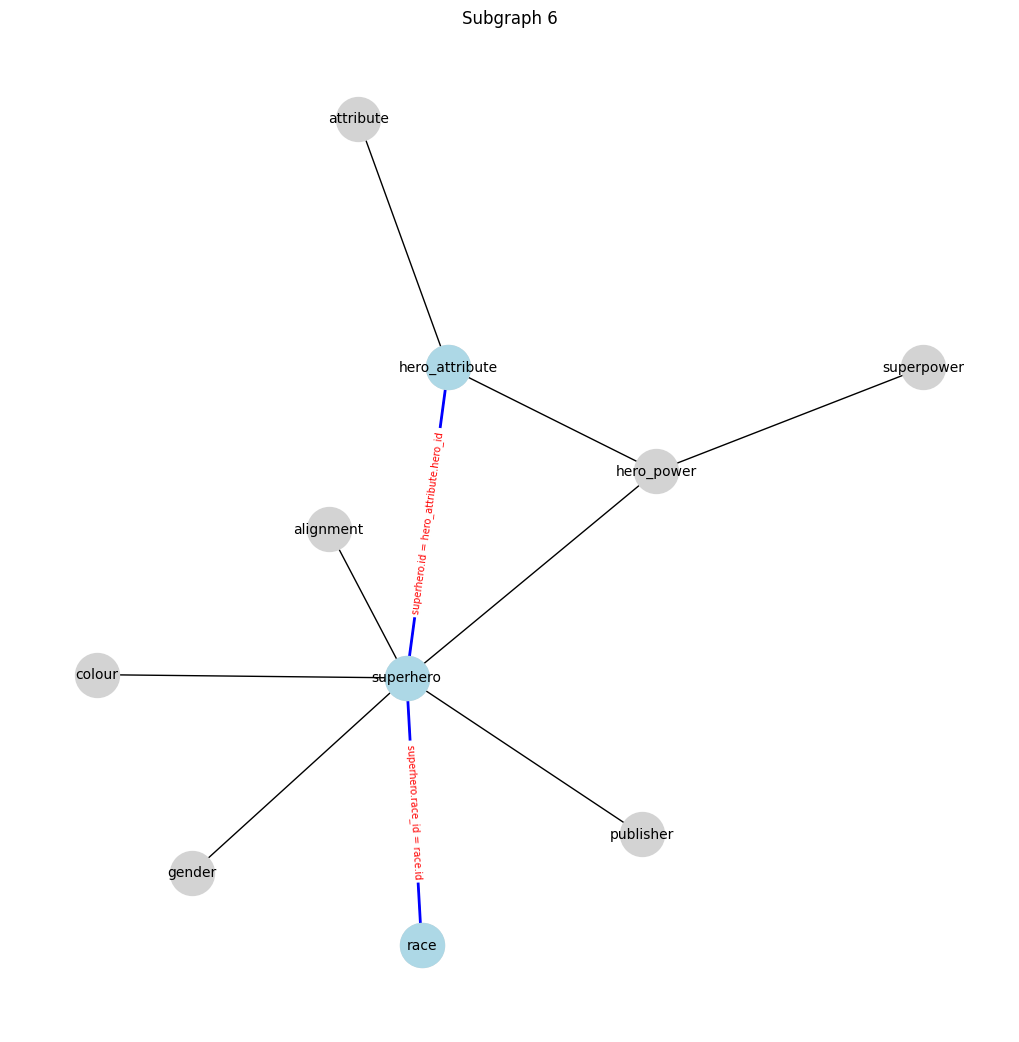

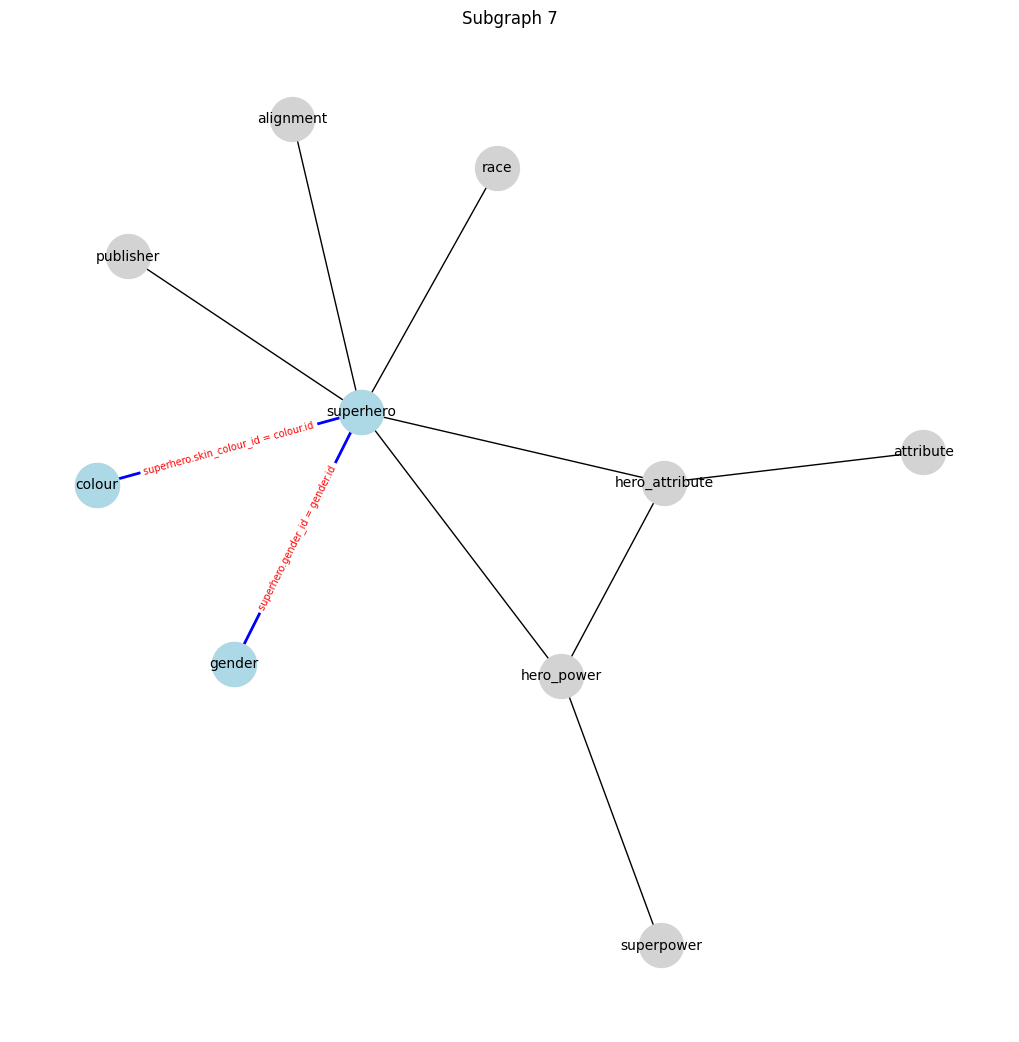

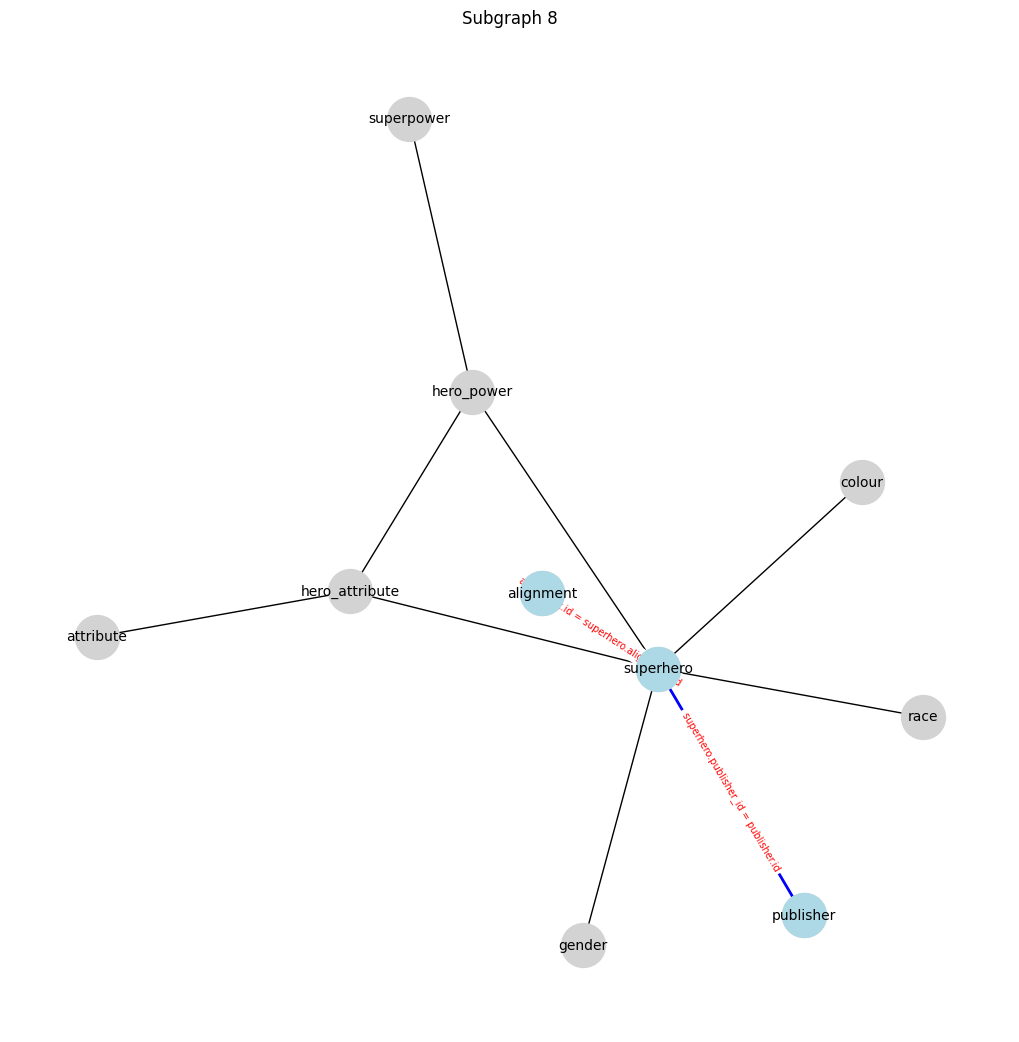

Displaying subgraphs for thrombosis_prediction...


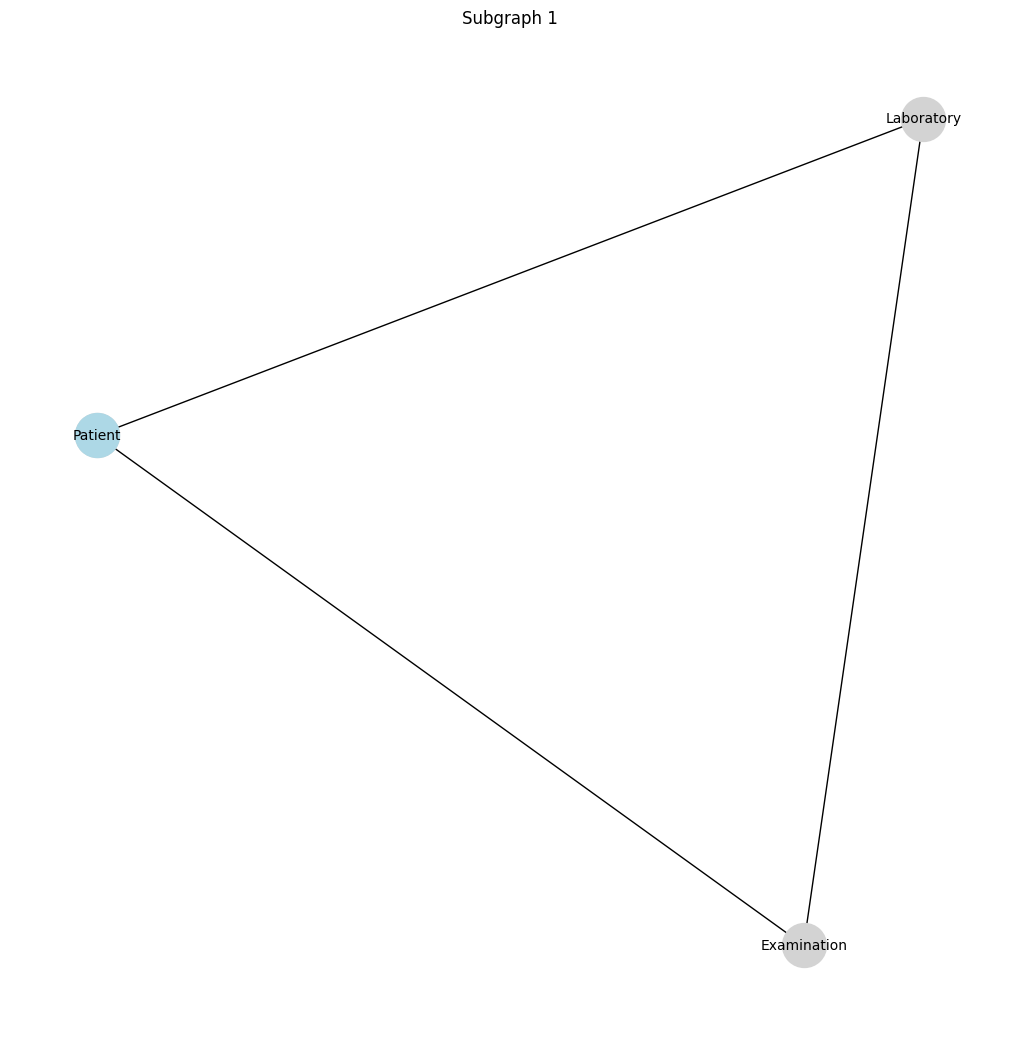

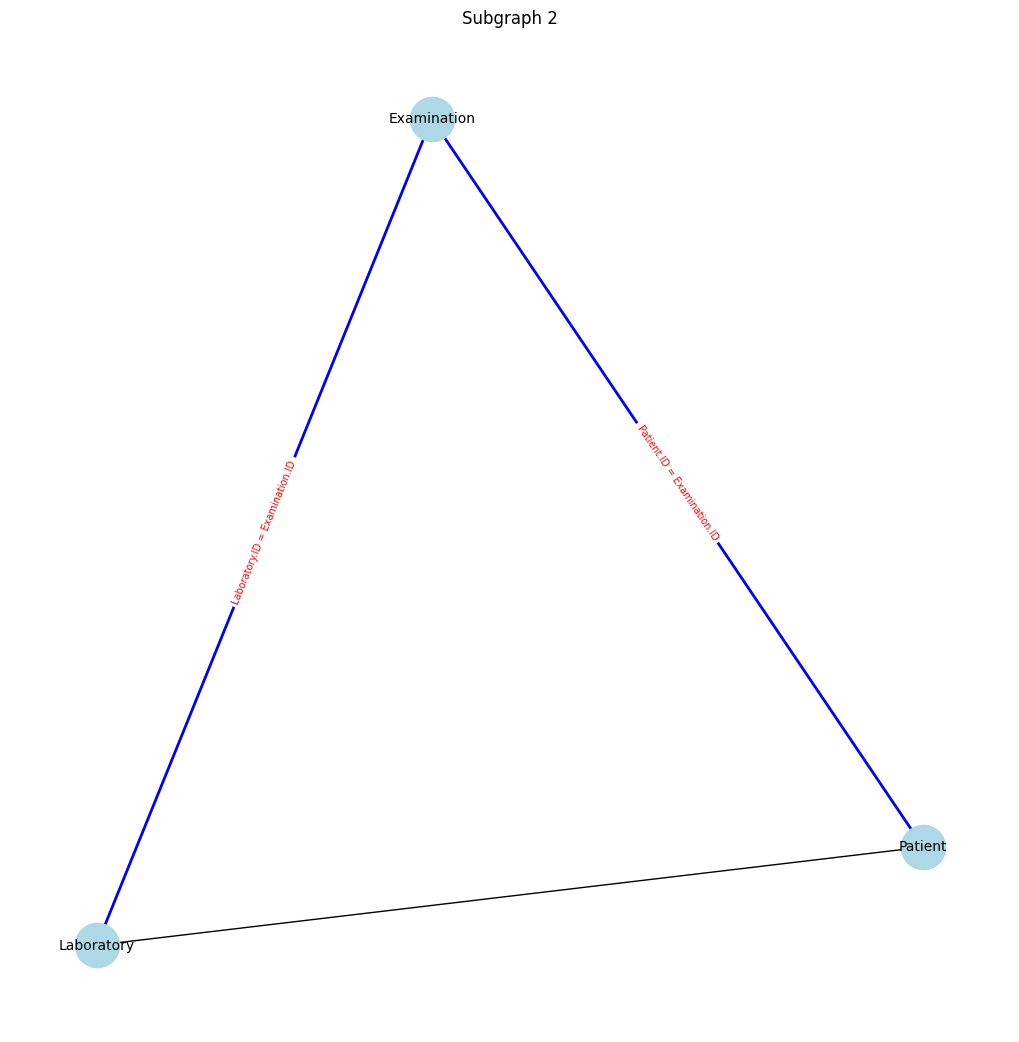

Displaying subgraphs for toxicology...


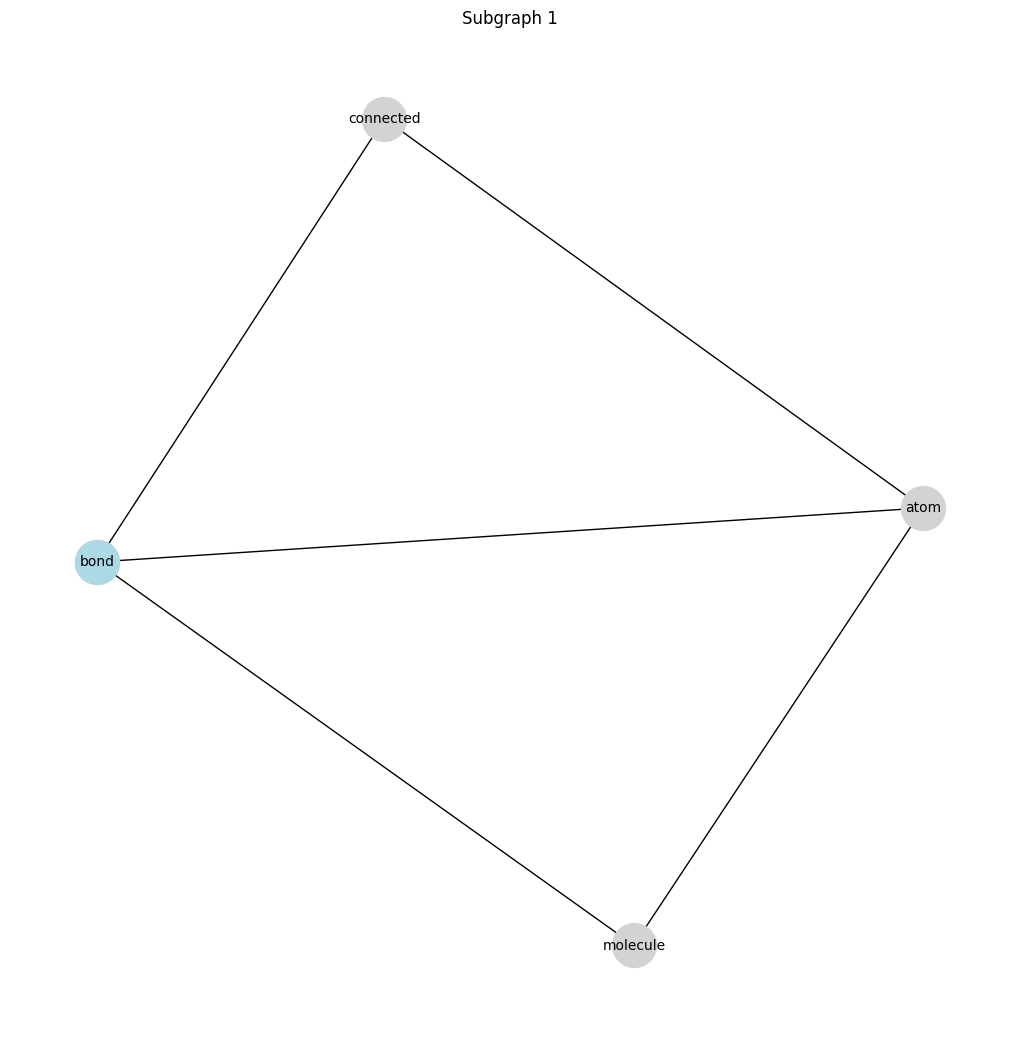

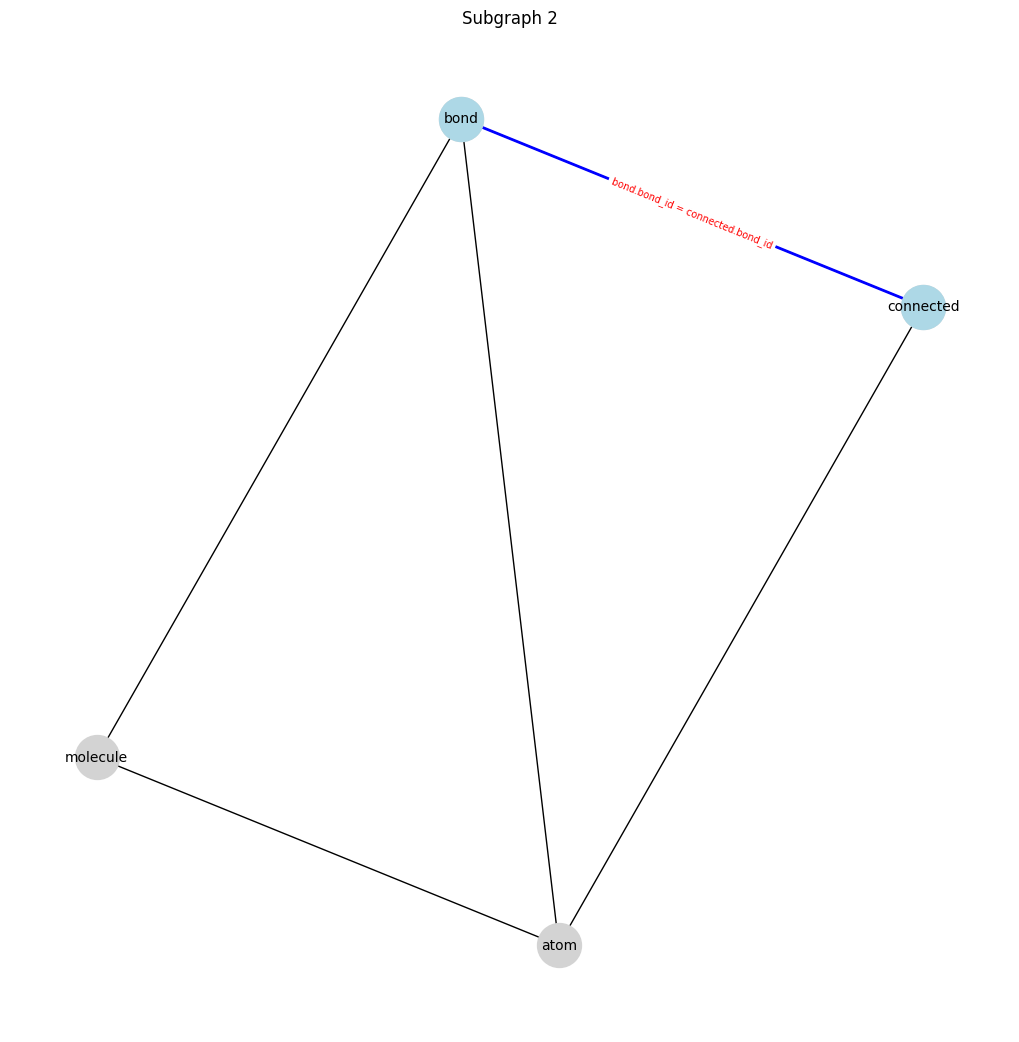

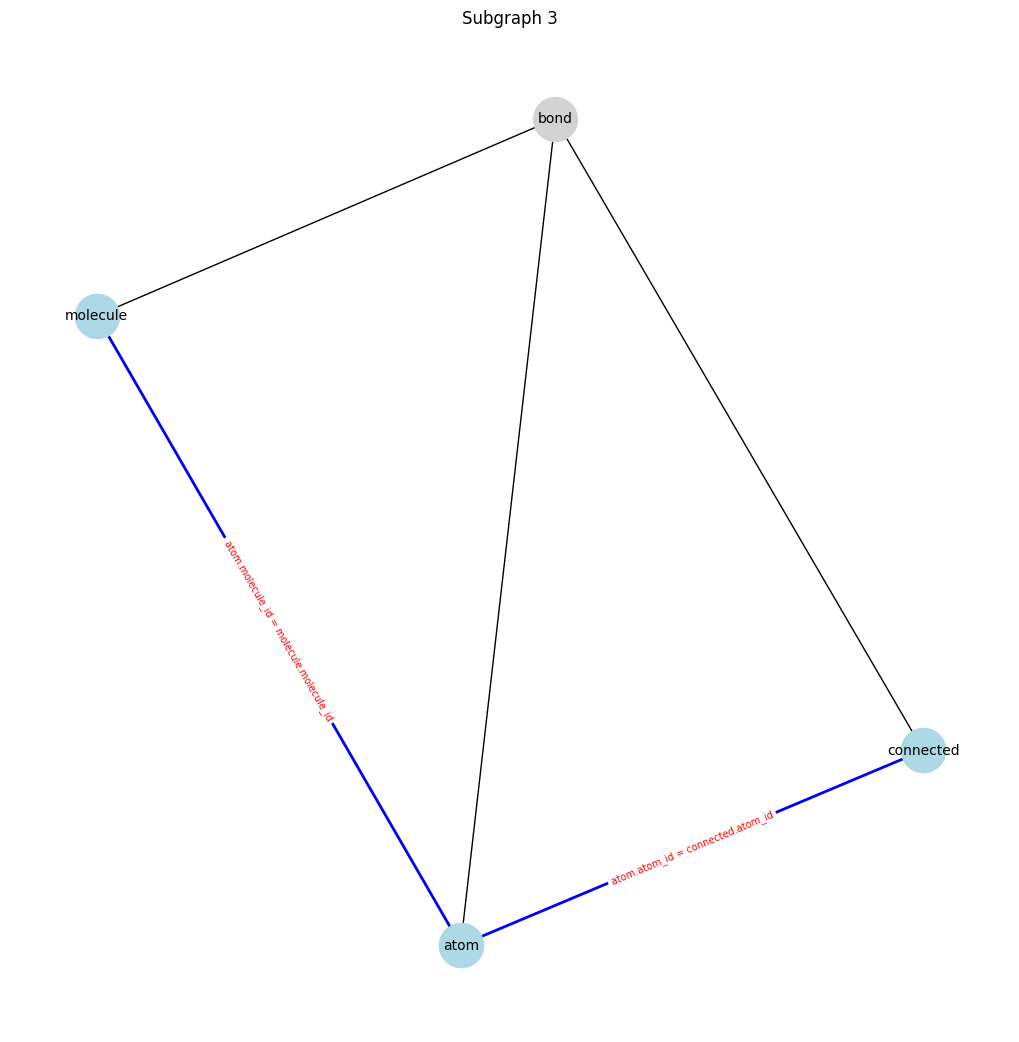

In [3]:
# Display all subgraphs
for db_id, subgraphs in database_subgraphs.items():
    print(f"Displaying subgraphs for {db_id}...")
    database_subgraphs[db_id] = sorted(subgraphs, key=lambda x: x.number_of_nodes())  # Sort by number of nodes

    # Load the schema (main graph) from the pickle file
    schema_path = f'../../../../data/graph_data/bird_graphs/pickles/{db_id}_graph.pkl'
    with open(schema_path, 'rb') as f:
        schema = pickle.load(f) 

    for i, subgraph in enumerate(database_subgraphs[db_id], start=1):
        display_subgraph(
                schema=schema,
                subgraph=subgraph,
                subgraph_number=i,
        )



## 2. Identifying the candidate table to hide (the most central table to the query)

In [4]:
# Precompute schema centrality once, as it does not depend on the subgraphs
schema_centrality = nx.degree_centrality(schema)

all_subgraphs_with_candidates = {}

for db_id, subgraphs in database_subgraphs.items():
    subgraphs_with_candidates = []

    for subgraph in subgraphs:
        if subgraph.number_of_nodes() < 3:
            continue

        # Compute betweenness centrality for the current subgraph
        betweenness_centrality = nx.betweenness_centrality(subgraph)
        max_betweenness = max(betweenness_centrality.values())

        # Find nodes with the maximum betweenness centrality
        candidates = [(node, score) for node, score in betweenness_centrality.items() if score == max_betweenness]

        # Select the most central candidate table
        if len(candidates) == 1:
            selected_table = candidates[0][0]
        else:
            selected_table = max(candidates, key=lambda x: schema_centrality.get(x[0], 0))[0]

        subgraphs_with_candidates.append({"subgraph": subgraph, "candidate_table": selected_table})

    all_subgraphs_with_candidates[db_id] = subgraphs_with_candidates

print(all_subgraphs_with_candidates.keys())

dict_keys(['california_schools', 'card_games', 'codebase_community', 'debit_card_specializing', 'european_football_2', 'financial', 'formula_1', 'student_club', 'superhero', 'thrombosis_prediction', 'toxicology'])


Displaying subgraphs for california_schools...
Displaying subgraphs for card_games...
Displaying subgraphs for codebase_community...
the table to be hidden:  posts


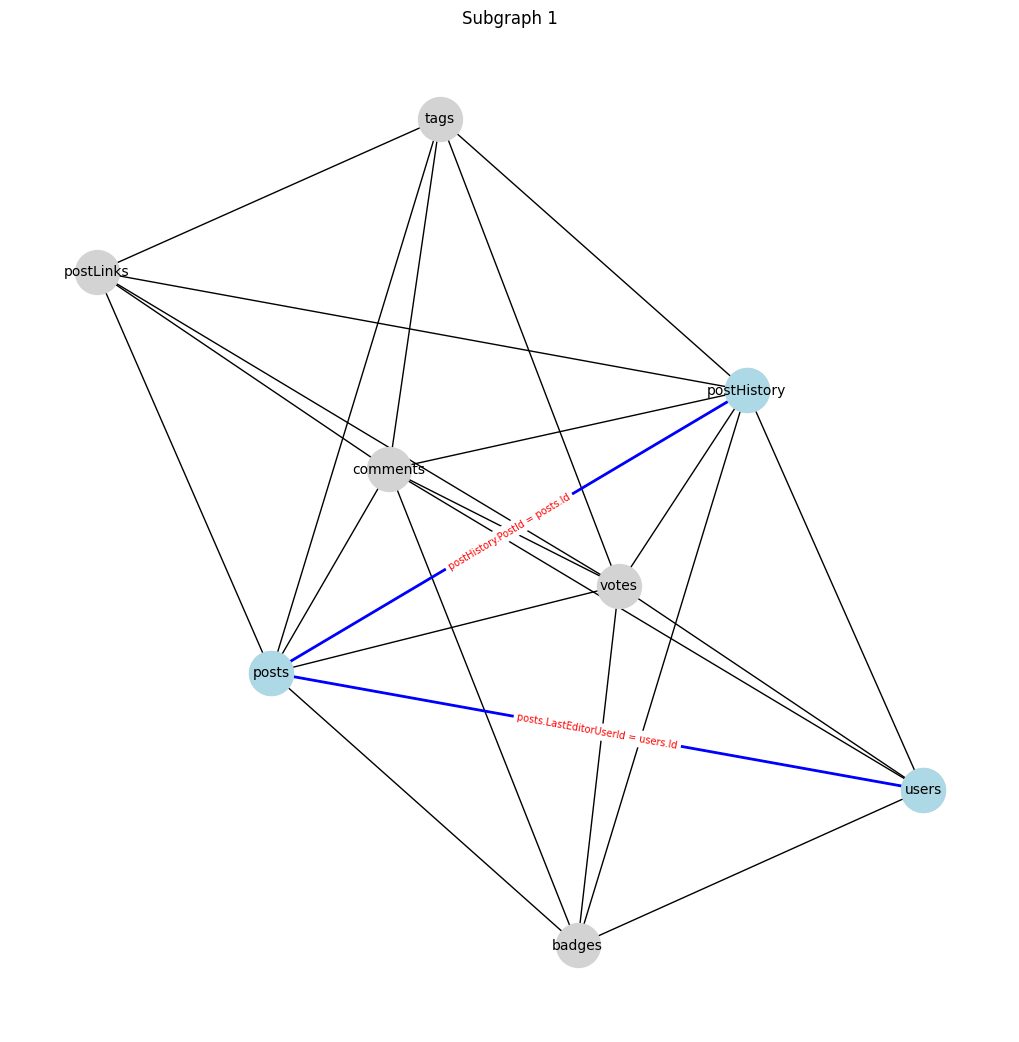

the table to be hidden:  postHistory


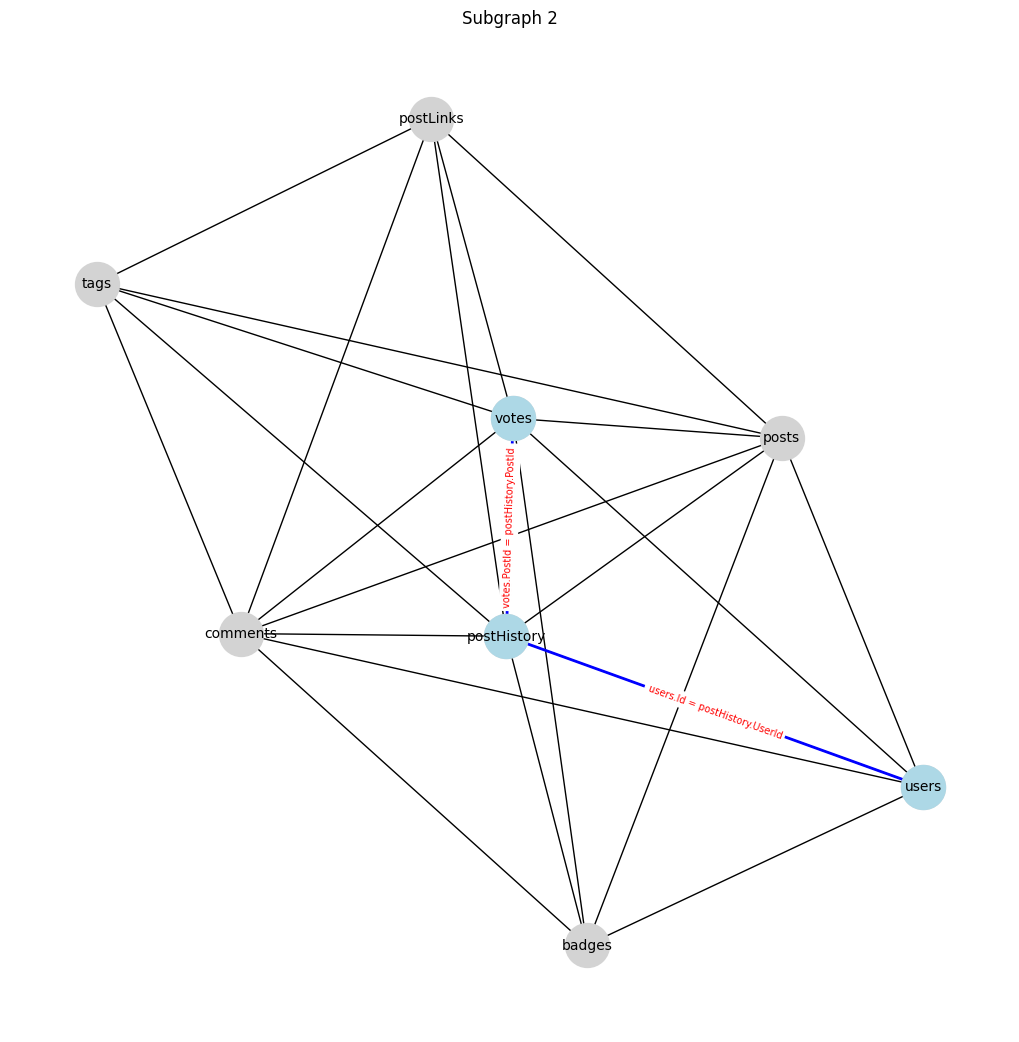

the table to be hidden:  posts


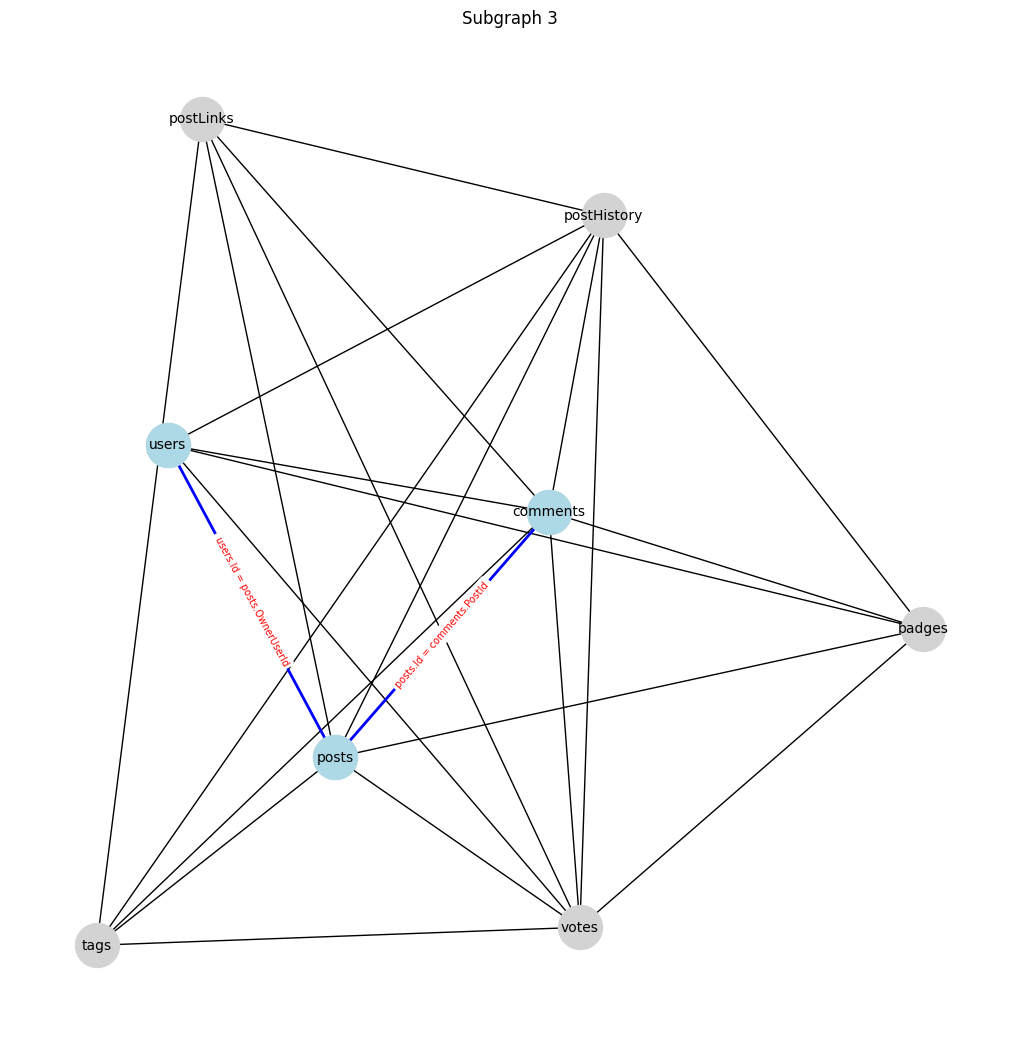

the table to be hidden:  votes


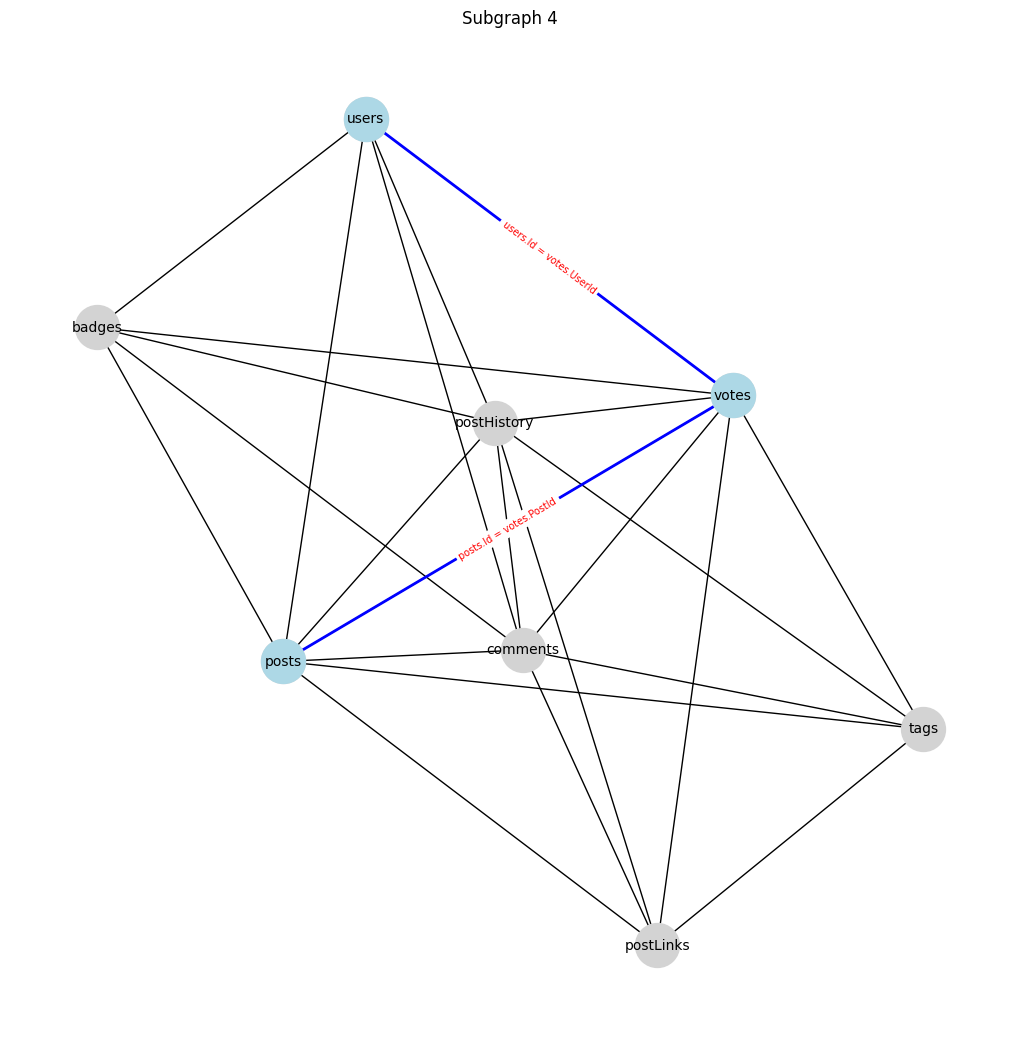

Displaying subgraphs for debit_card_specializing...
the table to be hidden:  transactions_1k


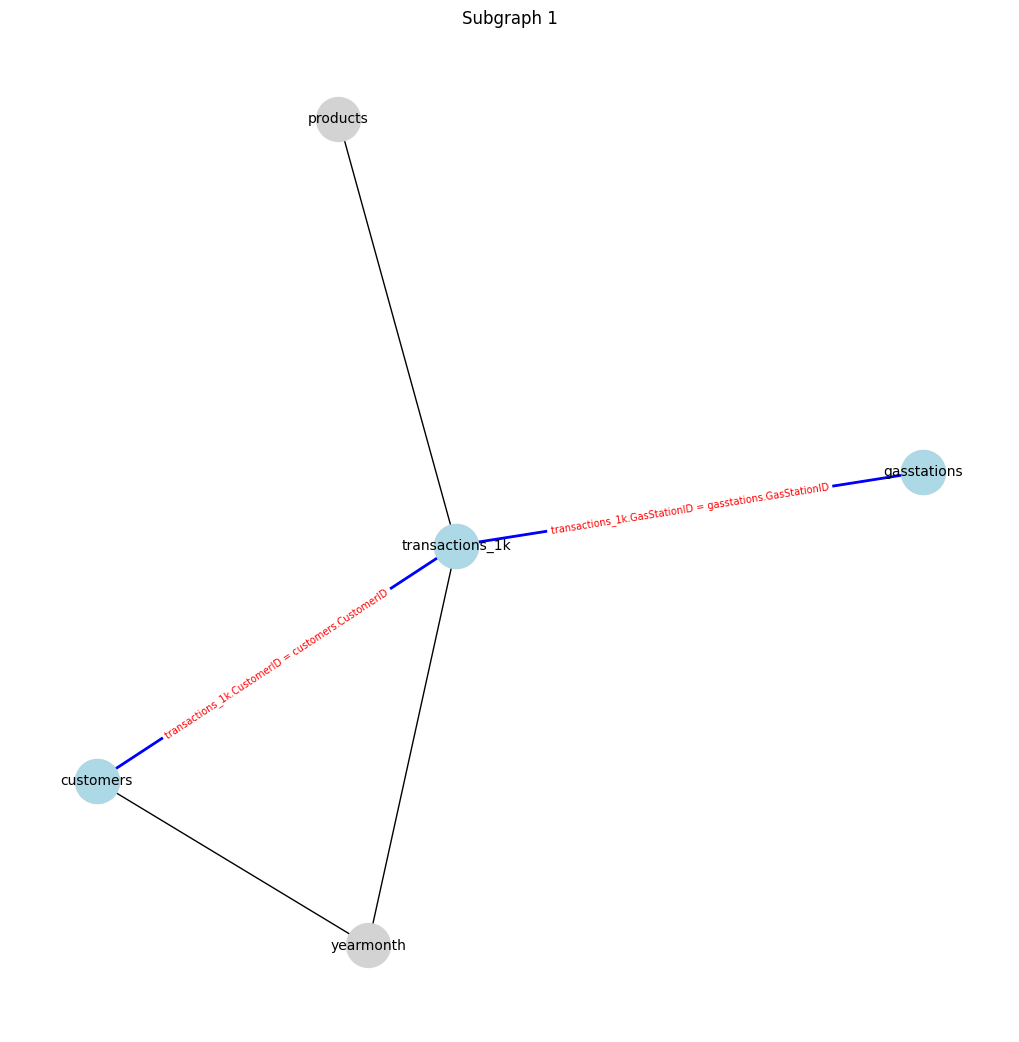

Displaying subgraphs for european_football_2...
the table to be hidden:  Match


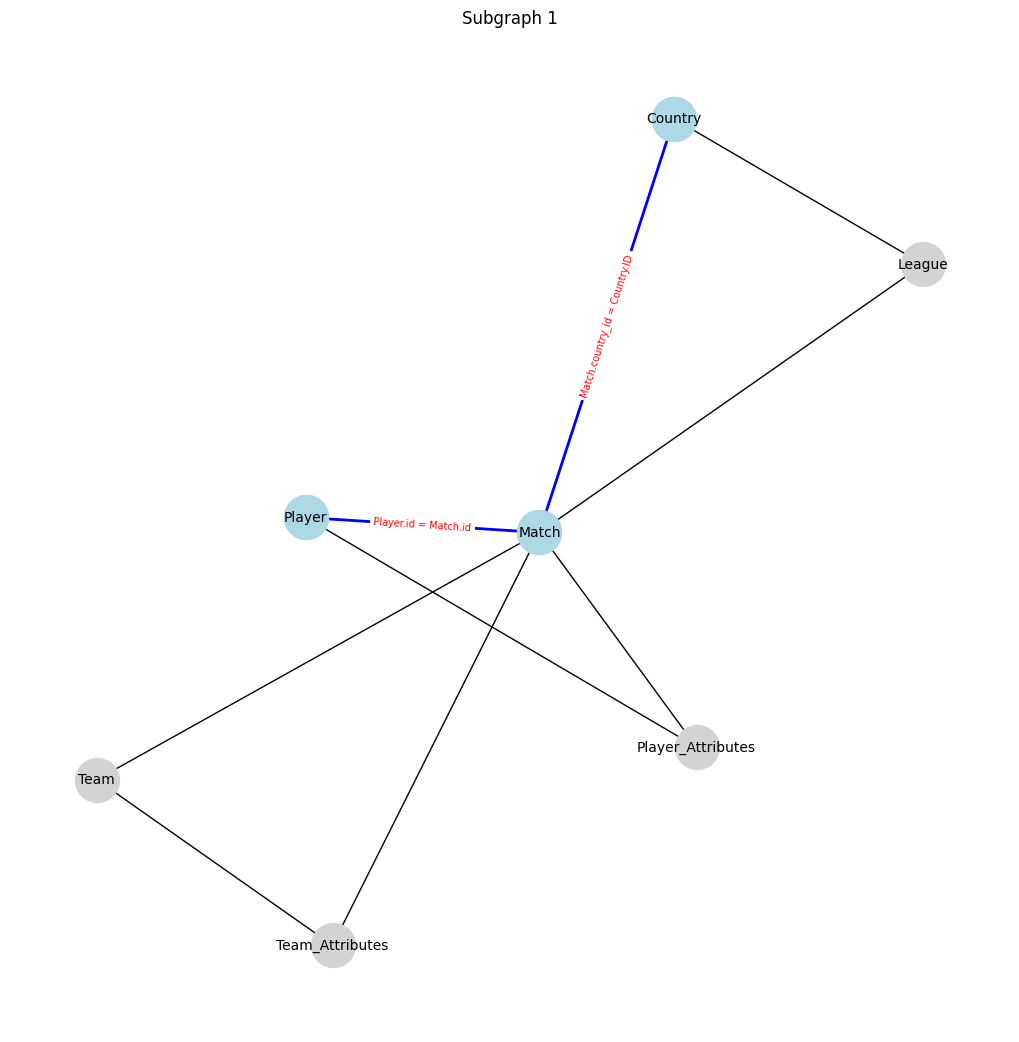

the table to be hidden:  Player


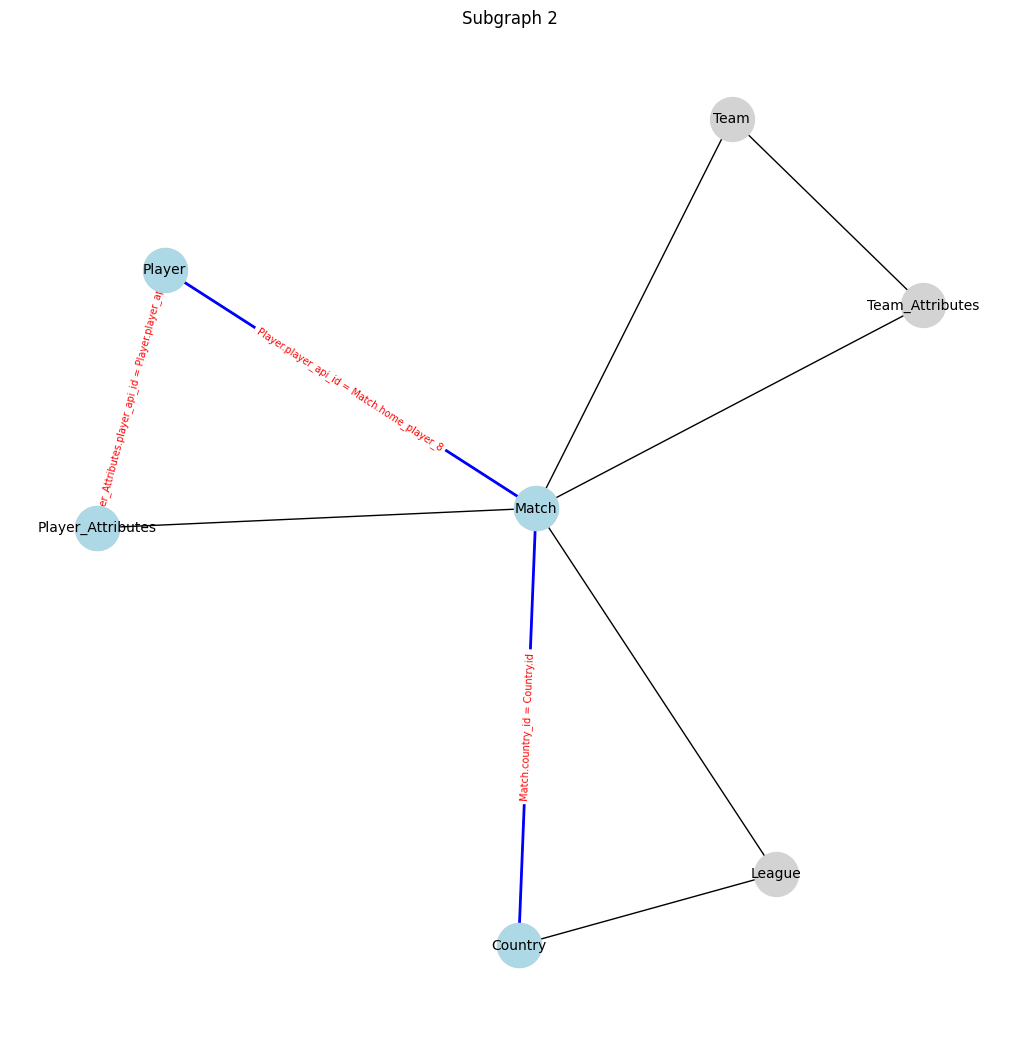

Displaying subgraphs for financial...
the table to be hidden:  account


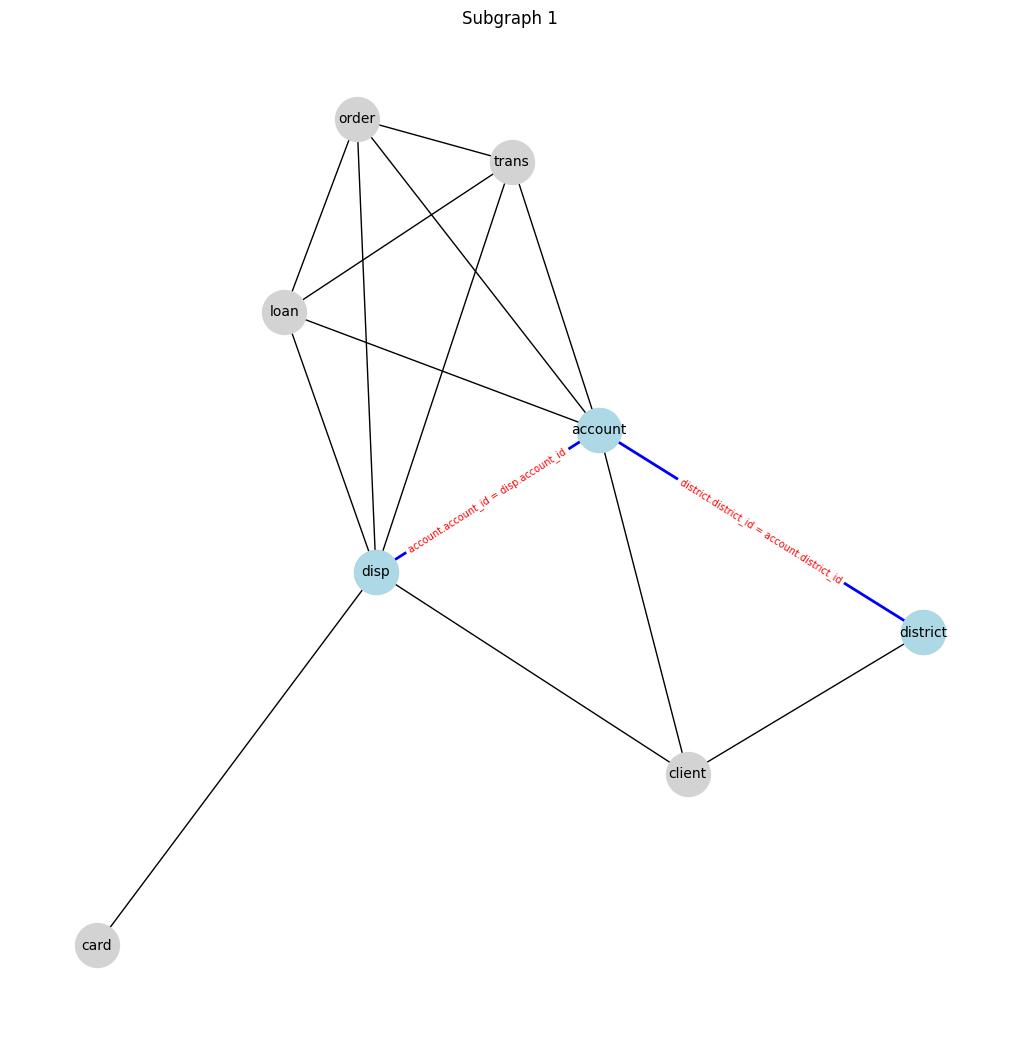

the table to be hidden:  account


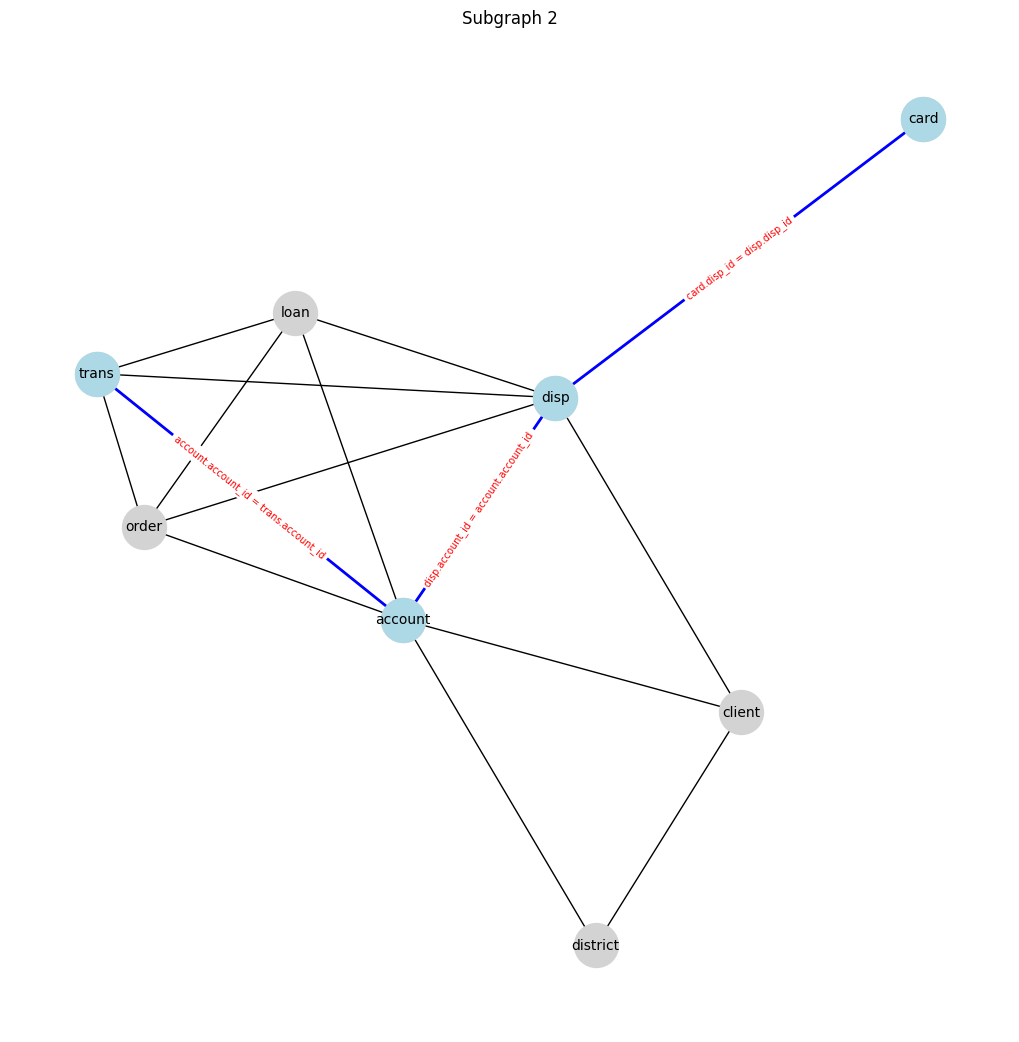

the table to be hidden:  disp


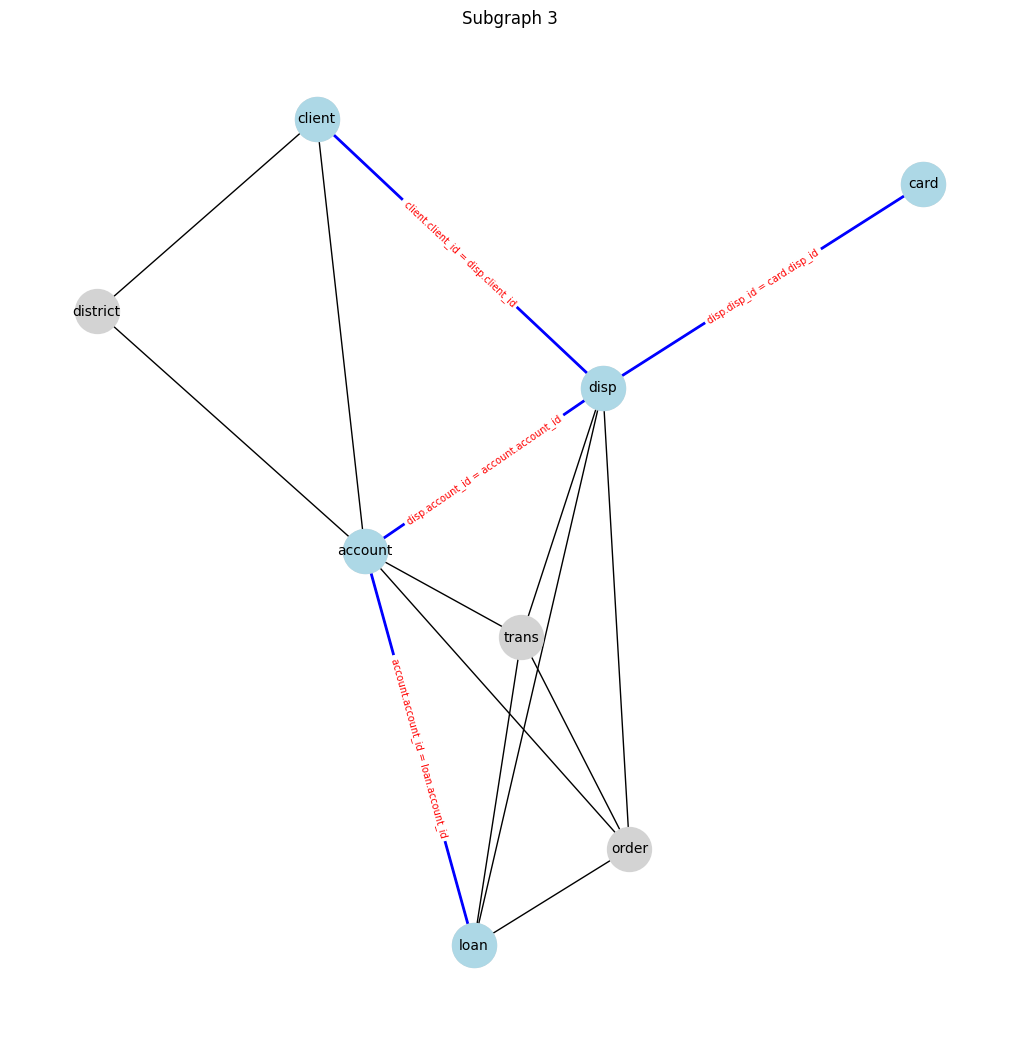

Displaying subgraphs for formula_1...
the table to be hidden:  races


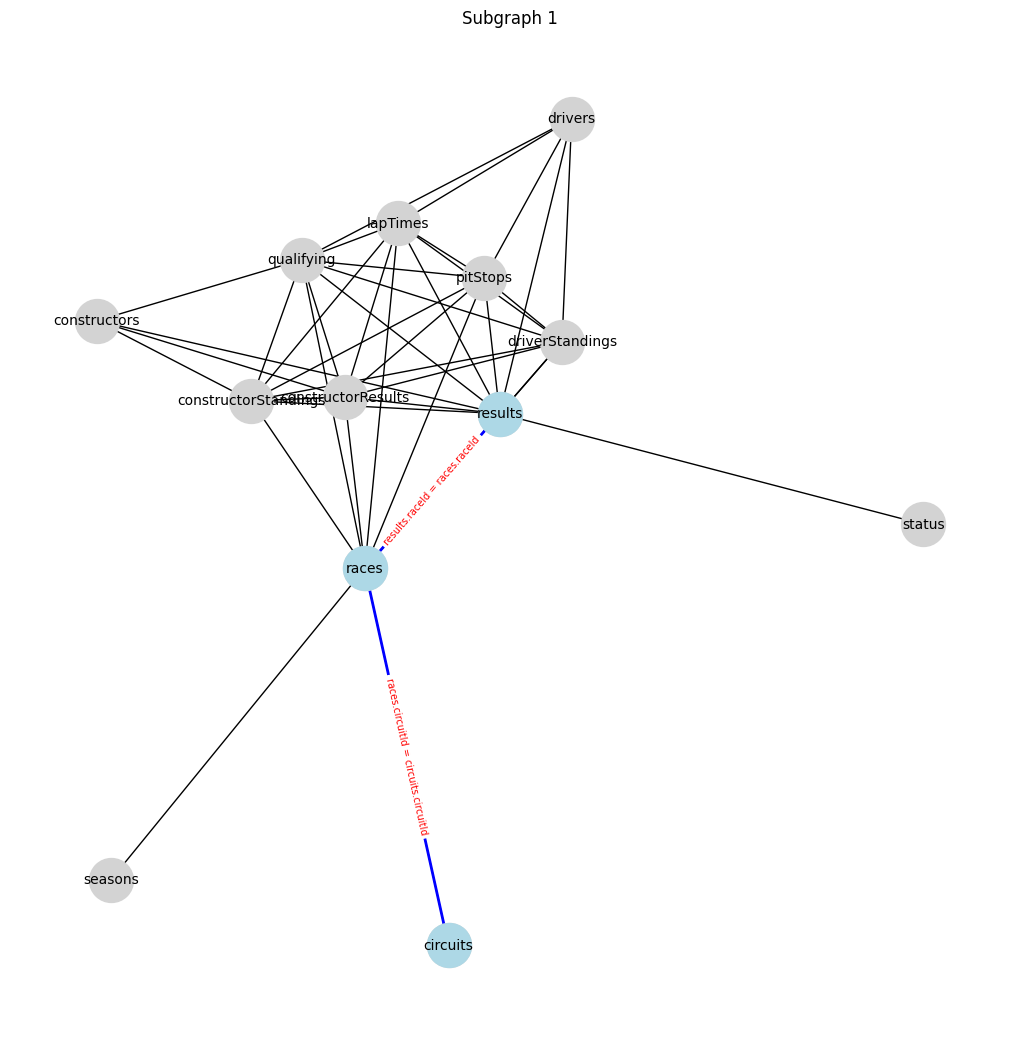

the table to be hidden:  results


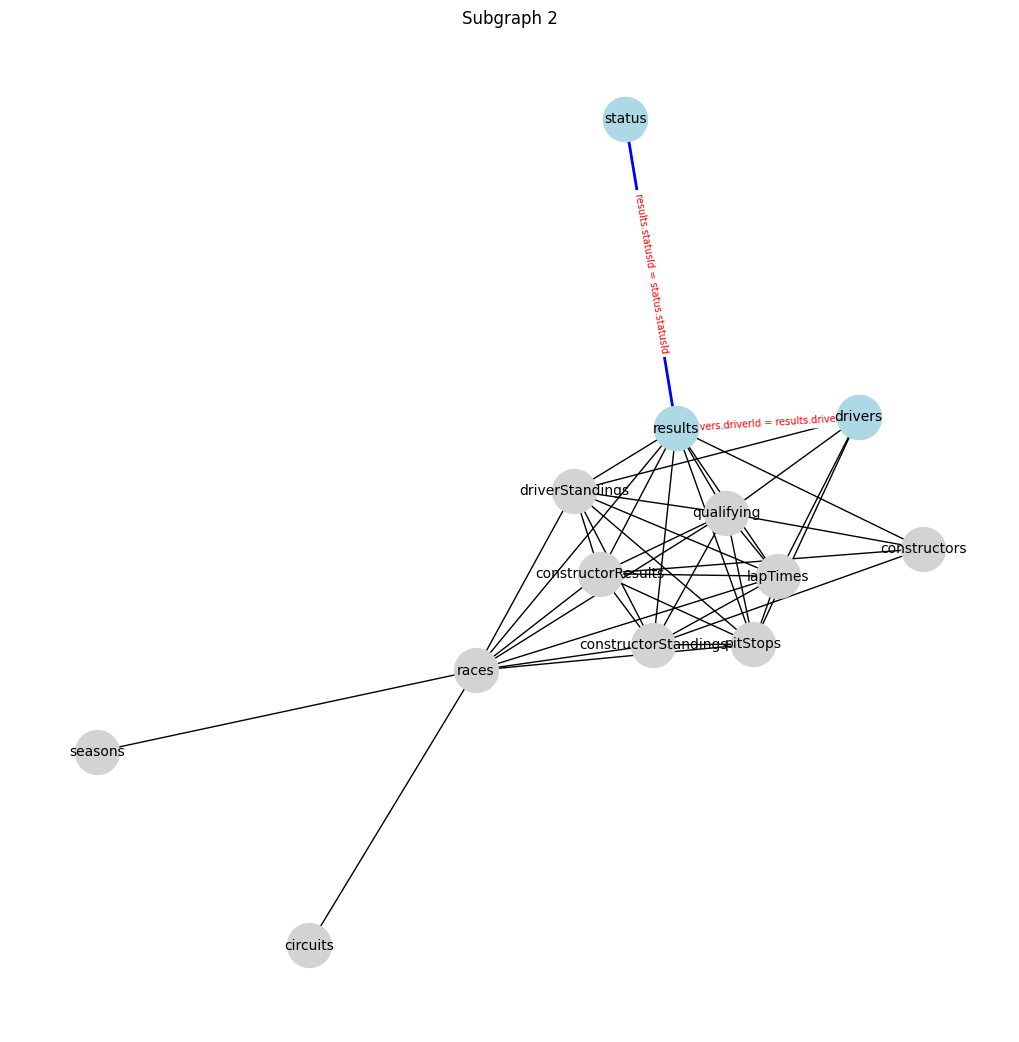

the table to be hidden:  lapTimes


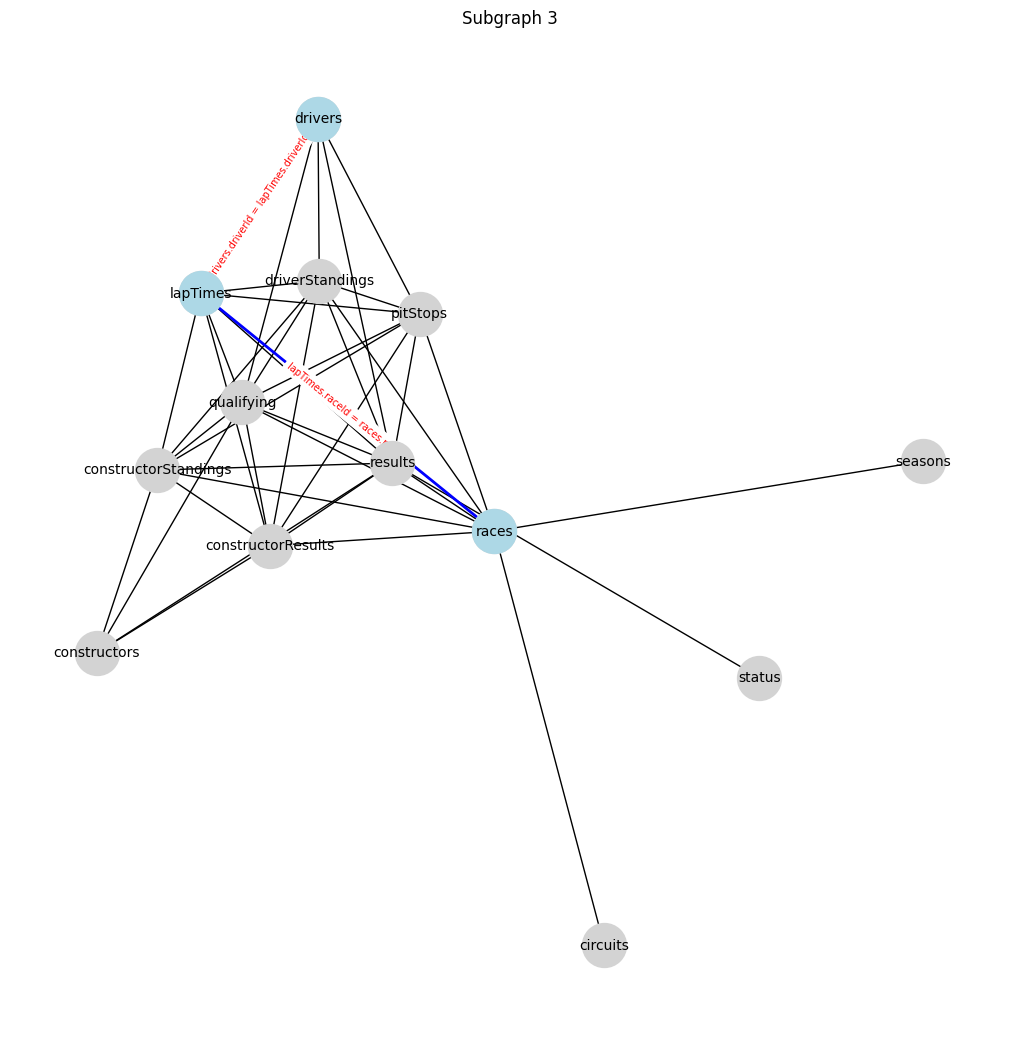

Displaying subgraphs for student_club...
the table to be hidden:  attendance


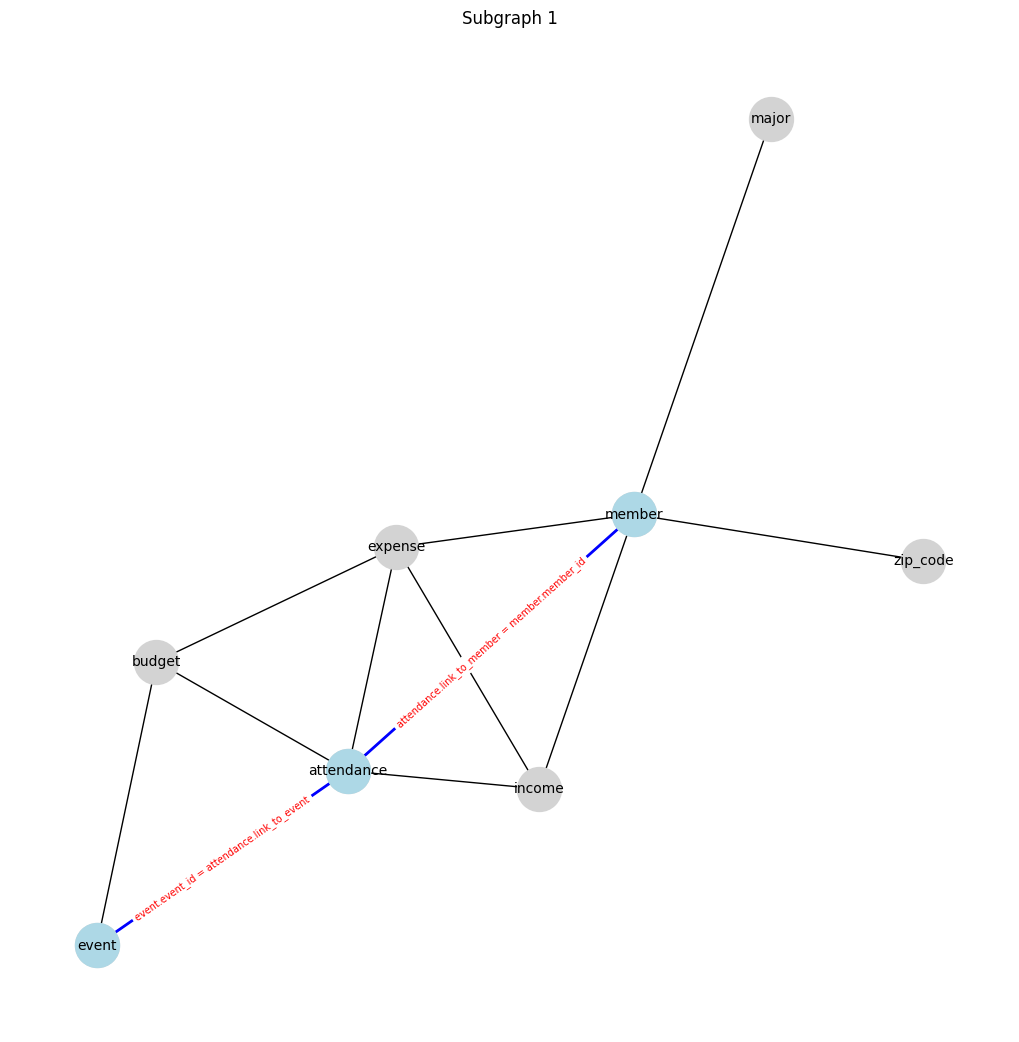

the table to be hidden:  member


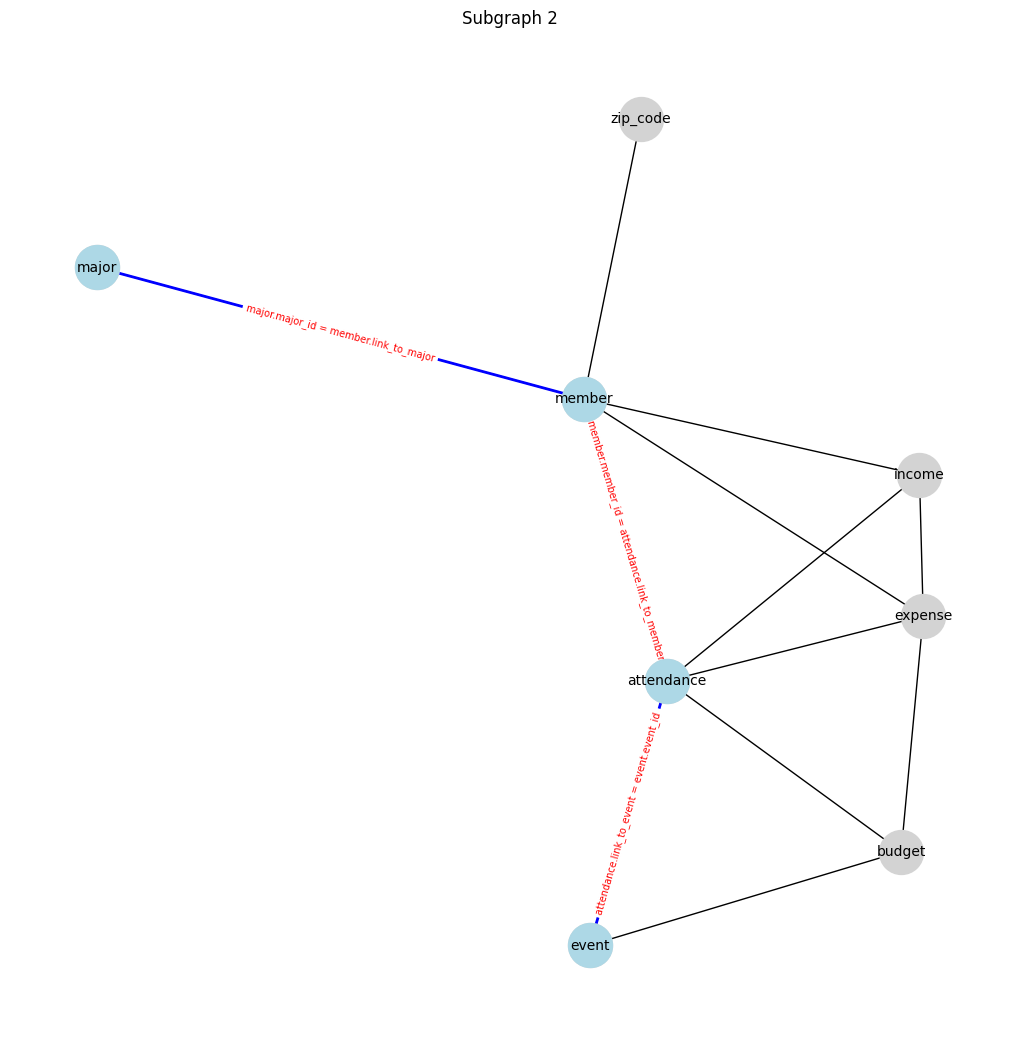

Displaying subgraphs for superhero...
the table to be hidden:  superhero


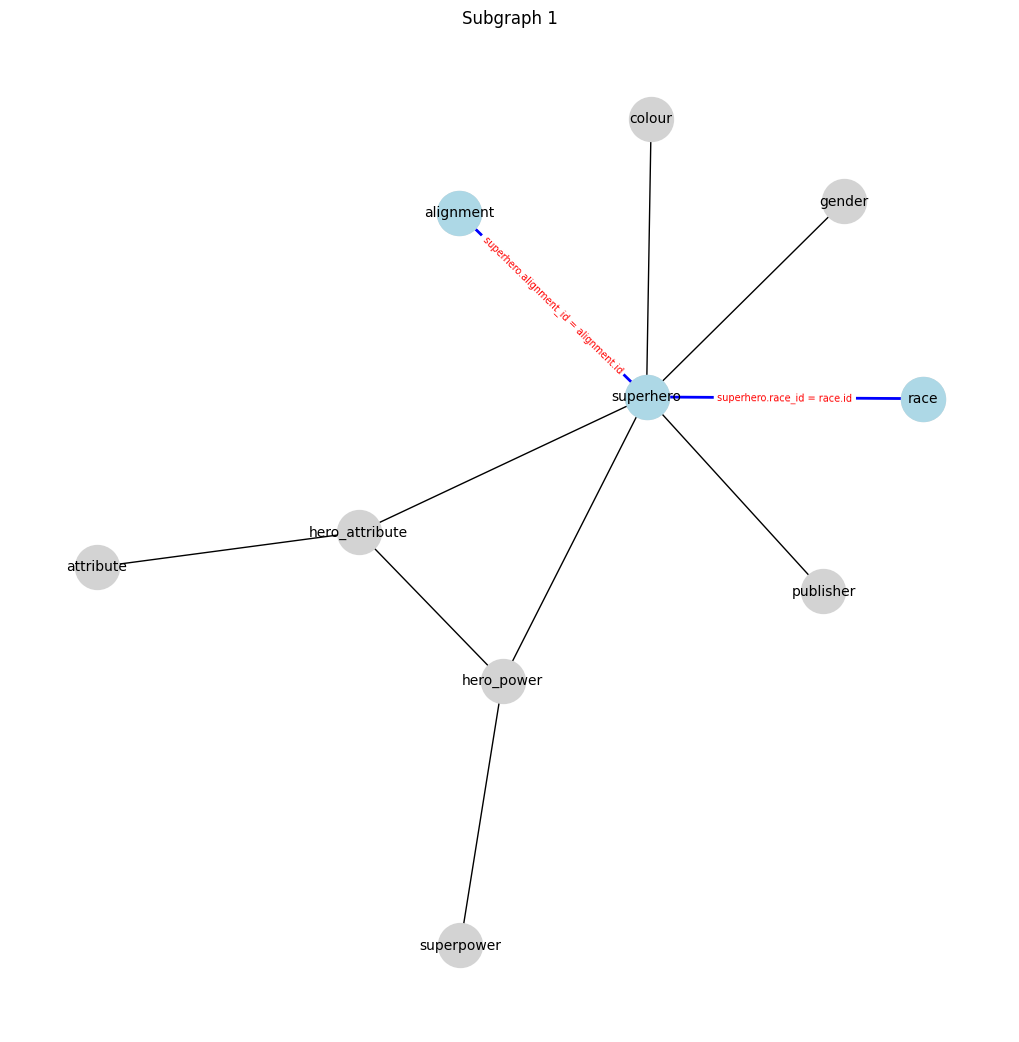

the table to be hidden:  superhero


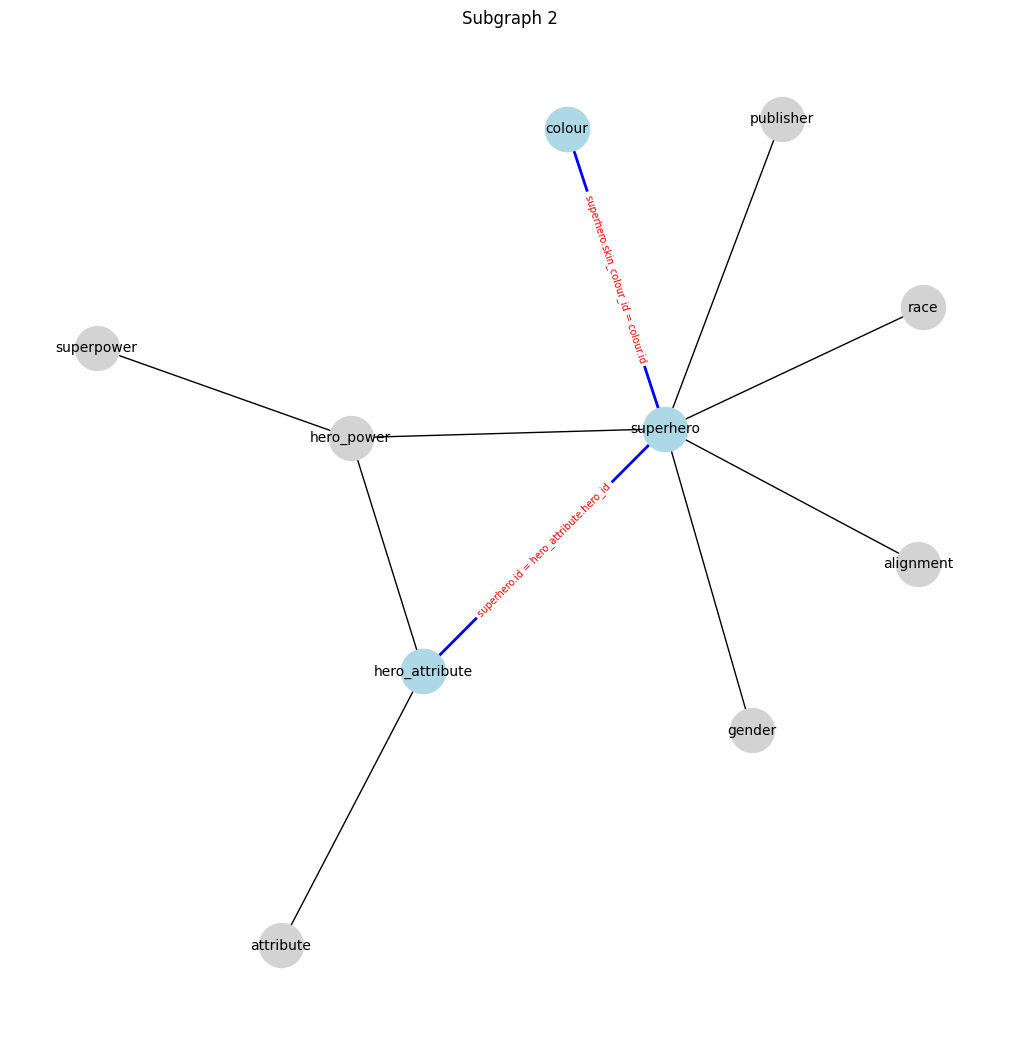

the table to be hidden:  hero_attribute


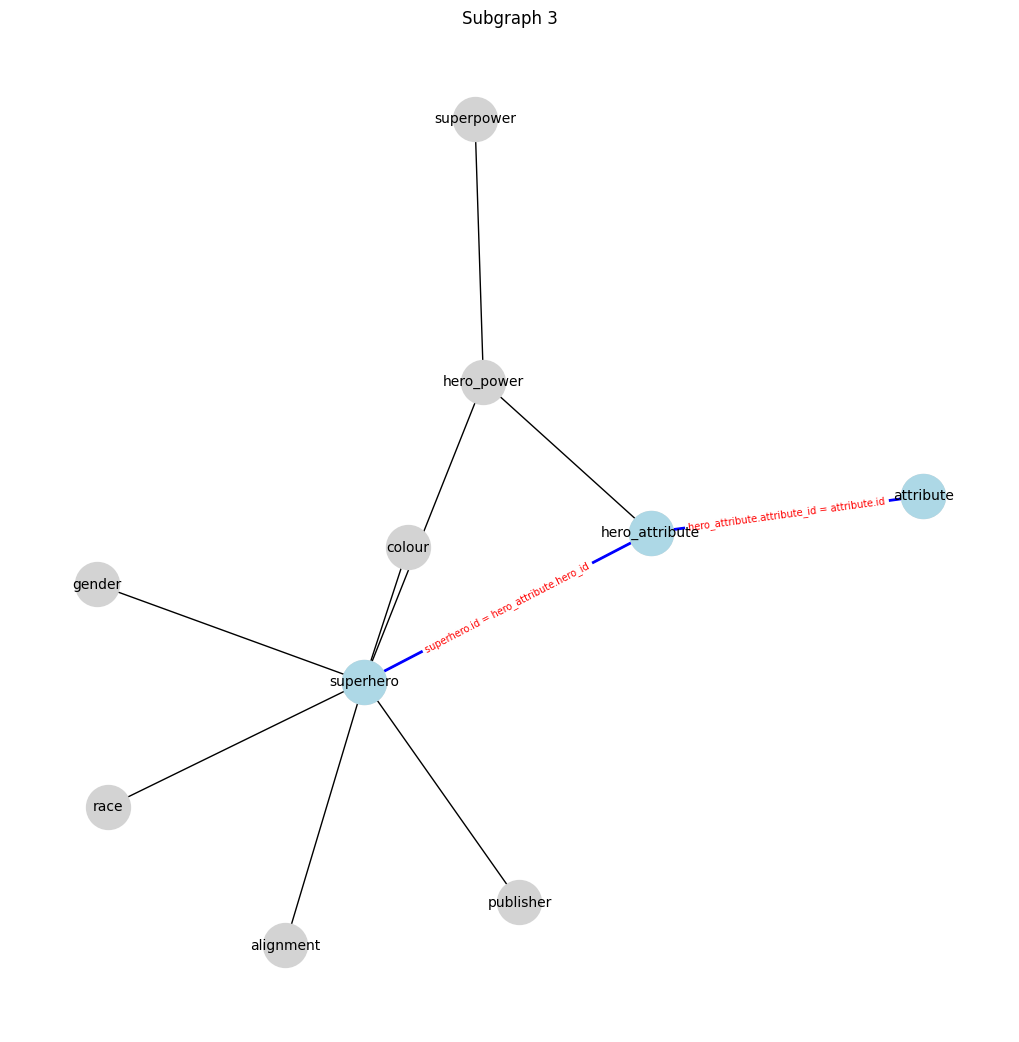

the table to be hidden:  superhero


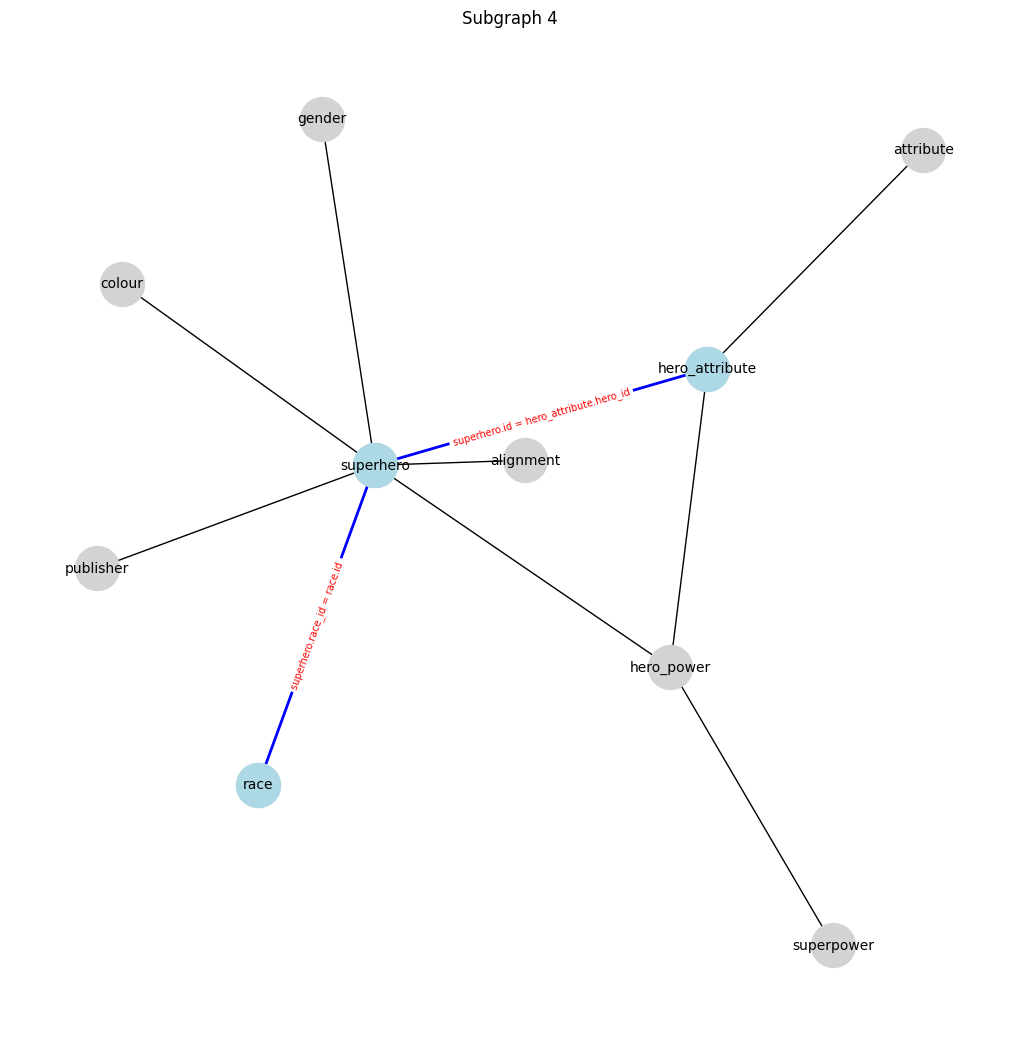

the table to be hidden:  superhero


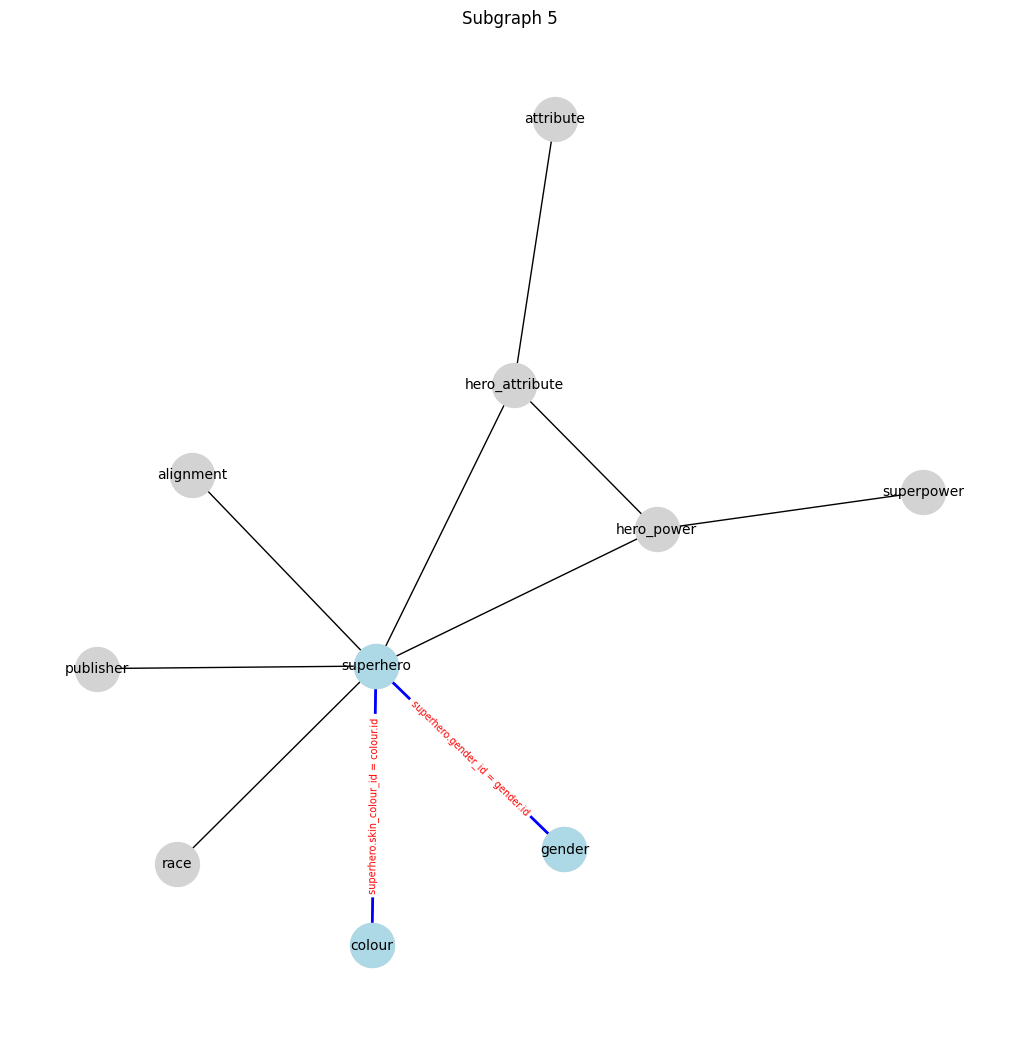

the table to be hidden:  superhero


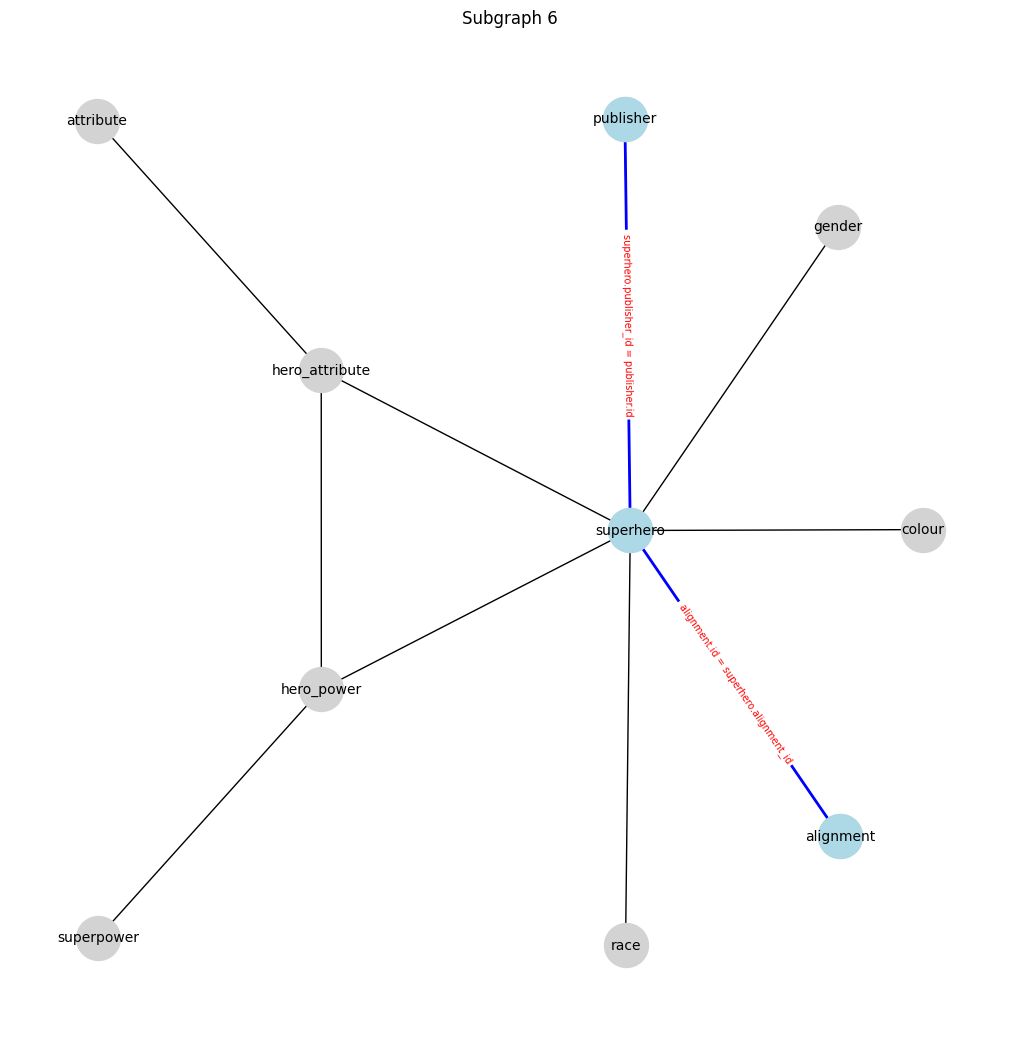

Displaying subgraphs for thrombosis_prediction...
the table to be hidden:  Examination


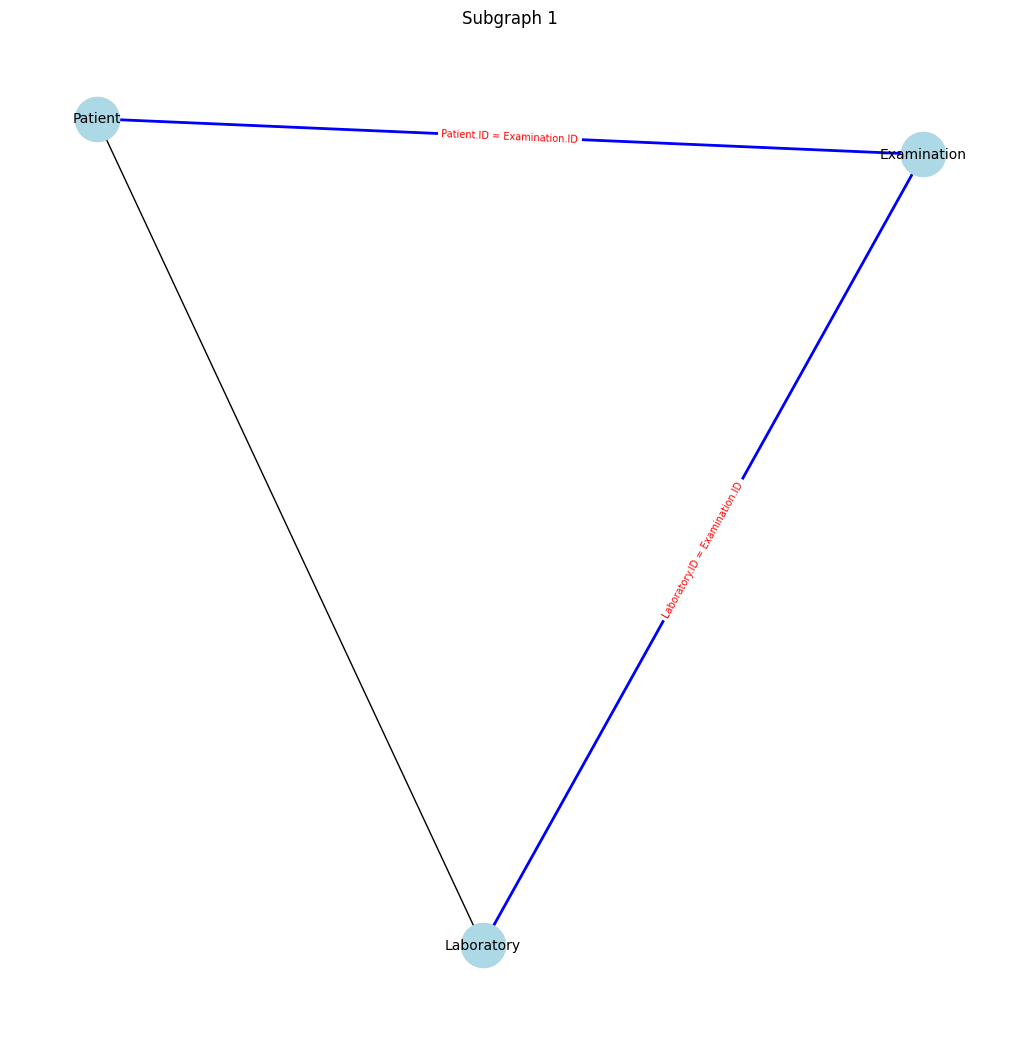

Displaying subgraphs for toxicology...
the table to be hidden:  atom


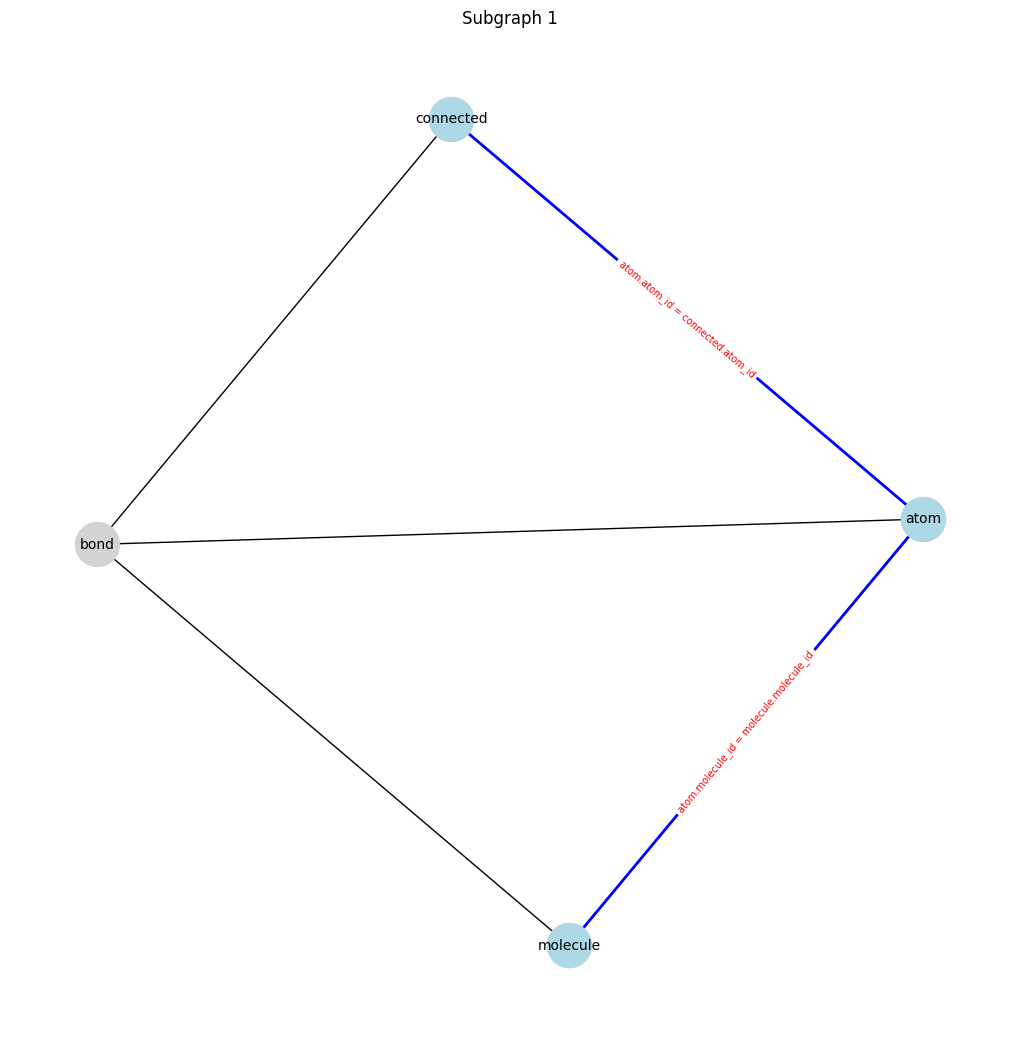

In [5]:
for db_id, subgraphs_with_candidates in all_subgraphs_with_candidates.items():
    print(f"Displaying subgraphs for {db_id}...")
    schema_path = f'../../../../data/graph_data/bird_graphs/pickles/{db_id}_graph.pkl'
    with open(schema_path, 'rb') as f:
        schema = pickle.load(f)
        for i, element in enumerate(subgraphs_with_candidates, start=1):
                # Display all subgraphs
                print("the table to be hidden: ", element.get("candidate_table"))
                display_subgraph(
                        schema=schema,
                        subgraph=element.get("subgraph"),
                        subgraph_number=i,
                )

## 3. Finding the SQL queries for each pattern
In this cell, we match each pattern with the identified candidate table using the SQL queries in the development set. The pattern details are stored in the `patterns_with_questions` folder under `dev_dbs_unnested`, which can be accessed here: [Patterns with Questions](https://drive.google.com/drive/folders/1m-i2-Y_4Ju-VNA6NmzEi74SroCDVMkRt).  

You can rename the folder to `patterns` or simply change the path as needed.

In [6]:
import os
import json
import sys
import networkx as nx
import re


def find_matching_sql_and_questions(subgraph, candidate_table, pattern_file_path):
    """
    Find matching SQL queries and questions for the given subgraph and candidate table.
    """
    subgraph_tables = list(subgraph.nodes())
    subgraph_join_labels = list(nx.get_edge_attributes(subgraph, 'label').values())

    subgraph_tables = [table.lower() for table in subgraph_tables]

    with open(pattern_file_path, 'r', encoding='utf-8') as f:
        patterns = json.load(f)

    subgraph_join_relations = set()
    for relation in subgraph_join_labels:
        subgraph_left_side, subgraph_right_side = relation.split("=")
        subgraph_left_side, subgraph_right_side = subgraph_left_side.strip(), subgraph_right_side.strip()
        subgraph_join_relations.add(subgraph_left_side.lower())
        subgraph_join_relations.add(subgraph_right_side.lower()) 

    matching_queries = []
    for pattern in patterns:
        pattern_tables = [e.get("table_name").lower() for e in pattern.get("Tables", [])]
        pattern_join_labels = pattern.get("Join_relations_without_aliases", [])

        subgraph_tables = set(subgraph_tables)
        pattern_tables = set(pattern_tables)

        pattern_join_relations = set()
        for relation in pattern_join_labels:
            pattern_left_side, pattern_right_side = relation.split(" = ")
            pattern_left_side, pattern_right_side = pattern_left_side.strip(), pattern_right_side.strip()
            pattern_join_relations.add(pattern_left_side.lower())
            pattern_join_relations.add(pattern_right_side.lower())

        
        if subgraph_tables == pattern_tables and subgraph_join_relations == pattern_join_relations:
            pattern['candidate_table'] = candidate_table
            pattern['subgraph'] = subgraph
            matching_queries.append(pattern)
            
    return matching_queries


def process_subgraphs(subgraphs_with_candidates, db_id, pattern_base_dir):

    pattern_file_path = f'{pattern_base_dir}/{db_id}_parsed_queries.json'
    
    # output_data = []  # Store all results for this db_id
    output_data = []
    for subgraph_data in subgraphs_with_candidates:
        candidate_table = subgraph_data["candidate_table"]
        subgraph = subgraph_data["subgraph"]
        # Find matching queries
        matching_queries = find_matching_sql_and_questions(subgraph, candidate_table, pattern_file_path)
        for entry in matching_queries:  
            candidate_table = entry['candidate_table']
            components = re.findall(r'[A-Z]?[a-z]+|[A-Z]+(?=[A-Z][a-z])|\d+[a-zA-Z]*', candidate_table)
            components = [comp for comp in components if comp != '_']
            components = [comp.lower() for comp in components]
            if any(comp in entry['question'].lower() for comp in components):
                entry['components'] = components
                output_data.append(entry)

    return output_data


# Base directories
database_subgraphs_with_questions = {}
pattern_base_dir = "../../../../data/query_parsing/bird_parsed_queries"
# output_base_dir = "../../../../data/rules_outputs/rule_3"
# os.makedirs(output_base_dir, exist_ok=True)  # Ensure the output directory exists
# Example usage
for db_id, subgraphs_with_candidates in all_subgraphs_with_candidates.items():
    database_subgraphs_with_questions[db_id] = process_subgraphs(subgraphs_with_candidates, db_id, pattern_base_dir)



## 4. Hiding the path information
The hiding part is done using GPT-4o mini. You can use your API key stored in a `.env` file located here.

In [7]:
import openai
import os
from dotenv import load_dotenv

load_dotenv()

openai.api_key = os.getenv("OPENAI_API_KEY")

def eda(db_id, question, evidence, sql_query, candidate_table, components):
    prompt = f"""
You are in a text-to-SQL context where each question corresponds to a SQL query based on a given database schema.

Your task is to conceal any direct reference to candidate table names in the question and the evidence while keeping them meaningful.  
Use the Synonym Replacement (SR) technique — a method from Easy Data Augmentation — to replace words or phrases linked to the table names with their synonyms.  

**Important:**  
- The synonym should not refer to the candidate table itself (e.g., if the candidate table is *cards*, do not use *playing cards* as a synonym).  
- You should hide the reference to the table name but keep the rest of the question and the evidence intact.  
- If the evidence directly mentions a table name along with a column name (e.g., cards.name), replace the table name with a suitable synonym and use pronouns or descriptive phrases that imply the source. For example: 'names of all the cards in the set refers to cards.name' becomes 'names of all the pieces in the set refers to their names.'
- Be careful with the evidence, there should be no mentioning of the candidate table name in the modified evidence.
- The evidence might be an empty string, just give back an empty string for it as well

**Details:**
- The **Candidate Table** may be a single word (e.g., *users*) or a compound name (e.g., *postHistory* or *transactions_1k*).  
- You will be provided with the **Components** — a list containing either:
  - A single item (for simple table names), or
  - Multiple items (for compound names split into parts).
- If the question contains any of these components, hide the relevant part using SR.
- The synonym used should not reference the candidate table.

**Input:**
- **Database ID:** {db_id}
- **Question:** {question}
- **Evidence:** {evidence}
- **SQL Query:** {sql_query}
- **Candidate Table:** {candidate_table}
- **Components:** {components}

**Output:**  
Return only the modified question and evidence after applying the SR technique. Do not include anything else. Your output should be in this format:
New Question: modified question
New Evidence: modified evidence if evidence is provided, otherwise an empty string
"""

    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": prompt}
    ]

    # Get response from the LLM
    response = openai.chat.completions.create(
        model="gpt-4o",
        messages=messages,
        max_tokens=300,
        temperature=0.7,
        top_p=1,
        frequency_penalty=0,
        presence_penalty=0,
    )

    # Process LLM response
    generated_text = response.choices[0].message.content.strip()
    return generated_text


subgraphs_with_eda_questions = {}
for db_id, subgraphs_with_questions in database_subgraphs_with_questions.items():
    print("Generating new questions for", db_id)
    eda_questions = []
    for entry in subgraphs_with_questions:
        new_rows = eda(db_id, entry['question'], entry['evidence'], entry['SQL'], entry['candidate_table'], entry['components'])
        for row in new_rows.split("\n"):
            if row.startswith("New Question:"):
                new_question = row.replace("New Question: ", "").strip()
            if row.startswith("New Evidence:"):
                new_evidence = row.replace("New Evidence: ", "").strip()
        if not any(comp in new_question.lower() for comp in entry['components']):
            entry['new_question'] = new_question
            entry['new_evidence'] = new_evidence
            eda_questions.append(entry)
    subgraphs_with_eda_questions[db_id] = eda_questions

#I want the length of all the lists in subgraph_with_eda_questions
for db_id, s_with_questions in database_subgraphs_with_questions.items():
    print(f"Number of questions for {db_id}:", len(s_with_questions))
for db_id, s_with_eda_questions in subgraphs_with_eda_questions.items():
    print(f"Number of new questions for {db_id}:", len(s_with_eda_questions))


Generating new questions for california_schools
Generating new questions for card_games
Generating new questions for codebase_community
Generating new questions for debit_card_specializing
Generating new questions for european_football_2
Generating new questions for financial
Generating new questions for formula_1
Generating new questions for student_club
Generating new questions for superhero
Generating new questions for thrombosis_prediction
Generating new questions for toxicology
Number of questions for california_schools: 0
Number of questions for card_games: 0
Number of questions for codebase_community: 2
Number of questions for debit_card_specializing: 2
Number of questions for european_football_2: 1
Number of questions for financial: 3
Number of questions for formula_1: 3
Number of questions for student_club: 0
Number of questions for superhero: 12
Number of questions for thrombosis_prediction: 3
Number of questions for toxicology: 1
Number of new questions for california_school

In [8]:
import openai
import os
from dotenv import load_dotenv

load_dotenv()

openai.api_key = os.getenv("OPENAI_API_KEY")

def uda(db_id, question, evidence, sql_query, candidate_table, components):
    prompt = f"""
You are in a text-to-SQL context where each question corresponds to a SQL query based on a given database schema.

Your task is to conceal any direct reference to the candidate table names in the question and the evidence while keeping it meaningful.  
Use the **Back Translation (BT)** technique — a method from Unsupervised Data Augmentation. First, translate the question and the evidence into French, then back to English. During the French translation, replace any reference to the candidate table with a relevant synonym.  

**Important:**  
- Do not use synonyms that refer directly to the candidate table (e.g., if the candidate table is *cards*, do not use *cartes de jeu*).  
- Hide only the table name reference and keep the rest of the question and evidence intact.  
- If the evidence directly mentions a table name along with a column name (e.g., cards.name), replace the table name with a suitable synonym and use pronouns or descriptive phrases that imply the source. For example: 'names of all the cards in the set refers to cards.name' becomes 'names of all the pieces in the set refers to their names.'
- Be careful with the evidence, there should be no mentioning of the candidate table name in the modified evidence.
- The evidence might be an empty string, just give back an empty string for it as well

**Details:**
- The **Candidate Table** may be a single word (e.g., *users*) or a compound name (e.g., *postHistory* or *transactions_1k*).  
- You will be provided with the **Components** — a list containing either:
  - A single item (for simple table names), or
  - Multiple items (for compound names split into parts).
- During the French translation, replace the relevant part with the synonym, then translate it back to English.
- The synonym used should not refer directly to the candidate table.


**Input:**
- **Database ID:** {db_id}
- **Question:** {question}
- **Evidence:** {evidence}
- **SQL Query:** {sql_query}
- **Candidate Table:** {candidate_table}
- **Components:** {components}

**Output:**  
Return the question and evidence in French and then in English. Do not include anything else. The output should be in this format:
Question in French: The question in French 
Question in English: The question in English
Evidence in French: The evidence in French if evidence is provided, otherwise an empty string
Evidence in English: The evidence in English if evidence is provided, otherwise an empty string
"""

    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": prompt}
    ]

    # Get response from the LLM
    response = openai.chat.completions.create(
        model="gpt-4o",
        messages=messages,
        max_tokens=300,
        temperature=0.7,
        top_p=1,
        frequency_penalty=0,
        presence_penalty=0,
    )

    # Process LLM response
    generated_text = response.choices[0].message.content.strip()
    return generated_text


subgraphs_with_uda_questions = {}
for db_id, subgraphs_with_questions in database_subgraphs_with_questions.items():
    print("Generating new questions for", db_id)
    uda_questions = []
    for entry in subgraphs_with_questions:
        new_question = uda(db_id, entry['question'], entry['evidence'], entry['SQL'], entry['candidate_table'], entry['components'])
        for row in new_question.split("\n"):
            if row.startswith("Question in English:"):
                new_question = row.replace("Question in English: ", "").strip()
            if row.startswith("Evidence in English:"):
                new_evidence = row.replace("Evidence in English: ", "").strip()
        if not any(comp in new_question.lower() for comp in entry['components']):
            entry['new_question'] = new_question
            entry['new_evidence'] = new_evidence
            uda_questions.append(entry)
    
    subgraphs_with_uda_questions[db_id] = uda_questions

#I want the length of all the lists in subgraph_with_uda_questions
for db_id, s_with_questions in database_subgraphs_with_questions.items():
    print(f"Number of questions for {db_id}:", len(s_with_questions))
for db_id, s_with_uda_questions in subgraphs_with_uda_questions.items():
    print(f"Number of new questions for {db_id}:", len(s_with_uda_questions))

Generating new questions for california_schools
Generating new questions for card_games
Generating new questions for codebase_community
Generating new questions for debit_card_specializing
Generating new questions for european_football_2
Generating new questions for financial
Generating new questions for formula_1
Generating new questions for student_club
Generating new questions for superhero
Generating new questions for thrombosis_prediction
Generating new questions for toxicology
Number of questions for california_schools: 0
Number of questions for card_games: 0
Number of questions for codebase_community: 2
Number of questions for debit_card_specializing: 2
Number of questions for european_football_2: 1
Number of questions for financial: 3
Number of questions for formula_1: 3
Number of questions for student_club: 0
Number of questions for superhero: 12
Number of questions for thrombosis_prediction: 3
Number of questions for toxicology: 1
Number of new questions for california_school

In [9]:
import openai
import os
from dotenv import load_dotenv

load_dotenv()

openai.api_key = os.getenv("OPENAI_API_KEY")

def contextual_augmentation(db_id, question, evidence, sql_query, candidate_table, components):
    prompt = f"""
You are in a text-to-SQL context where each question corresponds to a SQL query based on a given database schema.

Your task is to conceal any direct reference to candidate table names in the question and the evidence while keeping it meaningful.  
Use the Contextual Augmentation technique to replace words or phrases linked to the table names with their contextually appropriate synonyms to make sure that the paraphrasing aligns with the surrounding context.  

**Important:**  
- The synonym should be relevant to the context of the question, which can be derived from the db_id. E.g. if the db_id is *card_games*, one of the synonyms for *cards* could be *playing pieces* and not *vouchers*.
- The synonym should not refer to the candidate table itself (e.g., if the candidate table is *cards*, do not use *playing cards* as a synonym).  
- You should hide the reference to the table name but keep the rest of the question intact.  
- If the evidence directly mentions a table name along with a column name (e.g., cards.name), replace the table name with a suitable synonym and use pronouns or descriptive phrases that imply the source. For example: 'names of all the cards in the set refers to cards.name' becomes 'names of all the pieces in the set refers to their names.'
- Be careful with the evidence, there should be no mentioning of the candidate table name in the modified evidence.
- The evidence might be an empty string, just give back an empty string for it as well

**Details:**
- The **Candidate Table** may be a single word (e.g., *users*) or a compound name (e.g., *postHistory* or *transactions_1k*).  
- You will be provided with the **Components** — a list containing either:
  - A single item (for simple table names), or
  - Multiple items (for compound names split into parts).
- If the question contains any of these components, hide the relevant part using SR.
- The synonym used should not reference the candidate table.

**Input:**
- **Database ID:** {db_id}
- **Question:** {question}
- **Evidence:** {evidence}
- **SQL Query:** {sql_query}
- **Candidate Table:** {candidate_table}
- **Components:** {components}

**Output:**  
Return only the modified question after applying the contextual augmentation technique. Do not include anything else. The output should be in this format:
New Question: modified question
New Evidence: modified evidence if evidence is provided, otherwise an empty string 
"""

    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": prompt}
    ]

    # Get response from the LLM
    response = openai.chat.completions.create(
        model="gpt-4o",
        messages=messages,
        max_tokens=300,
        temperature=0.7,
        top_p=1,
        frequency_penalty=0,
        presence_penalty=0,
    )

    # Process LLM response
    generated_text = response.choices[0].message.content.strip()
    return generated_text


subgraphs_with_ca_questions = {}
for db_id, subgraphs_with_questions in database_subgraphs_with_questions.items():
    print("Generating new questions for", db_id)
    ca_questions = []
    for entry in subgraphs_with_questions:
        rows = contextual_augmentation(db_id, entry['question'], entry['evidence'], entry['SQL'], entry['candidate_table'], entry['components'])
        for row in rows.split("\n"):
            if row.startswith("New Question:"):
                new_question = row.replace("New Question: ", "").strip()
            if row.startswith("New Evidence:"):
                new_evidence = row.replace("New Evidence: ", "").strip()
        if not any(comp in new_question.lower() for comp in entry['components']):
            entry['new_question'] = new_question
            entry['new_evidence'] = new_evidence
            print("original_question: ", entry['question'], " | new_question: ", new_question)
            print("original_evidence: ", entry['evidence'], " | new_evidence: ", new_evidence)
            ca_questions.append(entry)
    subgraphs_with_ca_questions[db_id] = ca_questions

#I want the length of all the lists in subgraph_with_eda_questions
for db_id, s_with_questions in database_subgraphs_with_questions.items():
    print(f"Number of questions for {db_id}:", len(s_with_questions))
for db_id, s_with_ca_questions in subgraphs_with_ca_questions.items():
    print(f"Number of new questions for {db_id}:", len(s_with_ca_questions))


Generating new questions for california_schools
Generating new questions for card_games
Generating new questions for codebase_community
original_question:  How many negative comments did Neil McGuigan get in his posts?  | new_question:  How many negative remarks did Neil McGuigan get in his submissions?
original_evidence:  Negative comment refers to score < 60; DisplayName = 'Neil McGuigan';  | new_evidence:  Negative remark refers to score < 60; DisplayName = 'Neil McGuigan';
original_question:  Identify the number of posts and comments left by the user, who has the latest created user account.  | new_question:  Identify the number of contributions and remarks left by the user, who has the latest created user account.
original_evidence:  the latest created user account refers to MAX(CreationDate);  | new_evidence:  the latest created user account refers to MAX(CreationDate);
Generating new questions for debit_card_specializing
original_question:  Please list the chains of the gas stat

## 5. Final queries 
This cell should be run after generating the new questions for each `db_id`. It gathers all the previously generated data in one place. To run this, you will need the `bird_dev.json` file, which is the development set file. It can be found here: [bird_dev.json](https://drive.google.com/drive/folders/10WxERhJh5ZWbad9fwNyR_51hWkSxFKr4).


In [10]:
import os

def save_questions_to_file(subgraphs, output_base_dir, technique):
    output_dir = f'{output_base_dir}/{technique}'
    os.makedirs(output_dir, exist_ok=True)  # Ensure the output directory exists
    original_questions = []
    new_questions = []
    for db_id, subgraphs_per_db in subgraphs.items():
        for i, entry in enumerate(subgraphs_per_db):
            original_entry = {
                "question_id": i,
                "db_id": db_id,
                "question": entry['question'],
                "evidence": entry['evidence'],
                "SQL": entry['SQL'],
                "difficulty": entry['difficulty']
            }
            new_entry = {
                "question_id": i,
                "db_id": db_id,
                "question": entry['new_question'],
                "evidence": entry['new_evidence'],
                "SQL": entry['SQL'],
                "difficulty": entry['difficulty']
            }
            original_questions.append(original_entry)
            new_questions.append(new_entry)

    with open(f'{output_dir}/original_questions.json', 'w') as f:
        json.dump(original_questions, f, indent=4)
    with open(f'{output_dir}/new_questions.json', 'w') as f:
        json.dump(new_questions, f, indent=4)
    
    print(f"Saved {len(original_questions)} original questions and {len(new_questions)} new questions for {db_id} to {output_dir}.")
    

# Save the questions to files
output_base_dir = "../../../../data/rule_outputs/rule_3/test"
os.makedirs(output_base_dir, exist_ok=True)  # Ensure the output directory exists

save_questions_to_file(subgraphs_with_eda_questions, output_base_dir, "eda")
save_questions_to_file(subgraphs_with_uda_questions, output_base_dir, "uda")
save_questions_to_file(subgraphs_with_ca_questions, output_base_dir, "ca")

Saved 26 original questions and 26 new questions for toxicology to ../../../../data/rule_outputs/rule_3/test/eda.
Saved 12 original questions and 12 new questions for toxicology to ../../../../data/rule_outputs/rule_3/test/uda.
Saved 25 original questions and 25 new questions for toxicology to ../../../../data/rule_outputs/rule_3/test/ca.
